In [ ]:
import sys, os
# 2026 reorg: project modules now live in scripts/ (and src/). Put them on the path.
for _p in ('scripts', 'src'):
    _ap = os.path.abspath(_p)
    if _ap not in sys.path:
        sys.path.insert(0, _ap)


# Heat Pump Installed Capacity Detection

Import Libraries

In [400]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import sys
import warnings
import time
import json

import shap
import h5py

import xgboost as xgb

from matplotlib.patches import Polygon
from matplotlib import colors

from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from hyperopt.early_stop import no_progress_loss

from typing import Tuple
from itertools import product
from math import ceil, floor
from scipy.stats import skew, kurtosis
from scipy.interpolate import griddata
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

from datetime import datetime, timedelta
from random import choice, sample, randrange, randint, uniform
from itertools import compress
from copy import deepcopy

from sklearn.metrics import (root_mean_squared_error, mean_absolute_percentage_error,
                             mean_absolute_error, r2_score, mean_squared_error)
from sklearn.model_selection import (cross_val_score, GridSearchCV, train_test_split,
                                     KFold, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, RidgeCV, Ridge
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.cross_decomposition import PLSRegression

from tqdm import tqdm, trange
import hplib as hpl


In [401]:
# ── Data generation ───────────────────────────────────────────────────────
regenerate_substations    = False   # build synthetic substations from HEAPO
regenerate_time_features  = False   # extract 96-slot time-of-day features

# ── Substation hockey-stick fits (no model file, always fast) ─────────────
refit_hockey_daily        = False   # daily min-T / max-Load fit per substation
refit_hockey_hourly       = False   # 4-window hourly fit per substation

# ── XGBoost models ────────────────────────────────────────────────────────
retrain_xgb_time          = False   # XGBoost on time-of-day features
retrain_xgb_time_hockey   = False   # XGBoost on time-of-day + hockey-stick coefficients
retrain_xgb_windowed_hdd  = False   # XGBoost on windowed HDD-binned features

# ── Ridge / PLS models ────────────────────────────────────────────────────
retrain_ridge_time        = False   # Ridge on time-of-day features
retrain_ridge_time_hockey = False   # Ridge on time-of-day + hockey-stick coefficients
retrain_ridge_windowed_hdd= False   # Ridge with feature-selection on windowed HDD features
retrain_pls_time_series   = False   # PLS on raw load time series
retrain_pls_features      = False   # PLS on time-of-day feature matrix


In [402]:
# heapo is importable from src/ (added to sys.path in the first cell)
from heapo import *

# ---------------------------------------
# DEFINE PATH TO WHERE THE DATA IS STORED
# ---------------------------------------

# NOTE: if data is stored under /data/ within this repository --> set data_path = None 
data_path = 'data/heapo_data'

# ---------------------------------------
# CREATE HEAPO OBJECT
# ---------------------------------------

# create HEAPO object
heapo = HEAPO(data_path=data_path, use_local_time=False, suppress_warning=False)

Check households with submetered Heat Pumps

In [403]:
df_protocols = heapo.get_all_protocols()
households = heapo.get_all_households()

submeter_datarange = {}

start_date = '2023-01-01 00:00:00+00:00'
end_date = '2023-12-31 23:45:00+00:00'

full_year_no_weekends = pd.date_range(start=start_date, end=end_date, freq='15min')
# full_year_no_weekends = full_year_no_weekends[full_year_no_weekends.weekday < 5]  # only consider weekdays

for household_id in households:
    try:
        df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
        df_house = df_house[(df_house['Timestamp'] >= pd.to_datetime(start_date)) & (df_house['Timestamp'] <= pd.to_datetime(end_date))]
        df_house.dropna(subset=['kWh_received_HeatPump', 'kWh_received_Total', 'kWh_received_Other'],inplace=True)
        # df_house = df_house[df_house['Timestamp'].dt.weekday < 5]        # only consider weekdays
        if len(df_house) > full_year_no_weekends.shape[0] * 0.8:  # only consider households with at least 80% of the data available
            submeter_datarange[household_id] = (df_house['Timestamp'].min(), df_house['Timestamp'].max(), len(df_house) * timedelta(minutes=15), full_year_no_weekends.shape[0] * timedelta(minutes=15) - len(df_house) * timedelta(minutes=15))
    except:
        pass


Get corresponding weather stations' IDs

In [ ]:
df_meta = heapo.get_meta_data_overview()

datarangeDf = pd.DataFrame.from_dict(submeter_datarange, orient='index', columns=['Start', 'End', 'Length', 'Missing Data']).sort_values('Length', ascending=False)
datarangeDf = datarangeDf.join(df_meta.set_index('Household_ID')['Weather_ID'])

In [ ]:
hp_peaks = []
for household_id in datarangeDf.index:
    df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
    df_house = df_house[(df_house['Timestamp'] >= pd.to_datetime(start_date)) & (df_house['Timestamp'] <= pd.to_datetime(end_date))]
    # df_house = df_house[df_house['Timestamp'].dt.weekday < 5]        # only consider weekdays
    hp_load = df_house['kWh_received_HeatPump'].values * 4
    hp_load = hp_load[~np.isnan(hp_load)]
    hp_peak = hp_load.max()
    hp_99_9 = np.quantile(hp_load, 0.999)
    hp_time = df_house.iloc[np.argmax(hp_load)]['Timestamp']
    hp_peaks.append((hp_peak, hp_99_9, hp_time))

In [ ]:
hp_peaks_df = pd.DataFrame({'Household_ID': datarangeDf.index, 'HP_Peak': [hp[0] for hp in hp_peaks], 'HP_99_9': [hp[1] for hp in hp_peaks], 'Timestamp': [hp[2] for hp in hp_peaks]})
hp_peaks_df.sort_values('HP_Peak', ascending=False, inplace=True)
hp_peaks_df

,Household_ID,HP_Peak,HP_99_9,Timestamp
44,1186910,28.388,20.030828,2023-02-28 00:30:00+00:00
32,611797,19.360,10.080684,2023-01-24 17:45:00+00:00
35,6687105,13.984,13.752000,2023-11-27 00:15:00+00:00
11,1181060,13.700,13.520000,2023-12-14 01:15:00+00:00
30,120706,12.820,9.787752,2023-04-13 06:15:00+00:00
22,818882,12.152,11.052228,2023-11-24 16:15:00+00:00
3,816910,11.704,9.220912,2023-02-10 08:00:00+00:00
6,884673,10.720,8.572456,2023-10-18 12:45:00+00:00
25,109105,10.672,10.392000,2023-01-21 03:15:00+00:00
47,667399,10.092,9.116000,2023-11-29 00:30:00+00:00


Check weather data availability

In [ ]:
weather_ids = datarangeDf['Weather_ID'].unique()

weather_datarange = {}

full_year = pd.date_range(start=start_date, end=end_date, freq='h')
# full_year_no_weekends = full_year[full_year.weekday < 5]  # only consider weekdays

for weather_id in weather_ids:
    try:
        df_weather = heapo.load_weather_data(weather_id, resolution='hourly')
        df_weather = df_weather[(df_weather['Timestamp'] >= pd.to_datetime(start_date)) & (df_weather['Timestamp'] <= pd.to_datetime(end_date))]
        # df_weather = df_weather[df_weather['Timestamp'].dt.weekday < 5]        # only consider weekdays
        df_weather.dropna(subset=['Temperature_avg_hourly'],inplace=True)
        if len(df_weather) > full_year.shape[0] * 0.8: # at least 80% of data for one year
            weather_datarange[weather_id] = (df_weather['Timestamp'].min(), df_weather['Timestamp'].max(), len(df_weather) * timedelta(minutes=60), full_year.shape[0] * timedelta(minutes=60) - len(df_weather) * timedelta(minutes=60))
    except:
        pass

In [ ]:
weather_datarangeDf = pd.DataFrame.from_dict(weather_datarange, orient='index', columns=['Start', 'End', 'Length', 'Missing Data']).sort_values('Length', ascending=False)

datarangeDf = datarangeDf[datarangeDf['Weather_ID'].isin(weather_datarangeDf.index)]

### Fit household HP and smart-meter load vs temperature (hockey-stick model)

In [ ]:
# ---------------------------------------------------------------------------
# Hockey-stick model: Load(T) = base_load + hp_sensitivity * max(0, T_balance - T)
#
# The model code now lives in `hp_common.py` so that this notebook and
# `HeatPump_Hypotheses.ipynb` share a single definition instead of keeping
# divergent copies. Only 3 parameters, all physically bounded, so the
# degenerate solutions an unconstrained piecewise fit can land on (positive
# cold-weather slopes, breakpoints outside the heating range) cannot happen.
# ---------------------------------------------------------------------------
from hp_common import (
    hockey_stick,
    fit_hockey_stick,
    daily_min_max_heating_season,
    daily_mean_mean_heating_season,
)


In [ ]:
# Shared constants (see hp_common.py)
from hp_common import T_BALANCE_BOUNDS, HEATING_SEASON_THRESH, MIN_HEATING_DAYS

def fit_household_hockey_stick(
    household_id,
    load_col,
    heapo_obj,
    datarange_df,
    start_date,
    end_date,
    t_balance_bounds=T_BALANCE_BOUNDS,
    heating_season_thresh=HEATING_SEASON_THRESH,
    min_heating_days=MIN_HEATING_DAYS,
):
    """Load one household's data and fit the hockey-stick model.

    Returns (household_id, base_load, hp_sensitivity, T_balance, r2)
    or None if the fit cannot be computed.
    """
    try:
        sm_data = heapo_obj.load_smart_meter_data(household_id, resolution='15min')
        weather_data = heapo_obj.load_weather_data(
            datarange_df.loc[household_id, 'Weather_ID'], resolution='hourly')

        sm_data = sm_data.dropna(subset=[load_col])
        sm_data = sm_data[(sm_data['Timestamp'] >= pd.to_datetime(start_date)) &
                          (sm_data['Timestamp'] <= pd.to_datetime(end_date))]
        sm_data = (sm_data[['Timestamp', load_col]]
                   .set_index('Timestamp')
                   .resample('15min').sum())

        weather_data = weather_data.dropna(subset=['Temperature_avg_hourly'])
        weather_data = weather_data[
            (weather_data['Timestamp'] >= pd.Timestamp(start_date, tz='UTC')) &
            (weather_data['Timestamp'] <= pd.Timestamp(end_date, tz='UTC'))]
        weather_data = (weather_data[['Timestamp', 'Temperature_avg_hourly']]
                        .set_index('Timestamp')
                        .resample('15min').mean()
                        .interpolate(method='time'))

        load_series = sm_data[load_col] * 4          # kWh/15min → kW
        temp_series  = weather_data['Temperature_avg_hourly']

        # x, y = daily_min_max_heating_season(temp_series, load_series, heating_season_thresh)
        x, y = daily_mean_mean_heating_season(temp_series, load_series, heating_season_thresh)
        if len(x) < min_heating_days:
            return None

        base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, t_balance_bounds)
        return (household_id, base_load, hp_sensitivity, T_balance, r2)
    except Exception:
        return None


# ── Fit submetered HP load ────────────────────────────────────────────────
hp_fit_results = [
    fit_household_hockey_stick(hid, 'kWh_received_HeatPump',
                               heapo, datarangeDf, start_date, end_date)
    for hid in tqdm(datarangeDf.index, desc='Hockey-stick fit: HP load')
]
hp_fit_results = [r for r in hp_fit_results if r is not None]

hockey_coeffs_hp_df = pd.DataFrame(
    hp_fit_results,
    columns=['Household_ID', 'Base_Load', 'HP_Sensitivity', 'T_Balance', 'R2_Score']
).set_index('Household_ID')


Hockey-stick fit: HP load: 100%|██████████| 57/57 [00:31<00:00,  1.84it/s]


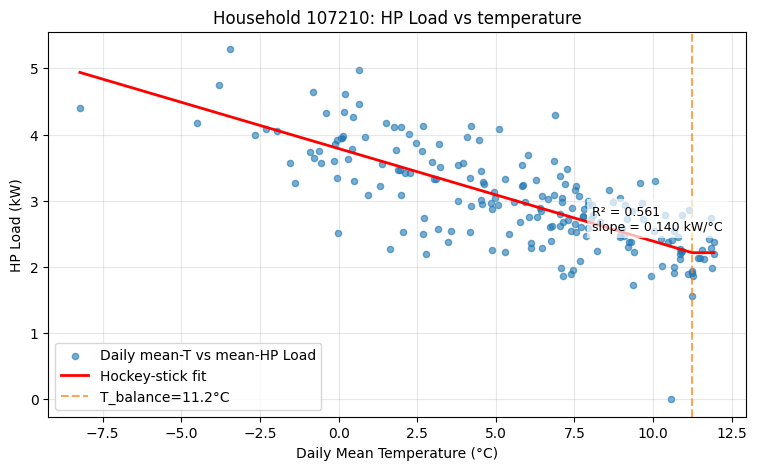

In [ ]:
def plot_hockey_stick_example(household_id, load_col, label,
                              heapo_obj, datarange_df, start_date, end_date,
                              coeffs_df=None):
    """Plot data + fitted hockey-stick curve for one household."""
    sm_data = heapo_obj.load_smart_meter_data(household_id, resolution='15min')
    weather_data = heapo_obj.load_weather_data(
        datarange_df.loc[household_id, 'Weather_ID'], resolution='hourly')

    sm_data = sm_data.dropna(subset=[load_col])
    sm_data = sm_data[(sm_data['Timestamp'] >= pd.Timestamp(start_date, tz='UTC')) &
                      (sm_data['Timestamp'] <= pd.Timestamp(end_date, tz='UTC'))][['Timestamp', load_col]]
    sm_data = sm_data.set_index('Timestamp').resample('1h').sum()

    weather_data = weather_data.dropna(subset=['Temperature_avg_hourly'])
    weather_data = weather_data[(weather_data['Timestamp'] >= pd.Timestamp(start_date, tz='UTC')) &
                                (weather_data['Timestamp'] <= pd.Timestamp(end_date, tz='UTC'))][['Timestamp', 'Temperature_avg_hourly']]
    weather_data = weather_data.set_index('Timestamp')#.resample('15min').mean().interpolate(method='time')

    load_series = sm_data[load_col] * 4
    temp_series  = weather_data['Temperature_avg_hourly']
    x, y = daily_mean_mean_heating_season(temp_series, load_series, HEATING_SEASON_THRESH)

    base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

    x_hat = np.linspace(x.min(), x.max(), 200)
    y_hat = hockey_stick(x_hat, base_load, hp_sensitivity, T_balance)

    plt.figure(figsize=(9, 5))
    plt.scatter(x, y, s=20, alpha=0.6, label=f'Daily mean-T vs mean-{label}')
    plt.plot(x_hat, y_hat, color='red', lw=2, label='Hockey-stick fit')
    plt.axvline(T_balance, color='tab:orange', ls='--', alpha=0.7, label=f'T_balance={T_balance:.1f}°C')
    plt.xlabel('Daily Mean Temperature (°C)')
    plt.ylabel(f'{label} (kW)')
    plt.title(f'Household {household_id}: {label} vs temperature')
    plt.legend(); plt.grid(alpha=0.3)
    plt.text(0.78, 0.55, f'R² = {r2:.3f}\nslope = {hp_sensitivity:.3f} kW/°C',
             transform=plt.gca().transAxes, fontsize=9, va='top',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    plt.show()


example_id = datarangeDf.index[0]

plot_hockey_stick_example(example_id, 'kWh_received_HeatPump', 'HP Load',
                          heapo, datarangeDf, start_date, end_date,
                          coeffs_df=hockey_coeffs_hp_df)


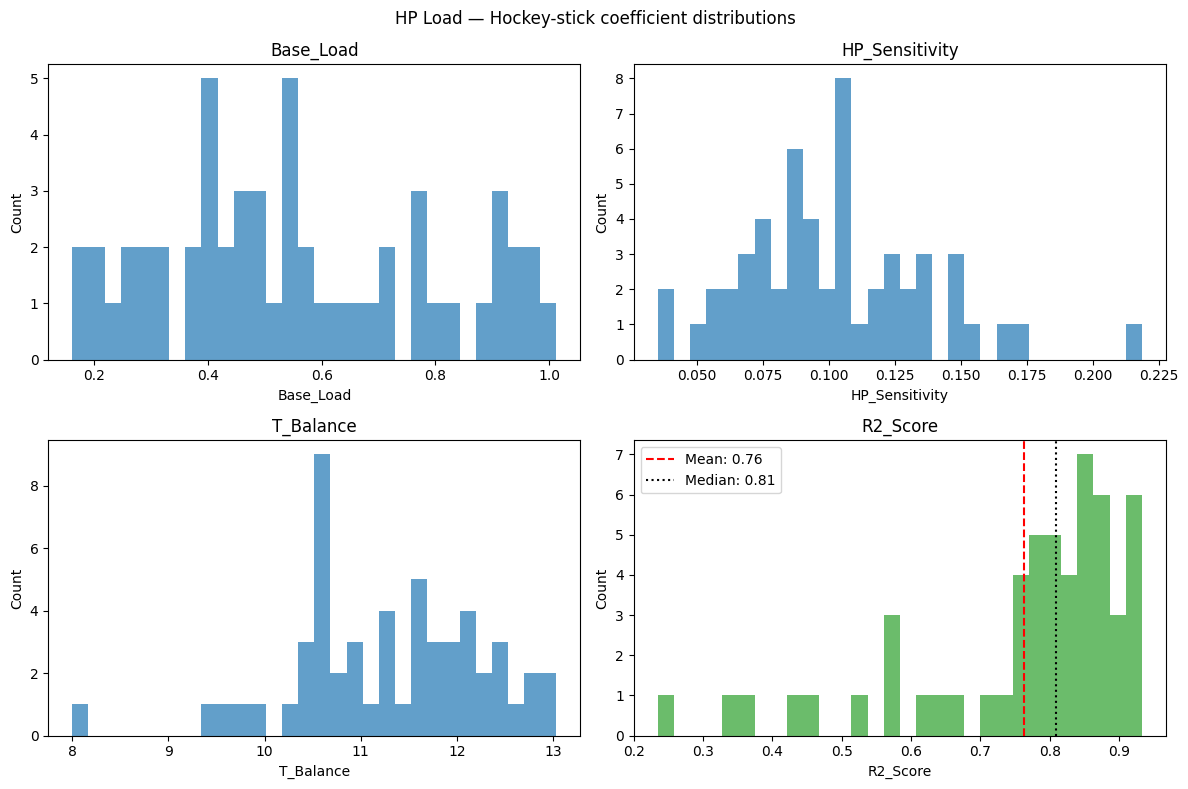

In [ ]:
def plot_hockey_stick_histograms(coeffs_df, title_prefix):
    """Plot distribution of hockey-stick coefficients and R² scores."""
    cols = ['Base_Load', 'HP_Sensitivity', 'T_Balance', 'R2_Score']
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs = axs.flatten()
    for i, col in enumerate(cols):
        ser = coeffs_df[col].dropna()
        ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]
        axs[i].hist(ser, bins=30, color='tab:blue' if col != 'R2_Score' else 'tab:green', alpha=0.7)
        axs[i].set_title(col)
        axs[i].set_xlabel(col)
        axs[i].set_ylabel('Count')
        if col == 'R2_Score':
            axs[i].axvline(ser.mean(),   color='red',   ls='--', lw=1.5, label=f'Mean: {ser.mean():.2f}')
            axs[i].axvline(ser.median(), color='black', ls=':',  lw=1.5, label=f'Median: {ser.median():.2f}')
            axs[i].legend()
    fig.suptitle(f'{title_prefix} — Hockey-stick coefficient distributions')
    fig.tight_layout()
    plt.show()


plot_hockey_stick_histograms(hockey_coeffs_hp_df, 'HP Load')


### Fit household smart-meter (total) load vs temperature (hockey-stick model)

In [ ]:
sm_fit_results = [
    fit_household_hockey_stick(hid, 'kWh_received_Total',
                               heapo, datarangeDf, start_date, end_date)
    for hid in tqdm(datarangeDf.index, desc='Hockey-stick fit: SM total load')
]
sm_fit_results = [r for r in sm_fit_results if r is not None]

hockey_coeffs_sm_df = pd.DataFrame(
    sm_fit_results,
    columns=['Household_ID', 'Base_Load', 'HP_Sensitivity', 'T_Balance', 'R2_Score']
).set_index('Household_ID')


Hockey-stick fit: SM total load: 100%|██████████| 57/57 [00:30<00:00,  1.86it/s]


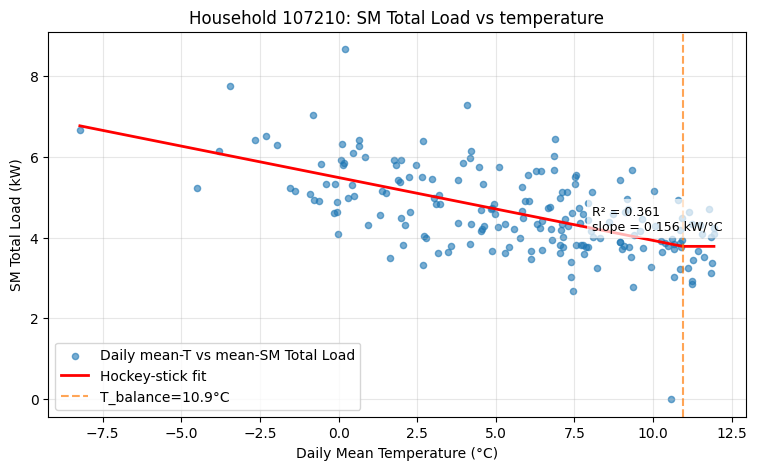

In [ ]:
plot_hockey_stick_example(example_id, 'kWh_received_Total', 'SM Total Load',
                          heapo, datarangeDf, start_date, end_date,
                          coeffs_df=hockey_coeffs_sm_df)


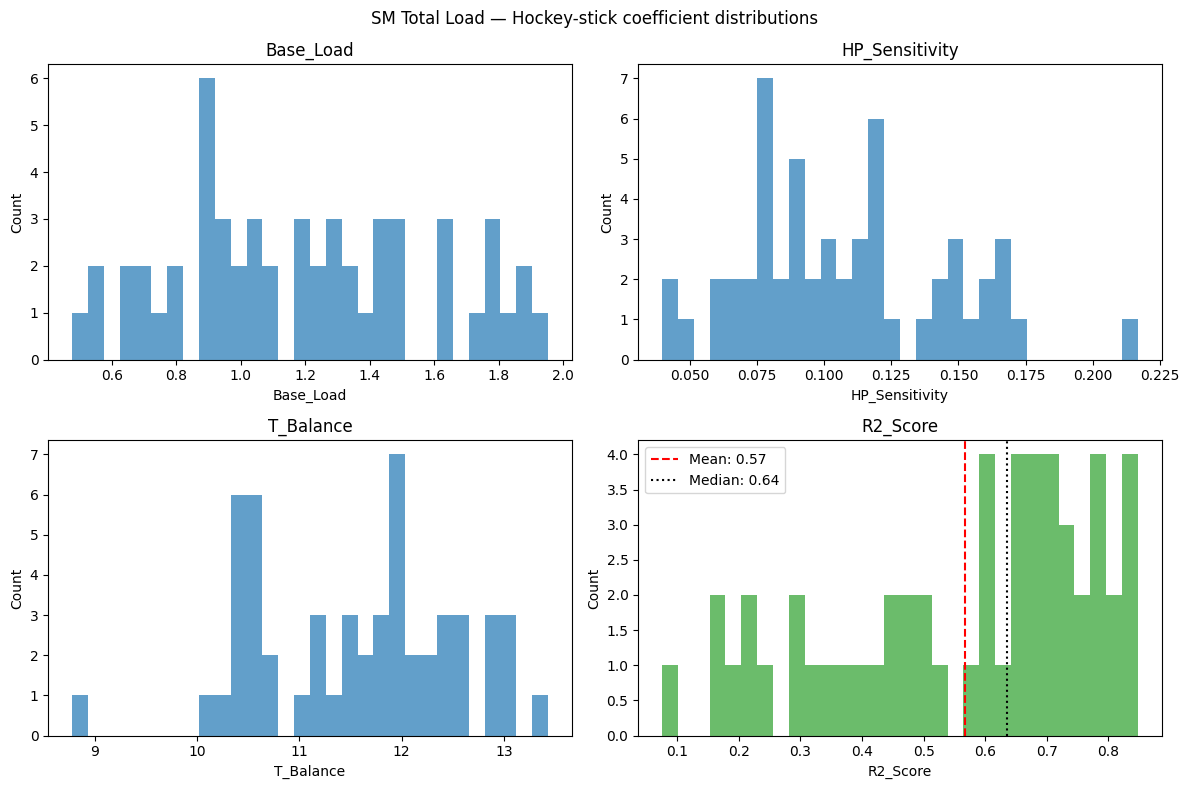

In [ ]:
plot_hockey_stick_histograms(hockey_coeffs_sm_df, 'SM Total Load')


### Create synthetic substations

In [ ]:
all_smd = heapo.load_smart_meter_data_multiple(datarangeDf.index.tolist(), resolution='15min')
all_smd = all_smd[(all_smd['Timestamp'] >= pd.to_datetime(start_date)) & (all_smd['Timestamp'] <= pd.to_datetime(end_date))]
# all_smd = all_smd[all_smd['Timestamp'].dt.weekday < 5]        # only consider weekdays

In [ ]:
if regenerate_substations:
    n_substations = 2000

    substations = {}

    min_substation_size = 20
    max_substation_size = 100

    available_households = list(datarangeDf.index)
    available_weather_ids = list(datarangeDf['Weather_ID'])

    datetime_range = pd.date_range(start=start_date, end=end_date, freq='15min')
    # datetime_range = datetime_range[datetime_range.weekday < 5]  # only consider weekdays

    for i in trange(n_substations, desc='Generating substations'):

        hp_ratio = uniform(0.1, 1.0) # ratio of households with heat pump in substation
        substation_size = randint(min_substation_size, max_substation_size) # number of households in substation

        n_hps = int(hp_ratio * substation_size)

        substations[i] = {
            'size': substation_size,
            'HP_ratio': hp_ratio,
        }

        weather_station = sample(available_weather_ids, 1)[0] # randomly select weather station
        substations[i]['weather_id'] = weather_station

        households_hp = datarangeDf[datarangeDf['Weather_ID'] == weather_station].sample(n_hps, replace=True).index.tolist() # randomly select households with this weather station
        substations[i]['households_hp'] = households_hp

        households = datarangeDf.sample(substation_size - n_hps, replace=True).index.tolist()
        substations[i]['households'] = households

        substations[i]['HP_Load'] = pd.Series(0, index=datetime_range)
        substations[i]['Total_Load'] = pd.Series(0, index=datetime_range)

        for household_id in households_hp:
            smd_hp = all_smd[all_smd['Household_ID'] == household_id]
            smd_hp = smd_hp.set_index('Timestamp')
            smd_hp = smd_hp.sort_index()
            substations[i]['HP_Load'] += smd_hp['kWh_received_HeatPump'].reindex(datetime_range).interpolate(method='time').fillna(0)
            substations[i]['Total_Load'] += smd_hp['kWh_received_Other'].reindex(datetime_range).interpolate(method='time').fillna(0) + smd_hp['kWh_received_HeatPump'].reindex(datetime_range).interpolate(method='time').fillna(0)

        for household_id in households:
            smd = all_smd[all_smd['Household_ID'] == household_id]
            smd = smd.set_index('Timestamp')
            smd = smd.sort_index()
            substations[i]['Total_Load'] += smd['kWh_received_Other'].reindex(datetime_range).interpolate(method='time').fillna(0)

        substations[i]['HP_Load'] = substations[i]['HP_Load'] * 4 # convert to kW
        substations[i]['Total_Load'] = substations[i]['Total_Load'] * 4 # convert to kW

        weather_data = heapo.load_weather_data(weather_station, resolution='hourly')
        weather_data = weather_data[(weather_data['Timestamp'] >= pd.to_datetime(start_date)) & (weather_data['Timestamp'] <= pd.to_datetime(end_date))][['Timestamp', 'Temperature_avg_hourly']]
        # weather_data = weather_data[weather_data['Timestamp'].dt.weekday < 5]        # only consider weekdays
        weather_data = weather_data.set_index('Timestamp')
        weather_data = weather_data.resample('15min').interpolate(method='time')

        substations[i]['Temperature'] = weather_data['Temperature_avg_hourly']

        substations[i]['HP_Peak'] = np.sum([hp_peaks_df[hp_peaks_df['Household_ID'] == household_id]['HP_Peak'].values[0] for household_id in households_hp])

    # Save substations data
    substations_df = pd.DataFrame.from_dict(substations, orient='index')
    pickle.dump(substations_df, open('data/substations_data.pkl', 'wb'))
else:
    substations_df = pickle.load(open('data/substations_data.pkl', 'rb'))

In [ ]:
# FIX: a blanket .fillna(0) here also touched the HP_Load / Total_Load /
# Temperature columns, which hold pd.Series objects -- replacing a whole
# Series with the integer 0, which then silently failed the downstream
# isinstance(..., pd.Series) checks and dropped the substation without
# warning. Fill only the numeric columns, and log anything unusable.
from hp_common import fill_numeric_na, validate_series_columns

substations_df = fill_numeric_na(substations_df)
_, _dropped = validate_series_columns(substations_df)   # log-only, keeps all rows
substations_df_train, substations_df_test = train_test_split(substations_df, test_size=0.5, random_state=42)

validate_series_columns: 2000 of 2000 substations usable (0 dropped for missing/empty series data)


### Fite piecewise function to substation net load

In [ ]:
piece_lin_coeff_sub = []
r2_score_sub = []

for id in tqdm(substations_df_train.index, desc='Fitting hockey-stick model for substations'):
    try:
        x, y = daily_mean_mean_heating_season(
            substations_df_train.loc[id, 'Temperature'],
            substations_df_train.loc[id, 'Total_Load'],
            heating_season_thresh=HEATING_SEASON_THRESH
        )

        if len(x) < MIN_HEATING_DAYS:
            continue

        base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

        r2_score_sub.append((id, r2))
        piece_lin_coeff_sub.append((id, base_load, hp_sensitivity, T_balance))

    except Exception:
        pass

Fitting hockey-stick model for substations: 100%|██████████| 1000/1000 [00:06<00:00, 160.47it/s]


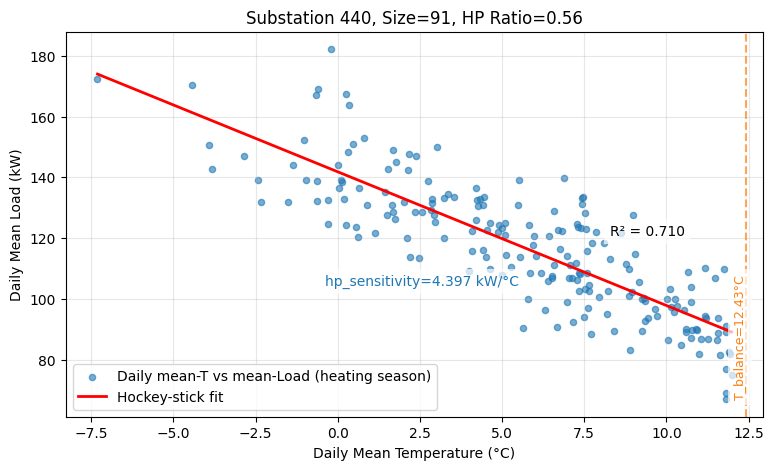

In [ ]:
cols = ['Base_Load', 'HP_Sensitivity', 'T_Balance']

piece_lin_coeff_train_df = pd.DataFrame(piece_lin_coeff_sub, columns=['Substation_ID', 'Base_Load', 'HP_Sensitivity', 'T_Balance'])
piece_lin_coeff_train_df.set_index('Substation_ID', inplace=True)

r2_score_train_df = pd.DataFrame(r2_score_sub, columns=['Substation_ID', 'R2_Score'])
r2_score_train_df.set_index('Substation_ID', inplace=True)

# example plot with one substation and the fitted hockey-stick curve
i = 0
example_id = int(piece_lin_coeff_train_df.index.values[i])

x, y = daily_mean_mean_heating_season(
    substations_df_train.loc[example_id, 'Temperature'],
    substations_df_train.loc[example_id, 'Total_Load'],
    heating_season_thresh=HEATING_SEASON_THRESH
)

base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

x_hat = np.linspace(x.min(), x.max(), 100)
y_hat = hockey_stick(x_hat, base_load, hp_sensitivity, T_balance)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='Daily mean-T vs mean-Load (heating season)')
plt.plot(x_hat, y_hat, color='red', lw=2, label='Hockey-stick fit')
plt.xlabel('Daily Mean Temperature (°C)')
plt.ylabel('Daily Mean Load (kW)')
plt.title(f"Substation {example_id}, Size={substations_df_train.loc[example_id, 'size']}, "
          f"HP Ratio={substations_df_train.loc[example_id, 'HP_ratio']:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.text(0.78, 0.5, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.axvline(T_balance, color='tab:orange', linestyle='--', alpha=0.7)
plt.text(T_balance, y.min(), f'T_balance={T_balance:.2f}°C', color='tab:orange', fontsize=9,
         rotation=90, ha='right', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.text((x.min() + T_balance) / 2, y_hat.max() * 0.6, f'hp_sensitivity={hp_sensitivity:.3f} kW/°C',
         color='tab:blue', fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()

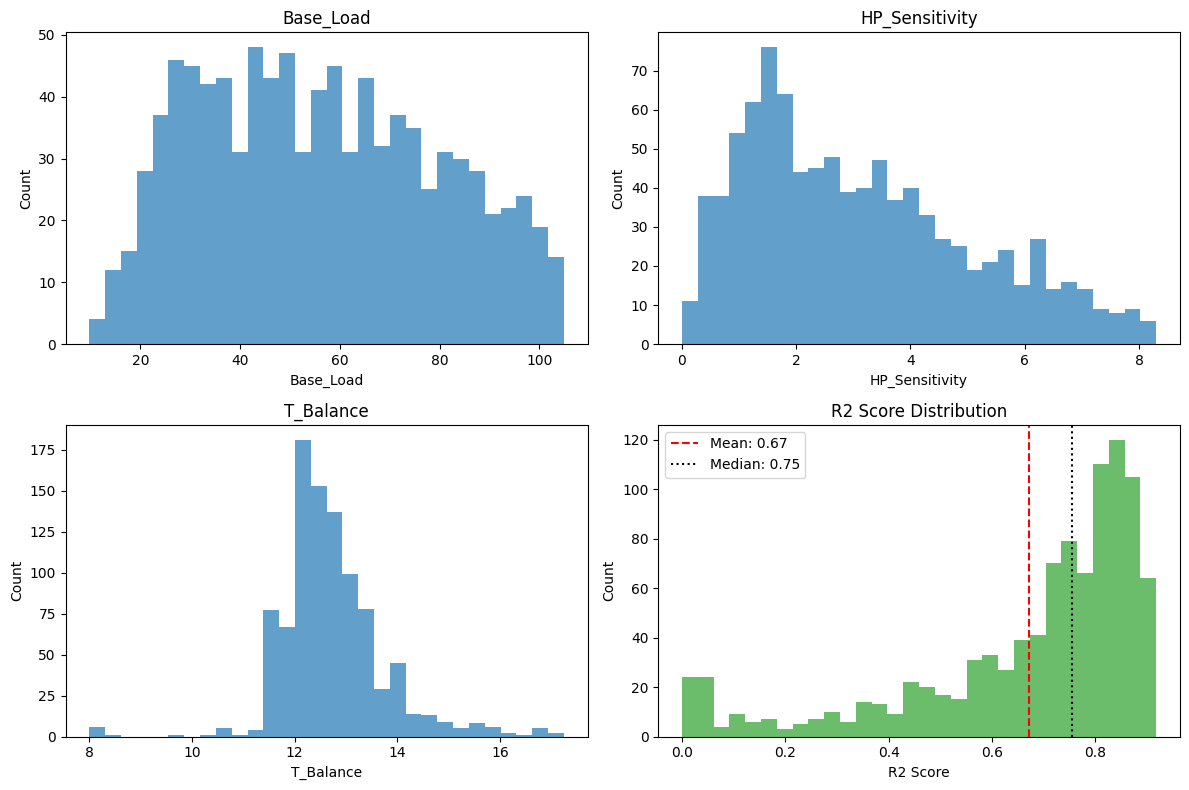

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, col in enumerate(cols):
    ser = piece_lin_coeff_train_df[col].dropna()
    ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]  # remove outliers for better visualization
    axs[i].hist(ser, bins=30, color='tab:blue', alpha=0.7)
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Count')


r2_scores = r2_score_train_df['R2_Score'].dropna()
ax = axs[i+1]
ax.hist(r2_scores, bins=30, color='tab:green', alpha=0.7)
ax.set_title('R2 Score Distribution')
ax.set_xlabel('R2 Score')
ax.set_ylabel('Count')
ax.axvline(r2_scores.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {r2_scores.mean():.2f}')
ax.axvline(r2_scores.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {r2_scores.median():.2f}')
ax.legend()
fig.tight_layout()
plt.show()

R² for HP_Sensitivity vs Simultaneous HP Peak: 0.655
42.824, 3.435
R² for HP_Sensitivity_per_peak vs Simultaneous HP Peak: 0.071


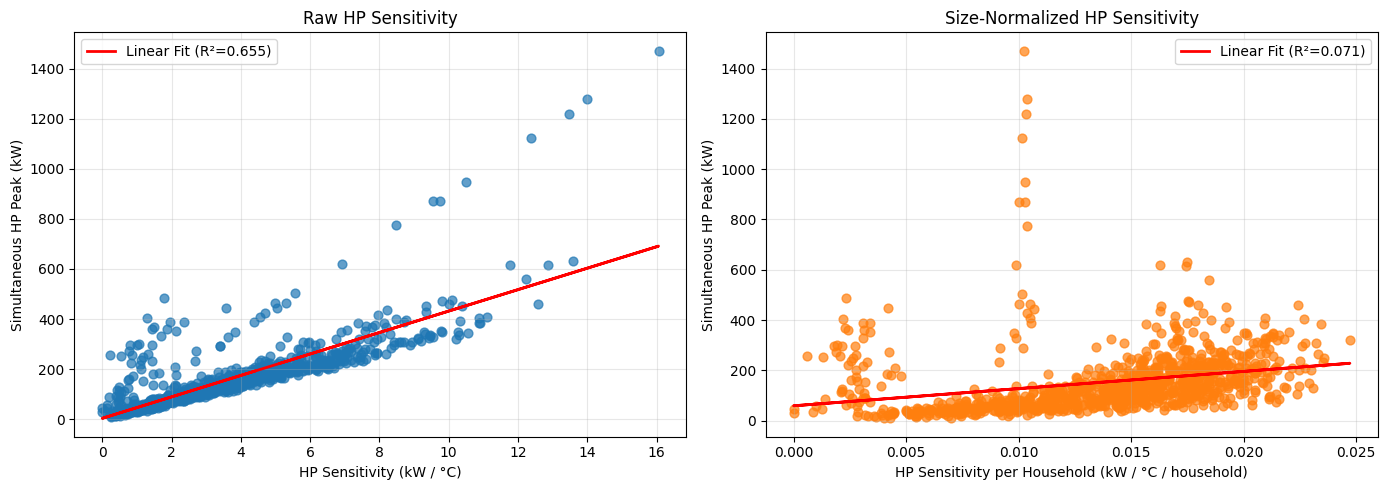

In [ ]:
substations_df_train['Simult_HP_Peak'] = [substations_df_train.iloc[i]['HP_Load'].max() if hp_ratio > 0 else 0 for i, hp_ratio in enumerate(substations_df_train['HP_ratio'])]

data = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train[['Simult_HP_Peak', 'size']])
peak_load_train = substations_df_train['Total_Load'].apply(lambda s: s.max())
data['Peak_Load'] = peak_load_train
data['HP_Sensitivity_per_peak'] = data['HP_Sensitivity'] / data['Peak_Load']

lin = LinearRegression()
lin.fit(data[['HP_Sensitivity']], data['Simult_HP_Peak'])
r2 = lin.score(data[['HP_Sensitivity']], data['Simult_HP_Peak'])
print(f"R² for HP_Sensitivity vs Simultaneous HP Peak: {r2:.3f}")
print(f"{lin.coef_[0]:.3f}, {lin.intercept_:.3f}")

lin_norm = LinearRegression()
lin_norm.fit(data[['HP_Sensitivity_per_peak']], data['Simult_HP_Peak'])
r2_norm = lin_norm.score(data[['HP_Sensitivity_per_peak']], data['Simult_HP_Peak'])
print(f"R² for HP_Sensitivity_per_peak vs Simultaneous HP Peak: {r2_norm:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].scatter(data['HP_Sensitivity'], data['Simult_HP_Peak'], alpha=0.7, s=40)
axs[0].plot(data['HP_Sensitivity'], lin.predict(data[['HP_Sensitivity']]), color='red', linewidth=2, label=f'Linear Fit (R²={r2:.3f})')
axs[0].set_xlabel('HP Sensitivity (kW / °C)')
axs[0].set_ylabel('Simultaneous HP Peak (kW)')
axs[0].set_title('Raw HP Sensitivity')
axs[0].grid(alpha=0.3)
axs[0].legend()

axs[1].scatter(data['HP_Sensitivity_per_peak'], data['Simult_HP_Peak'], alpha=0.7, s=40, color='tab:orange')
axs[1].plot(data['HP_Sensitivity_per_peak'], lin_norm.predict(data[['HP_Sensitivity_per_peak']]), color='red', linewidth=2, label=f'Linear Fit (R²={r2_norm:.3f})')
axs[1].set_xlabel('HP Sensitivity per Household (kW / °C / household)')
axs[1].set_ylabel('Simultaneous HP Peak (kW)')
axs[1].set_title('Size-Normalized HP Sensitivity')
axs[1].grid(alpha=0.3)
axs[1].legend()

fig.tight_layout()
plt.show()

R² for HP_Sensitivity vs Non-Simultaneous HP Peak: 0.856
63.070, 11.106


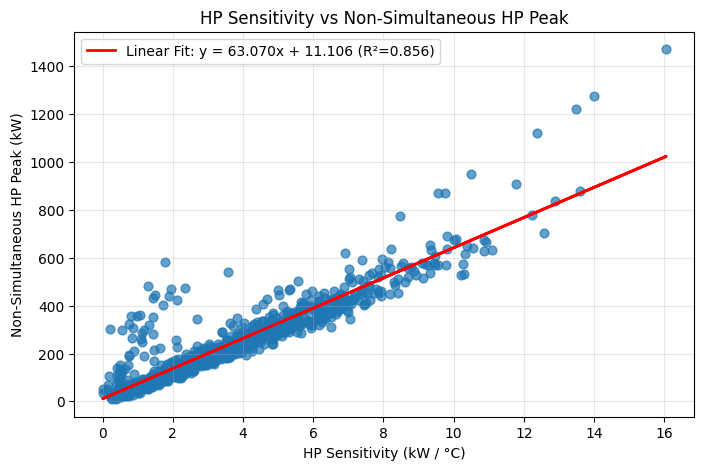

In [ ]:
data = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train[['HP_Peak', 'size']])
peak_load_train = substations_df_train['Total_Load'].apply(lambda s: s.max())
data['Peak_Load'] = peak_load_train
data['HP_Sensitivity_per_peak'] = data['HP_Sensitivity'] / data['Peak_Load']

nonSimDeltaFit = LinearRegression()
nonSimDeltaFit.fit(data[['HP_Sensitivity']], data['HP_Peak'])
r2 = nonSimDeltaFit.score(data[['HP_Sensitivity']], data['HP_Peak'])
print(f"R² for HP_Sensitivity vs Non-Simultaneous HP Peak: {r2:.3f}")
print(f"{nonSimDeltaFit.coef_[0]:.3f}, {nonSimDeltaFit.intercept_:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(data['HP_Sensitivity'], data['HP_Peak'], alpha=0.7, s=40)
plt.plot(data['HP_Sensitivity'], nonSimDeltaFit.predict(data[['HP_Sensitivity']]), color='red', linewidth=2, label=f'Linear Fit: y = {nonSimDeltaFit.coef_[0]:.3f}x + {nonSimDeltaFit.intercept_:.3f} (R²={r2:.3f})')
plt.xlabel('HP Sensitivity (kW / °C)')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous HP Peak')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
piece_lin_coeff_test = []
r2_score_test = []

for id in tqdm(substations_df_test.index, desc='Fitting hockey-stick model for substations (test)'):
    try:
        x, y = daily_mean_mean_heating_season(
            substations_df_test.loc[id, 'Temperature'],
            substations_df_test.loc[id, 'Total_Load'],
            heating_season_thresh=HEATING_SEASON_THRESH
        )

        if len(x) < MIN_HEATING_DAYS:
            continue

        base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

        r2_score_test.append((id, r2))
        piece_lin_coeff_test.append((id, base_load, hp_sensitivity, T_balance))

    except Exception:
        pass

Fitting hockey-stick model for substations (test): 100%|██████████| 1000/1000 [00:06<00:00, 145.12it/s]


In [ ]:
piece_lin_coeff_test_df = pd.DataFrame(piece_lin_coeff_test, columns=['Substation_ID', 'Base_Load', 'HP_Sensitivity', 'T_Balance'])
piece_lin_coeff_test_df.set_index('Substation_ID', inplace=True)

r2_score_test_df = pd.DataFrame(r2_score_test, columns=['Substation_ID', 'R2_Score'])
r2_score_test_df.set_index('Substation_ID', inplace=True)

In [ ]:
piece_lin_coeff_df = pd.concat([piece_lin_coeff_train_df, piece_lin_coeff_test_df])
r2_score_df = pd.concat([r2_score_train_df, r2_score_test_df])

R² for HP_Sensitivity vs Non-Simultaneous HP Peak on test set: 0.864


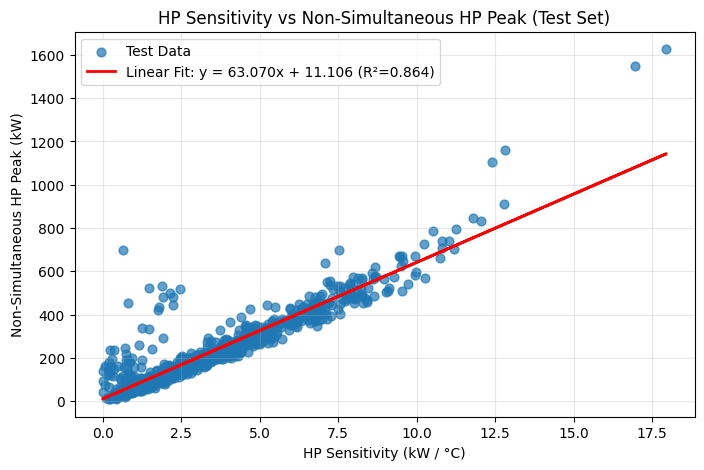

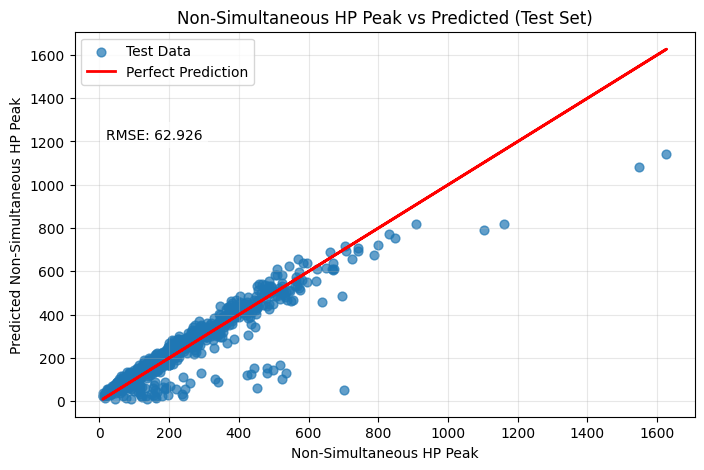

In [ ]:
data_test = piece_lin_coeff_test_df[['HP_Sensitivity']].join(substations_df_test[['HP_Peak']], how='inner')

nonSimTestPred = nonSimDeltaFit.predict(data_test[['HP_Sensitivity']])
r2_nonSimTest = r2_score(data_test['HP_Peak'], nonSimTestPred)
print(f"R² for HP_Sensitivity vs Non-Simultaneous HP Peak on test set: {r2_nonSimTest:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(data_test['HP_Sensitivity'], data_test['HP_Peak'], alpha=0.7, s=40, label='Test Data')
plt.plot(data_test['HP_Sensitivity'], nonSimTestPred, color='red', linewidth=2, label=f'Linear Fit: y = {nonSimDeltaFit.coef_[0]:.3f}x + {nonSimDeltaFit.intercept_:.3f} (R²={r2_nonSimTest:.3f})')
plt.xlabel('HP Sensitivity (kW / °C)')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous HP Peak (Test Set)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(data_test['HP_Peak'], nonSimTestPred, alpha=0.7, s=40, label='Test Data')
plt.plot(data_test['HP_Peak'], data_test['HP_Peak'], color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel('Non-Simultaneous HP Peak')
plt.ylabel('Predicted Non-Simultaneous HP Peak')
plt.title('Non-Simultaneous HP Peak vs Predicted (Test Set)')
plt.text(0.05, 0.75, f'RMSE: {np.sqrt(mean_squared_error(data_test["HP_Peak"], nonSimTestPred)):.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Training R² (weighted): 0.925
Test R²: 0.859
Test RMSE: 64.157 kW
Test MAPE: 16.42%
Linear model: HP_Peak = 67.159 * HP_Sensitivity + -14.025


c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


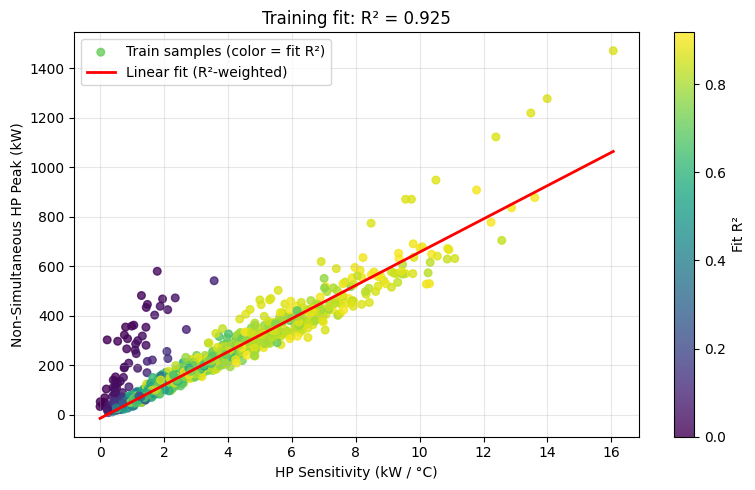

c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


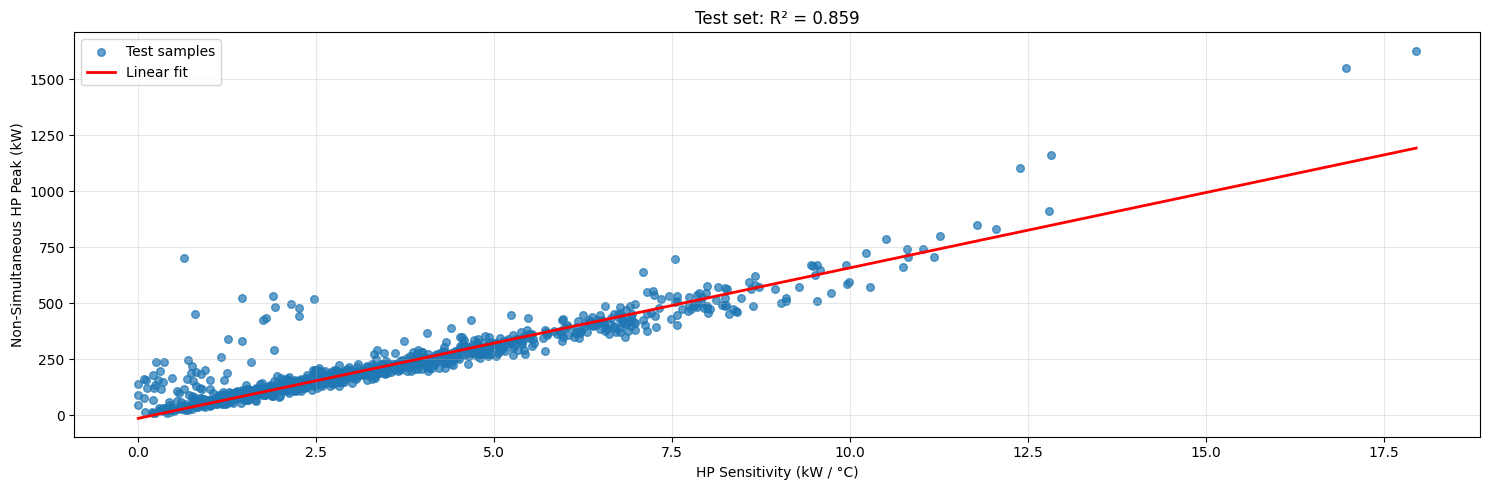

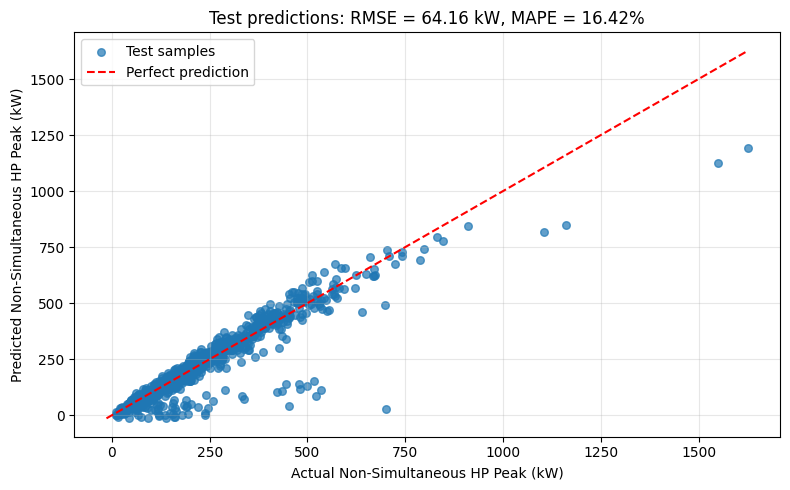

In [ ]:
train_data = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train['HP_Peak'], how='inner').join(r2_score_train_df, how='inner').dropna()

# FIX: weight samples by fit quality (R²) instead of using a hard
# accept/reject threshold -- substations with a noisy/uncertain
# hockey-stick fit contribute less to the regression rather than being
# discarded outright.
sample_weight_train = train_data['R2_Score'].clip(0, 1)

modelLinSlope = LinearRegression()
modelLinSlope.fit(train_data[['HP_Sensitivity']], train_data['HP_Peak'], sample_weight=sample_weight_train)

test_data = piece_lin_coeff_test_df[['HP_Sensitivity']].join(substations_df_test['HP_Peak'], how='inner').dropna()
test_data['Predicted_HP_Peak'] = modelLinSlope.predict(test_data[['HP_Sensitivity']])

r2_train = modelLinSlope.score(train_data[['HP_Sensitivity']], train_data['HP_Peak'], sample_weight=sample_weight_train)
r2_test = r2_score(test_data['HP_Peak'], test_data['Predicted_HP_Peak'])
rmse_test = root_mean_squared_error(test_data['HP_Peak'], test_data['Predicted_HP_Peak'])
small_y_threshold = 10.0
mask = test_data['HP_Peak'].abs() > small_y_threshold
mape_test = mean_absolute_percentage_error(
    test_data.loc[mask, 'HP_Peak'],
    test_data.loc[mask, 'Predicted_HP_Peak']
) * 100

print(f"Training R² (weighted): {r2_train:.3f}")
print(f"Test R²: {r2_test:.3f}")
print(f"Test RMSE: {rmse_test:.3f} kW")
print(f"Test MAPE: {mape_test:.2f}%")
print(f"Linear model: HP_Peak = {modelLinSlope.coef_[0]:.3f} * HP_Sensitivity + {modelLinSlope.intercept_:.3f}")

# Plot training set, colored by fit R² (the sample weight)
fig_train, ax_train = plt.subplots(figsize=(8, 5))
sc = ax_train.scatter(train_data['HP_Sensitivity'], train_data['HP_Peak'], c=sample_weight_train, cmap='viridis', alpha=0.8, s=30, label='Train samples (color = fit R²)')
x_line = np.linspace(train_data['HP_Sensitivity'].min(), train_data['HP_Sensitivity'].max(), 100)
ax_train.plot(x_line, modelLinSlope.predict(x_line.reshape(-1, 1)), color='red', linewidth=2, label='Linear fit (R²-weighted)')
ax_train.set_xlabel('HP Sensitivity (kW / °C)')
ax_train.set_ylabel('Non-Simultaneous HP Peak (kW)')
ax_train.set_title(f'Training fit: R² = {r2_train:.3f}')
ax_train.grid(alpha=0.3)
ax_train.legend()
fig_train.colorbar(sc, ax=ax_train, label='Fit R²')
fig_train.tight_layout()
plt.show()

fig, axs = plt.subplots(figsize=(15, 5))
axs.scatter(test_data['HP_Sensitivity'], test_data['HP_Peak'], alpha=0.7, s=30, label='Test samples')
x_line = np.linspace(test_data['HP_Sensitivity'].min(), test_data['HP_Sensitivity'].max(), 100)
axs.plot(x_line, modelLinSlope.predict(x_line.reshape(-1, 1)), color='red', linewidth=2, label='Linear fit')
axs.set_xlabel('HP Sensitivity (kW / °C)')
axs.set_ylabel('Non-Simultaneous HP Peak (kW)')
axs.set_title(f'Test set: R² = {r2_test:.3f}')
axs.grid(alpha=0.3)
axs.legend()
fig.tight_layout()
plt.show()

# Plot test set predictions vs actual
min_val = min(test_data['HP_Peak'].min(), test_data['Predicted_HP_Peak'].min())
max_val = max(test_data['HP_Peak'].max(), test_data['Predicted_HP_Peak'].max())

fig_test, ax_test = plt.subplots(figsize=(8, 5))
ax_test.scatter(test_data['HP_Peak'], test_data['Predicted_HP_Peak'], alpha=0.7, s=30, label='Test samples')
ax_test.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
ax_test.set_xlabel('Actual Non-Simultaneous HP Peak (kW)')
ax_test.set_ylabel('Predicted Non-Simultaneous HP Peak (kW)')
ax_test.set_title(f'Test predictions: RMSE = {rmse_test:.2f} kW, MAPE = {mape_test:.2f}%')
ax_test.grid(alpha=0.3)
ax_test.legend()
fig_test.tight_layout()
plt.show()

### Extension: Simultaneity Factor from the extended hockey-stick fit

Extrapolate each substation's hockey-stick fit to colder temperatures and
cap the HP component at the installed capacity `HP_Peak` (all heat pumps at
full power at once). The modelled simultaneity factor is
`SF(T) = hp_sensitivity * max(0, T_balance - T) / HP_Peak`.

**Left:** the extrapolated temperature at which the *extended* fit reaches
full heat-pump coincidence (SF = 1). **Right:** the maximum SF the
*non-extended* fit attains within its observed temperature range.

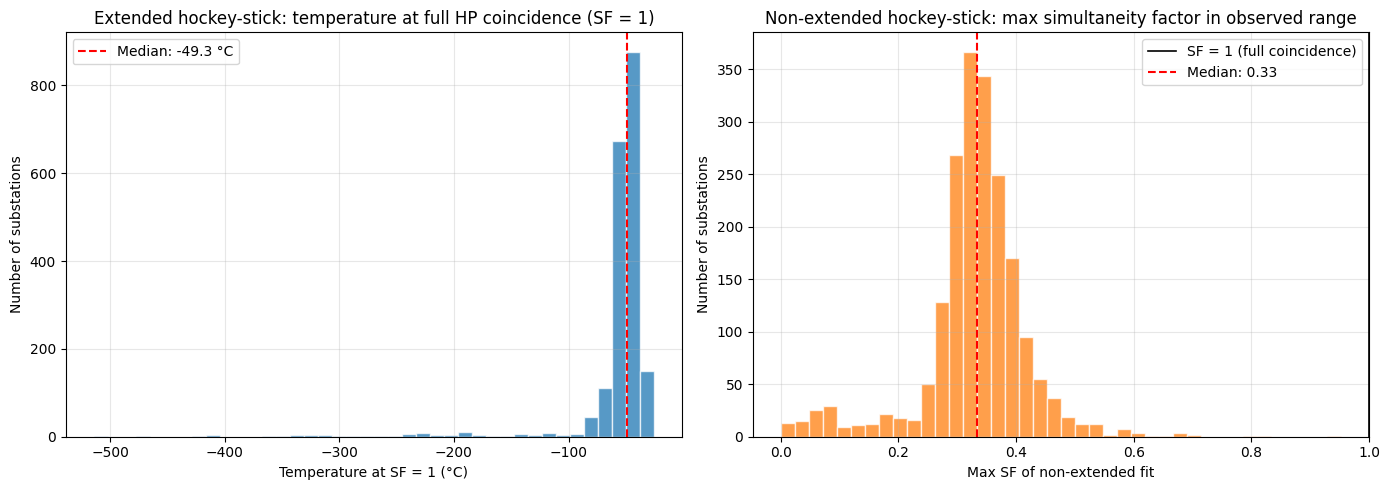

Substations analysed: 2000
SF=1 temperature -- median -49.3 °C; 1997 substations only reach SF=1 below -15 °C (fit too weak to realistically saturate)
Max SF of non-extended fit -- median 0.33; reaches SF>=1 within observed range for 0.0% of substations


In [ ]:
# ---------------------------------------------------------------------------
# Hockey-stick EXTENSION -- simultaneity factor (SF) analysis
#
# The fitted line Load(T) = base_load + hp_sensitivity * max(0, T_balance - T)
# is only constrained by the observed heating-season days. Extrapolating it to
# colder temperatures, the HP component hp_sensitivity*(T_balance - T) keeps
# rising; capping it at the installed capacity HP_Peak (every heat pump at full
# power simultaneously) defines the modelled simultaneity factor:
#
#     SF(T) = hp_sensitivity * max(0, T_balance - T) / HP_Peak      (0 -> 1)
#
# SF = 1 is reached at the extrapolated temperature
#
#     T_SF1 = T_balance - HP_Peak / hp_sensitivity
#
# The NON-extended fit only reaches SF(T_min_observed): the largest SF the raw
# fit attains inside the observed temperature range -- usually < 1.
# ---------------------------------------------------------------------------
sf1_temperatures = []       # extrapolated T where SF reaches 1  (extended fit)
max_sf_non_extended = []    # max SF within observed range       (non-extended fit)

for sid, row in piece_lin_coeff_df.iterrows():
    if sid not in substations_df.index:
        continue
    hp_sens = row['HP_Sensitivity']
    t_balance = row['T_Balance']
    hp_peak = substations_df.loc[sid, 'HP_Peak']
    if not (hp_sens > 0 and hp_peak > 0):
        continue

    # Coldest observed heating-season daily-mean temperature for this substation
    try:
        x, _ = daily_mean_mean_heating_season(
            substations_df.loc[sid, 'Temperature'],
            substations_df.loc[sid, 'Total_Load'],
            heating_season_thresh=HEATING_SEASON_THRESH,
        )
    except Exception:
        continue
    if len(x) == 0:
        continue
    t_min_obs = float(np.min(x))

    sf1_temperatures.append(t_balance - hp_peak / hp_sens)
    max_sf_non_extended.append(hp_sens * max(0.0, t_balance - t_min_obs) / hp_peak)

sf1_temperatures = np.array(sf1_temperatures)
max_sf_non_extended = np.array(max_sf_non_extended)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: extrapolated temperature at which the extended fit reaches SF = 1
lo, hi = np.percentile(sf1_temperatures, [1, 99])
axs[0].hist(sf1_temperatures, bins=40, range=(lo, hi),
            color='tab:blue', alpha=0.75, edgecolor='white')
axs[0].axvline(np.median(sf1_temperatures), color='red', ls='--', lw=1.5,
               label=f'Median: {np.median(sf1_temperatures):.1f} °C')
axs[0].set_xlabel('Temperature at SF = 1 (°C)')
axs[0].set_ylabel('Number of substations')
axs[0].set_title('Extended hockey-stick: temperature at full HP coincidence (SF = 1)')
axs[0].grid(alpha=0.3)
axs[0].legend()

# Plot B: maximum SF the non-extended fit reaches inside the observed range
axs[1].hist(max_sf_non_extended, bins=40, color='tab:orange', alpha=0.75, edgecolor='white')
axs[1].axvline(1.0, color='black', lw=1.2, label='SF = 1 (full coincidence)')
axs[1].axvline(np.median(max_sf_non_extended), color='red', ls='--', lw=1.5,
               label=f'Median: {np.median(max_sf_non_extended):.2f}')
axs[1].set_xlabel('Max SF of non-extended fit')
axs[1].set_ylabel('Number of substations')
axs[1].set_title('Non-extended hockey-stick: max simultaneity factor in observed range')
axs[1].grid(alpha=0.3)
axs[1].legend()

fig.tight_layout()
plt.show()

frac_reach = np.mean(max_sf_non_extended >= 1.0) * 100
n_implausible = int(np.sum(sf1_temperatures < -15.0))
print(f'Substations analysed: {len(sf1_temperatures)}')
print(f'SF=1 temperature -- median {np.median(sf1_temperatures):.1f} °C; '
      f'{n_implausible} substations only reach SF=1 below -15 °C '
      f'(fit too weak to realistically saturate)')
print(f'Max SF of non-extended fit -- median {np.median(max_sf_non_extended):.2f}; '
      f'reaches SF>=1 within observed range for {frac_reach:.1f}% of substations')


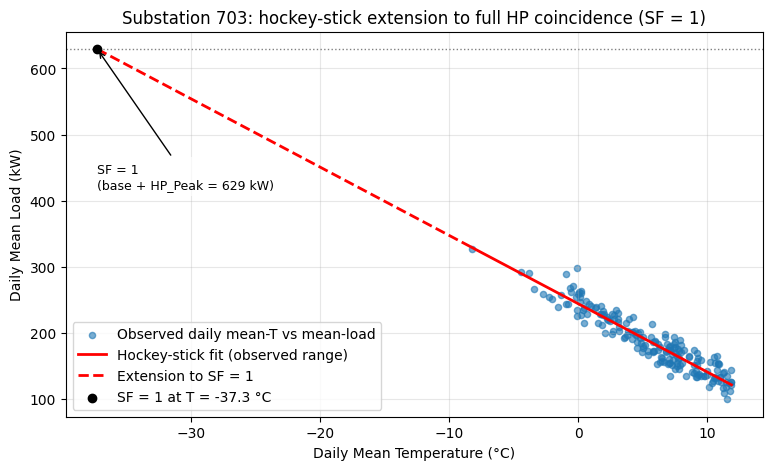

In [ ]:
# ---------------------------------------------------------------------------
# Example of the hockey-stick extension for one substation:
#   scatter : observed daily mean-T / mean-load points
#   solid   : hockey-stick fit over the observed temperature range
#   dashed  : extrapolation (extension) down to the temperature where the HP
#             component reaches installed capacity HP_Peak (SF = 1)
# The example substation is auto-picked: a good fit (R2 > 0.5) whose SF = 1
# sits just beyond the observed data, so the dashed segment is short and clear.
# ---------------------------------------------------------------------------
def plot_hockey_extension_example(sid):
    x, y = daily_mean_mean_heating_season(
        substations_df.loc[sid, 'Temperature'],
        substations_df.loc[sid, 'Total_Load'],
        heating_season_thresh=HEATING_SEASON_THRESH,
    )
    base_load = piece_lin_coeff_df.loc[sid, 'Base_Load']
    hp_sens   = piece_lin_coeff_df.loc[sid, 'HP_Sensitivity']
    t_balance = piece_lin_coeff_df.loc[sid, 'T_Balance']
    hp_peak   = substations_df.loc[sid, 'HP_Peak']

    t_sf1 = t_balance - hp_peak / hp_sens      # temperature at SF = 1
    load_sf1 = base_load + hp_peak             # total load at SF = 1

    # solid fit over the observed range, dashed extension colder than observed
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = hockey_stick(x_fit, base_load, hp_sens, t_balance)
    cold_end = min(t_sf1, x.min())

    plt.figure(figsize=(9, 5))
    plt.scatter(x, y, s=20, alpha=0.6, label='Observed daily mean-T vs mean-load')
    plt.plot(x_fit, y_fit, color='red', lw=2, label='Hockey-stick fit (observed range)')
    if cold_end < x.min():
        x_ext = np.linspace(cold_end, x.min(), 200)
        y_ext = hockey_stick(x_ext, base_load, hp_sens, t_balance)
        plt.plot(x_ext, y_ext, color='red', lw=2, ls='--', label='Extension to SF = 1')
    plt.axhline(load_sf1, color='gray', ls=':', lw=1)
    plt.scatter([t_sf1], [load_sf1], color='black', zorder=5,
                label=f'SF = 1 at T = {t_sf1:.1f} °C')
    plt.annotate(f'SF = 1\n(base + HP_Peak = {load_sf1:.0f} kW)',
                 xy=(t_sf1, load_sf1),
                 xytext=(t_sf1, load_sf1 * 2 / 3),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9, ha='left',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    plt.xlabel('Daily Mean Temperature (°C)')
    plt.ylabel('Daily Mean Load (kW)')
    plt.title(f'Substation {sid}: hockey-stick extension to full HP coincidence (SF = 1)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# --- pick an illustrative substation (good fit, SF=1 just beyond the data) ---
_cand = (piece_lin_coeff_train_df
         .join(r2_score_train_df, how='inner')
         .join(substations_df[['HP_Peak']], how='inner'))
_cand = _cand[(_cand['HP_Sensitivity'] > 0) & (_cand['HP_Peak'] > 0) & (_cand['R2_Score'] > 0.5)]
_cand = _cand.sort_values('R2_Score', ascending=False).head(60)

_best_id, _best_key = None, -np.inf
for _sid, _r in _cand.iterrows():
    try:
        _xx, _ = daily_mean_mean_heating_season(
            substations_df.loc[_sid, 'Temperature'],
            substations_df.loc[_sid, 'Total_Load'],
            heating_season_thresh=HEATING_SEASON_THRESH)
    except Exception:
        continue
    if len(_xx) == 0:
        continue
    _sf_max = _r['HP_Sensitivity'] * max(0.0, _r['T_Balance'] - float(np.min(_xx))) / _r['HP_Peak']
    # prefer SF=1 just beyond the data: sf_max as large as possible but <= 1
    _key = _sf_max if _sf_max <= 1.0 else (2.0 - _sf_max)
    if _key > _best_key:
        _best_key, _best_id = _key, _sid

example_ext_id = int(_best_id) if _best_id is not None else int(piece_lin_coeff_train_df.index[0])
plot_hockey_extension_example(example_ext_id)


Design SF=1 temperature (median over train): -49.3 °C


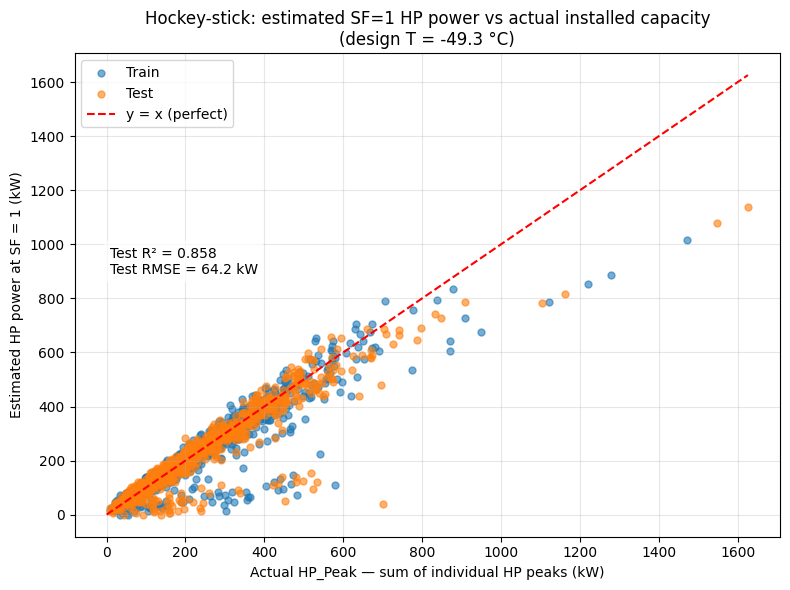

In [ ]:
# ---------------------------------------------------------------------------
# Estimated HP peak POWER at SF = 1 vs actual installed capacity (HP_Peak)
#
# The SF=1 reference temperature is the MEDIAN of the per-substation SF=1
# temperatures on the TRAINING set (T_SF1 = T_balance - HP_Peak/hp_sensitivity).
# Every substation's fitted function is then evaluated at this shared design
# temperature to estimate the fully-coincident (SF=1) HP power:
#
#     est_HP_power = hp_sensitivity * max(0, T_balance - T_design)
#
# T_design does not use each substation's own HP_Peak, so plotting the estimate
# against the actual HP_Peak (sum of individual HP peaks) is a genuine check.
# ---------------------------------------------------------------------------
# Design temperature = median SF=1 temperature over the training substations
_hk = piece_lin_coeff_train_df.join(substations_df[['HP_Peak']], how='inner')
_hk = _hk[(_hk['HP_Sensitivity'] > 0) & (_hk['HP_Peak'] > 0)]
_hk_t_sf1 = _hk['T_Balance'] - _hk['HP_Peak'] / _hk['HP_Sensitivity']
T_design = float(np.median(_hk_t_sf1))
print(f'Design SF=1 temperature (median over train): {T_design:.1f} °C')

# Evaluate every substation's fit at the shared design temperature
est = piece_lin_coeff_df.join(substations_df[['HP_Peak']], how='inner')
est = est[(est['HP_Sensitivity'] > 0) & (est['HP_Peak'] > 0)].copy()
est['Est_HP_Power_SF1'] = est['HP_Sensitivity'] * np.maximum(0.0, est['T_Balance'] - T_design)

train_ids = est.index.intersection(substations_df_train.index)
test_ids = est.index.intersection(substations_df_test.index)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(est.loc[train_ids, 'HP_Peak'], est.loc[train_ids, 'Est_HP_Power_SF1'],
           s=25, alpha=0.6, color='tab:blue', label='Train')
ax.scatter(est.loc[test_ids, 'HP_Peak'], est.loc[test_ids, 'Est_HP_Power_SF1'],
           s=25, alpha=0.6, color='tab:orange', label='Test')
lim = float(max(est['HP_Peak'].max(), est['Est_HP_Power_SF1'].max()))
ax.plot([0, lim], [0, lim], 'r--', label='y = x (perfect)')
ax.set_xlabel('Actual HP_Peak — sum of individual HP peaks (kW)')
ax.set_ylabel('Estimated HP power at SF = 1 (kW)')
ax.set_title(f'Hockey-stick: estimated SF=1 HP power vs actual installed capacity\n(design T = {T_design:.1f} °C)')
ax.grid(alpha=0.3)
ax.legend()

yt, yp = est.loc[test_ids, 'HP_Peak'], est.loc[test_ids, 'Est_HP_Power_SF1']
r2_est = r2_score(yt, yp)
rmse_est = root_mean_squared_error(yt, yp)
ax.text(0.05, 0.6, f'Test R² = {r2_est:.3f}\nTest RMSE = {rmse_est:.1f} kW',
        transform=ax.transAxes, va='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
fig.tight_layout()
plt.show()


### Fit piecewise function to time-of-day indexed data

In [ ]:
# FIX: previously fit 24 separate unconstrained 2-segment pwlf models per
# substation (one per hour), producing 120 often-noisy coefficients and
# visibly degenerate fits (S1 < -1000 outliers, see the diagnostic below).
# Instead, pool hours into 4 broader time-of-day windows and fit the same
# constrained hockey-stick model used for the daily fit above.
from hp_common import hour_groups   # shared time-of-day windows

piece_lin_coeff_hourly = {}
r2_score_hourly = {}

for id in tqdm(substations_df_train.index, desc='Fitting hockey-stick model by time-of-day window'):
    try:
        temp_h = substations_df_train.loc[id, 'Temperature'].resample('h').mean()
        load_h = substations_df_train.loc[id, 'Total_Load'].resample('h').mean()

        sm_data = pd.DataFrame({'Temperature': temp_h, 'Total_Load': load_h}).dropna()

        piece_lin_coeff_hourly[id] = {}
        r2_score_hourly[id] = {}

        for group_name, hours in hour_groups.items():
            group_data = sm_data[sm_data.index.hour.isin(hours)]

            x = group_data['Temperature'].values
            y = group_data['Total_Load'].values

            if len(x) < MIN_HEATING_DAYS:
                continue

            try:
                base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)
            except Exception:
                continue

            piece_lin_coeff_hourly[id][f'{group_name}_BaseLoad'] = base_load
            piece_lin_coeff_hourly[id][f'{group_name}_Sensitivity'] = hp_sensitivity
            piece_lin_coeff_hourly[id][f'{group_name}_TBalance'] = T_balance
            r2_score_hourly[id][group_name] = r2

    except Exception:
        pass

Fitting hockey-stick model by time-of-day window: 100%|██████████| 1000/1000 [00:22<00:00, 45.44it/s]


In [ ]:
piece_lin_coeff_hourly_df = pd.DataFrame.from_dict(piece_lin_coeff_hourly, orient='index')
piece_lin_coeff_hourly_df.index.name = 'Substation_ID'

r2_score_hourly_df = pd.DataFrame.from_dict(r2_score_hourly, orient='index')
r2_score_hourly_df.index.name = 'Substation_ID'

sensitivity_cols = [c for c in piece_lin_coeff_hourly_df.columns if c.endswith('_Sensitivity')]

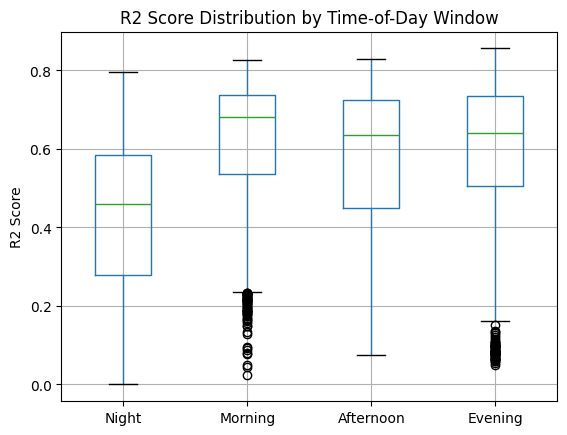

In [ ]:
r2_score_hourly_df.boxplot()
plt.title('R2 Score Distribution by Time-of-Day Window')
plt.ylabel('R2 Score')
plt.show()

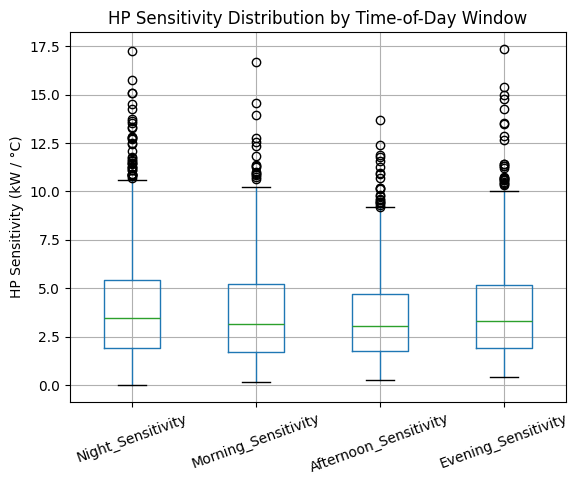

In [ ]:
piece_lin_coeff_hourly_df[sensitivity_cols].boxplot()
plt.title('HP Sensitivity Distribution by Time-of-Day Window')
plt.ylabel('HP Sensitivity (kW / °C)')
plt.xticks(rotation=20)
plt.show()

In [ ]:
# sensitivity_cols already isolated in cell 46; kept here under the
# original variable name for continuity with anything downstream.
piece_lin_coeff_hourly_df_s1 = piece_lin_coeff_hourly_df[sensitivity_cols]
piece_lin_coeff_hourly_df_s1.head()

,Night_Sensitivity,Morning_Sensitivity,Afternoon_Sensitivity,Evening_Sensitivity
Substation_ID,,,,
440,4.893046,5.336948,4.596630,4.726284
573,4.123676,3.444076,3.356661,3.785564
946,0.916265,1.091516,1.354633,1.705354
997,4.113563,4.926133,4.168861,4.107127
503,4.143730,5.450327,4.477484,4.723925


In [ ]:
# Correlation of each time-window's HP sensitivity with HP_Peak.
combined_df = piece_lin_coeff_hourly_df[sensitivity_cols].join(substations_df_train['HP_Peak'])

correlation_matrix = combined_df.corr()
hp_peak_correlations = correlation_matrix['HP_Peak'].drop('HP_Peak')

print("Correlation of time-window HP Sensitivity with HP_Peak:")
display(hp_peak_correlations.to_frame().T.style.background_gradient(cmap='RdYlGn', axis=1))

Correlation of time-window HP Sensitivity with HP_Peak:


,Night_Sensitivity,Morning_Sensitivity,Afternoon_Sensitivity,Evening_Sensitivity
HP_Peak,0.925710,0.938835,0.941531,0.952557


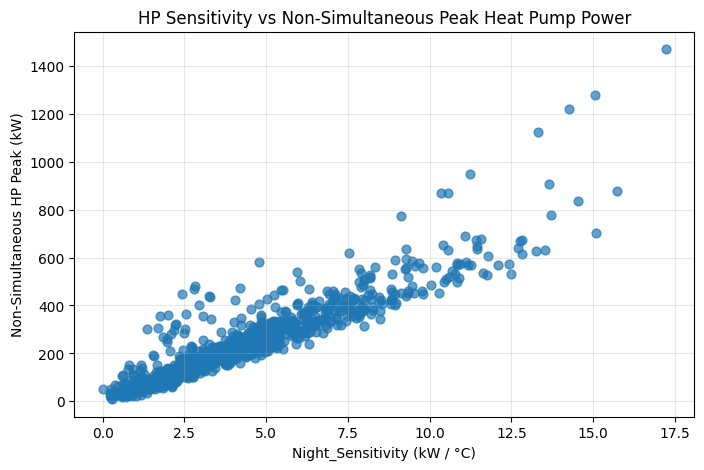

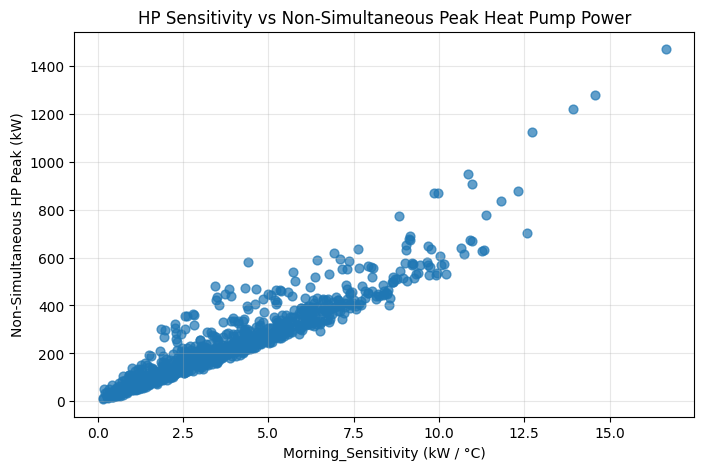

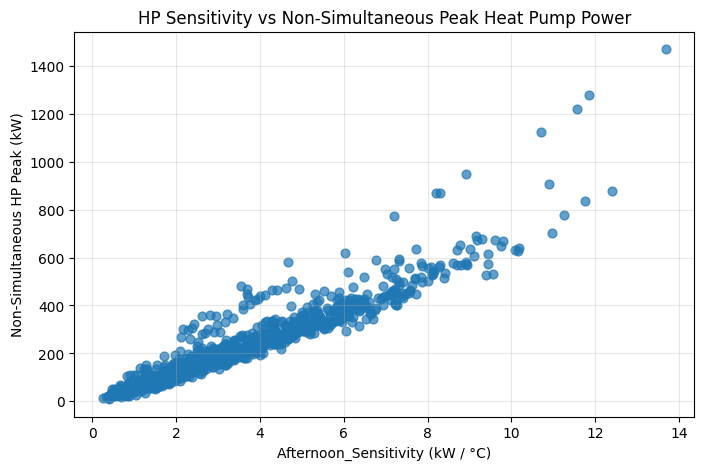

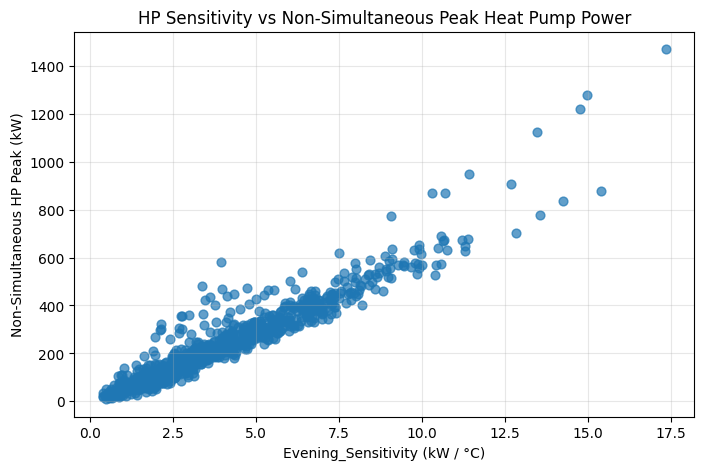

In [ ]:
for col in sensitivity_cols:
    plt.figure(figsize=(8, 5))
    plt.scatter(combined_df[col], combined_df['HP_Peak'], alpha=0.7, s=40)
    plt.xlabel(f'{col} (kW / °C)')
    plt.ylabel('Non-Simultaneous HP Peak (kW)')
    plt.title('HP Sensitivity vs Non-Simultaneous Peak Heat Pump Power')
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
piece_lin_coeff_hourly_test = {}
r2_score_hourly_test = {}

for id in tqdm(substations_df_test.index, desc='Fitting hockey-stick model by time-of-day window'):
    try:
        temp_h = substations_df_test.loc[id, 'Temperature'].resample('h').mean()
        load_h = substations_df_test.loc[id, 'Total_Load'].resample('h').mean()

        sm_data = pd.DataFrame({'Temperature': temp_h, 'Total_Load': load_h}).dropna()

        piece_lin_coeff_hourly_test[id] = {}
        r2_score_hourly_test[id] = {}

        for group_name, hours in hour_groups.items():
            group_data = sm_data[sm_data.index.hour.isin(hours)]

            x = group_data['Temperature'].values
            y = group_data['Total_Load'].values

            if len(x) < MIN_HEATING_DAYS:
                continue

            try:
                base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)
            except Exception:
                continue

            piece_lin_coeff_hourly_test[id][f'{group_name}_BaseLoad'] = base_load
            piece_lin_coeff_hourly_test[id][f'{group_name}_Sensitivity'] = hp_sensitivity
            piece_lin_coeff_hourly_test[id][f'{group_name}_TBalance'] = T_balance
            r2_score_hourly_test[id][group_name] = r2

    except Exception:
        pass

Fitting hockey-stick model by time-of-day window: 100%|██████████| 1000/1000 [00:21<00:00, 45.59it/s]


In [ ]:
piece_lin_coeff_hourly_test_df = pd.DataFrame.from_dict(piece_lin_coeff_hourly_test, orient='index')
piece_lin_coeff_hourly_test_df.index.name = 'Substation_ID'

r2_score_hourly_test_df = pd.DataFrame.from_dict(r2_score_hourly_test, orient='index')
r2_score_hourly_test_df.index.name = 'Substation_ID'

In [ ]:
combined_test_df = piece_lin_coeff_hourly_test_df[sensitivity_cols].join(substations_df_test['HP_Peak'])

Selected Ridge alpha: 2.6827


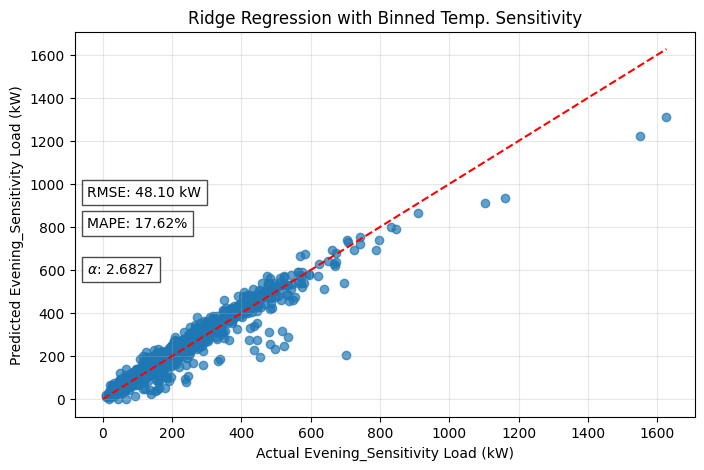

In [ ]:
sensitivity_model = RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)
sensitivity_model.fit(combined_df[sensitivity_cols], combined_df['HP_Peak'])
print(f"Selected Ridge alpha: {sensitivity_model.alpha_:.4f}")

sensitivity_pred = sensitivity_model.predict(combined_test_df[sensitivity_cols])
sensitivity_pred = np.maximum(sensitivity_pred, 0) # ensure no negative predictions

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(combined_test_df['HP_Peak'], sensitivity_pred, alpha=0.7)
ax.plot([0, combined_test_df['HP_Peak'].max()], [0, combined_test_df['HP_Peak'].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'Ridge Regression with Binned Temp. Sensitivity')
mask = combined_test_df['HP_Peak'].values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(combined_test_df['HP_Peak'].values[mask], sensitivity_pred[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(combined_test_df['HP_Peak'].values, sensitivity_pred)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.02, 0.4, f'$\\alpha$: {sensitivity_model.alpha_:.4f}', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.grid(alpha=0.3)
plt.show()

## Simultaneity Factor vs Temperature

For every substation the instantaneous simultaneity factor
`SF(t) = HP_Load(t) / HP_Peak` (bounded in [0, 1]) is averaged to daily means
and fitted **per substation** with a hockey-stick curve
`SF(T) = base + slope * max(0, T_threshold - T)` — the same manner as the
earlier per-substation hockey-stick fits. Below: the coefficient table, an
example substation fit, and the distributions of the fitted threshold
temperature, slope, and maximum SF across substations.

In [ ]:
# ---------------------------------------------------------------------------
# Per-substation hockey-stick fit of daily-mean SF vs daily-mean temperature.
# SF(t) = HP_Load(t) / HP_Peak, averaged to daily means, then fit per substation
# (same manner as the earlier per-substation hockey-stick fits):
#     SF(T) = base + slope * max(0, T_threshold - T)
# Max_SF is the fitted SF at the coldest observed daily-mean temperature.
# ---------------------------------------------------------------------------
sf_hockey_coeff = []

for sid in tqdm(substations_df_train.index, desc='SF hockey-stick fit per substation'):
    try:
        hp_peak = substations_df_train.loc[sid, 'HP_Peak']
        if hp_peak <= 0:
            continue
        hp_load = substations_df_train.loc[sid, 'HP_Load']
        temp = substations_df_train.loc[sid, 'Temperature']
        if not isinstance(hp_load, pd.Series) or not isinstance(temp, pd.Series):
            continue

        sf = hp_load / hp_peak                       # instantaneous SF per datapoint
        daily = pd.DataFrame({
            'Temp': temp.resample('D').mean(),
            'SF': sf.resample('D').mean(),
        }).dropna()
        if len(daily) < MIN_HEATING_DAYS:
            continue

        x = daily['Temp'].values
        y = daily['SF'].values
        base, slope, t_threshold, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

        max_sf = float(hockey_stick(x.min(), base, slope, t_threshold))
        sf_hockey_coeff.append((sid, base, slope, t_threshold, max_sf, r2))
    except Exception:
        continue

sf_coeffs_df = pd.DataFrame(
    sf_hockey_coeff,
    columns=['Substation_ID', 'Base_SF', 'Slope', 'T_Threshold', 'Max_SF', 'R2_Score'],
).set_index('Substation_ID')
print(f'Fitted SF-vs-temperature hockey stick for {len(sf_coeffs_df)} substations')
sf_coeffs_df.describe()


SF hockey-stick fit per substation: 100%|██████████| 1000/1000 [00:08<00:00, 121.08it/s]

Fitted SF-vs-temperature hockey stick for 1000 substations


,Base_SF,Slope,T_Threshold,Max_SF,R2_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.028118,0.014982,16.183841,0.387035,0.940743
std,0.011886,0.002861,1.317286,0.064820,0.107416
min,0.009418,0.003960,13.002816,0.179936,0.162125
25%,0.023720,0.014067,15.779101,0.365711,0.960897
50%,0.026224,0.015421,16.246587,0.397053,0.969547
75%,0.029045,0.016615,16.606317,0.425845,0.973952
max,0.116905,0.024085,20.000000,0.586498,0.989524


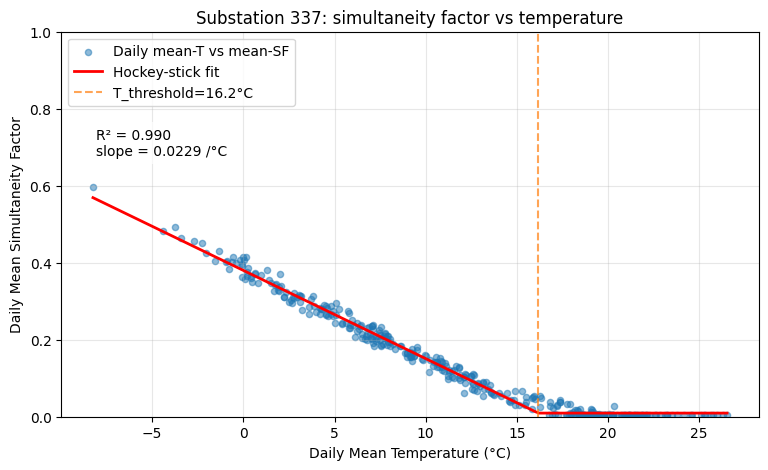

In [ ]:
# Example: one substation's SF-vs-temperature hockey-stick fit (best R²)
example_sf_id = int(sf_coeffs_df['R2_Score'].idxmax())

hp_peak = substations_df_train.loc[example_sf_id, 'HP_Peak']
sf = substations_df_train.loc[example_sf_id, 'HP_Load'] / hp_peak
temp = substations_df_train.loc[example_sf_id, 'Temperature']
daily = pd.DataFrame({'Temp': temp.resample('D').mean(),
                      'SF': sf.resample('D').mean()}).dropna()
x, y = daily['Temp'].values, daily['SF'].values

base = sf_coeffs_df.loc[example_sf_id, 'Base_SF']
slope = sf_coeffs_df.loc[example_sf_id, 'Slope']
t_thr = sf_coeffs_df.loc[example_sf_id, 'T_Threshold']
r2 = sf_coeffs_df.loc[example_sf_id, 'R2_Score']

x_hat = np.linspace(x.min(), x.max(), 200)
y_hat = hockey_stick(x_hat, base, slope, t_thr)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=20, alpha=0.5, label='Daily mean-T vs mean-SF')
plt.plot(x_hat, y_hat, color='red', lw=2, label='Hockey-stick fit')
plt.axvline(t_thr, color='tab:orange', ls='--', alpha=0.7, label=f'T_threshold={t_thr:.1f}°C')
plt.xlabel('Daily Mean Temperature (°C)')
plt.ylabel('Daily Mean Simultaneity Factor')
plt.title(f'Substation {example_sf_id}: simultaneity factor vs temperature')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.text(0.05, 0.75, f'R² = {r2:.3f}\nslope = {slope:.4f} /°C',
         transform=plt.gca().transAxes, va='top',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()


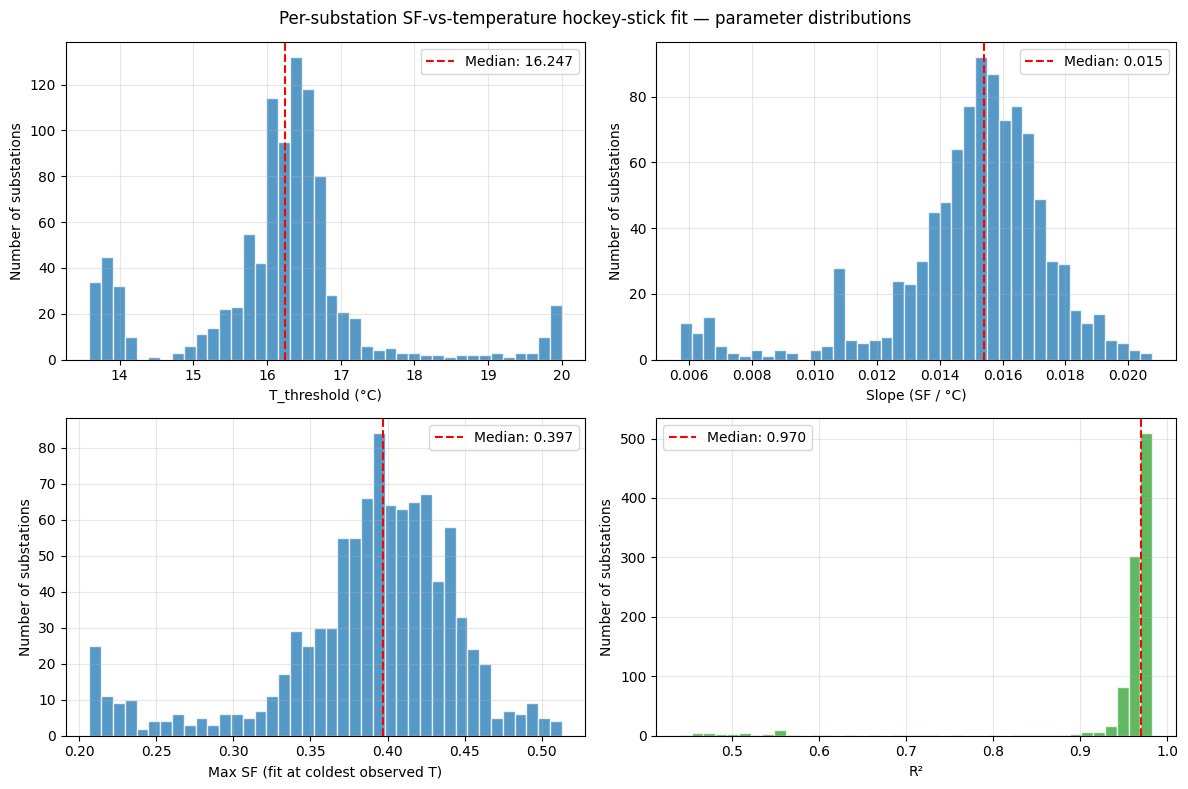

In [ ]:
# Distributions of the per-substation SF-fit parameters
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()
specs = [
    ('T_Threshold', 'T_threshold (°C)', 'tab:blue'),
    ('Slope', 'Slope (SF / °C)', 'tab:blue'),
    ('Max_SF', 'Max SF (fit at coldest observed T)', 'tab:blue'),
    ('R2_Score', 'R²', 'tab:green'),
]
for ax, (col, label, color) in zip(axs, specs):
    ser = sf_coeffs_df[col].dropna()
    lo, hi = np.percentile(ser, [1, 99])
    ax.hist(ser, bins=40, range=(lo, hi), color=color, alpha=0.75, edgecolor='white')
    ax.axvline(ser.median(), color='red', ls='--', lw=1.5, label=f'Median: {ser.median():.3f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Number of substations')
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('Per-substation SF-vs-temperature hockey-stick fit — parameter distributions')
fig.tight_layout()
plt.show()


## Net-Load to Daily Cumulative HDH

### Fit substation net load vs cumulative Heating Degree Hours (HDH)

Parallel to the temperature-based hockey-stick fit above, but the independent
variable is now each day's cumulative Heating Degree Hours (HDH), computed by
summing `max(0, HDH_THRESH - T)` over all sub-daily samples (weighted by
sample duration). Because the zero-clipping hinge is already baked into the
HDH transform itself, a plain 2-parameter line (`base_load + hp_sensitivity *
HDH`) captures the same "flat below threshold / rising above it" shape as the
hockey-stick model, without needing a separate `T_balance` breakpoint.

In [ ]:
# ---------------------------------------------------------------------------
# HDH (Heating Degree Hours) linear model: Load = base_load + hp_sensitivity * HDH
#
# HDH_day = sum over sub-daily samples of max(0, HDH_THRESH - T) * dt_hours
#
# The zero-clipping hinge is already baked into the HDH transform itself
# (every sample above the threshold contributes 0), so a plain 2-parameter
# line captures the same "flat below threshold / rising above it" shape
# without a separate T_balance / breakpoint parameter.
#
# Definitions shared via hp_common.py.
# ---------------------------------------------------------------------------
from hp_common import (
    HDH_THRESH,
    daily_cumulative_hdh,
    daily_hdh_mean_load,
    daily_hdh_energy,
    hdh_linear,
    fit_hdh_linear,
)


In [ ]:
piece_lin_coeff_hdh_sub = []
r2_score_hdh_sub = []

for id in tqdm(substations_df_train.index, desc='Fitting HDH-linear model for substations'):
    try:
        # x, y = daily_hdh_mean_load(
        x, y = daily_hdh_energy(
            substations_df_train.loc[id, 'Temperature'],
            substations_df_train.loc[id, 'Total_Load'],
            hdh_thresh=HDH_THRESH
        )

        if np.sum(x > 0) < MIN_HEATING_DAYS:
            continue

        base_load, hp_sensitivity, r2 = fit_hdh_linear(x, y)

        r2_score_hdh_sub.append((id, r2))
        piece_lin_coeff_hdh_sub.append((id, base_load, hp_sensitivity))

    except Exception:
        pass

Fitting HDH-linear model for substations: 100%|██████████| 1000/1000 [00:07<00:00, 137.76it/s]


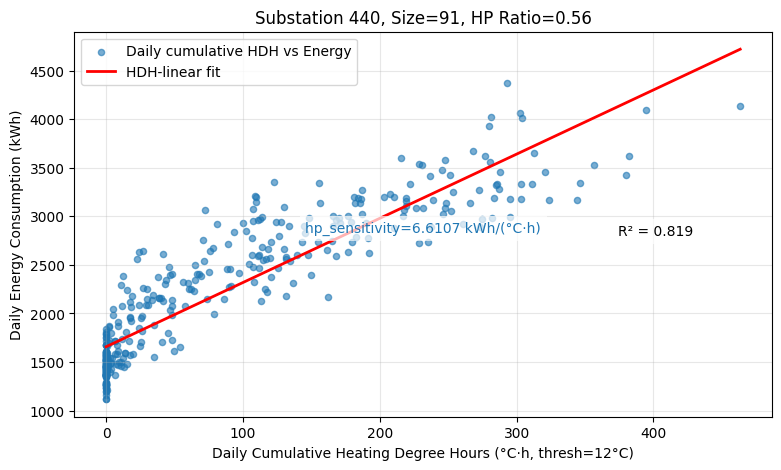

In [ ]:
piece_lin_coeff_hdh_train_df = pd.DataFrame(
    piece_lin_coeff_hdh_sub, columns=['Substation_ID', 'Base_Load', 'HP_Sensitivity']
).set_index('Substation_ID')

r2_score_hdh_train_df = pd.DataFrame(
    r2_score_hdh_sub, columns=['Substation_ID', 'R2_Score']
).set_index('Substation_ID')

# example plot with one substation and the fitted HDH-linear curve
i = 0
example_id_hdh = int(piece_lin_coeff_hdh_train_df.index.values[i])

# x, y = daily_hdh_mean_load(
x, y = daily_hdh_energy(
    substations_df_train.loc[example_id_hdh, 'Temperature'],
    substations_df_train.loc[example_id_hdh, 'Total_Load'],
    hdh_thresh=HDH_THRESH
)

base_load, hp_sensitivity, r2 = fit_hdh_linear(x, y)

x_hat = np.linspace(x.min(), x.max(), 100)
y_hat = hdh_linear(x_hat, base_load, hp_sensitivity)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='Daily cumulative HDH vs Energy')
plt.plot(x_hat, y_hat, color='red', lw=2, label='HDH-linear fit')
plt.xlabel(f'Daily Cumulative Heating Degree Hours (\u00b0C\u00b7h, thresh={HDH_THRESH:.0f}\u00b0C)')
plt.ylabel('Daily Energy Consumption (kWh)')
plt.title(f"Substation {example_id_hdh}, Size={substations_df_train.loc[example_id_hdh, 'size']}, "
          f"HP Ratio={substations_df_train.loc[example_id_hdh, 'HP_ratio']:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.text(0.78, 0.5, f'R\u00b2 = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.text(x.max() * 0.5, y_hat.max() * 0.6, f'hp_sensitivity={hp_sensitivity:.4f} kWh/(\u00b0C\u00b7h)',
         color='tab:blue', fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()

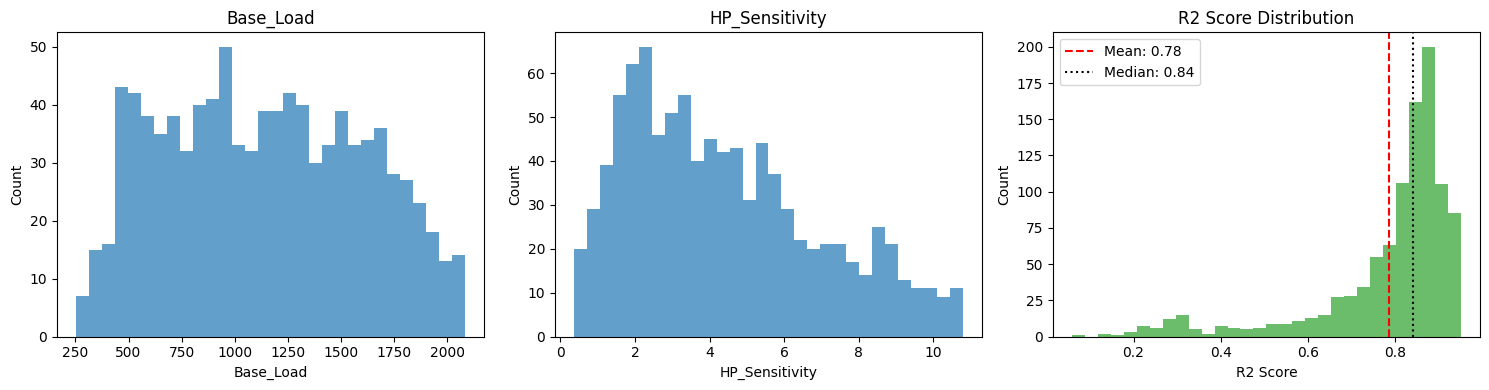

In [ ]:
cols_hdh = ['Base_Load', 'HP_Sensitivity']

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs = axs.flatten()

for i, col in enumerate(cols_hdh):
    ser = piece_lin_coeff_hdh_train_df[col].dropna()
    ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]  # remove outliers for better visualization
    axs[i].hist(ser, bins=30, color='tab:blue', alpha=0.7)
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Count')

r2_scores_hdh = r2_score_hdh_train_df['R2_Score'].dropna()
ax = axs[2]
ax.hist(r2_scores_hdh, bins=30, color='tab:green', alpha=0.7)
ax.set_title('R2 Score Distribution')
ax.set_xlabel('R2 Score')
ax.set_ylabel('Count')
ax.axvline(r2_scores_hdh.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {r2_scores_hdh.mean():.2f}')
ax.axvline(r2_scores_hdh.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {r2_scores_hdh.median():.2f}')
ax.legend()
fig.tight_layout()
plt.show()

R² for cumulative HDD sensitivity vs Simultaneous HP Peak: 0.622
33.341, -8.125
R² for cumulative HDD sensitivity per peak vs Simultaneous HP Peak: 0.037


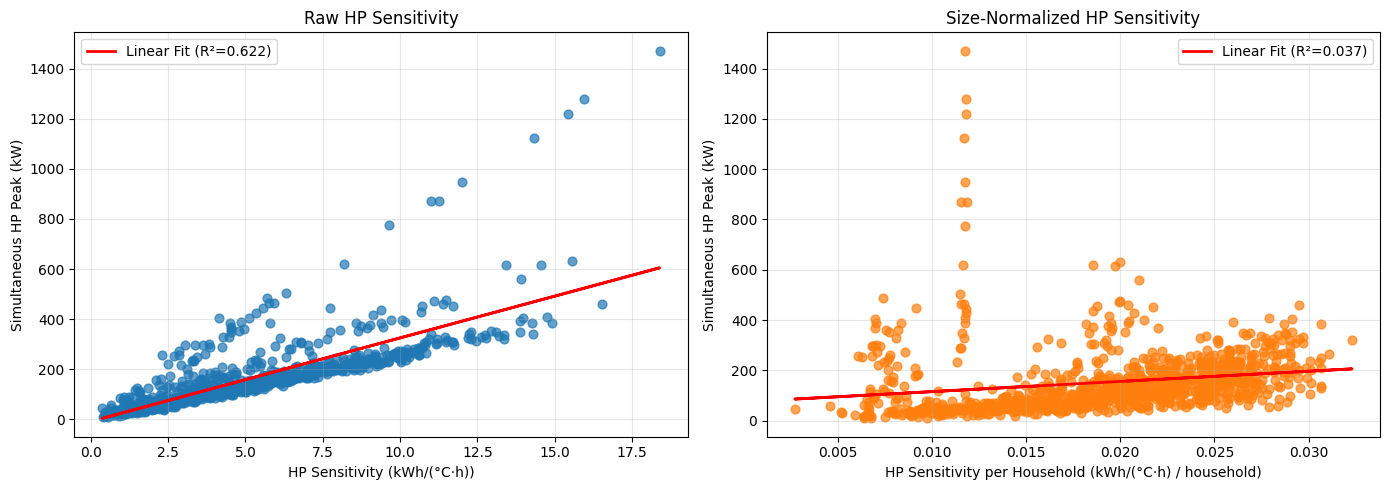

In [ ]:
substations_df_train['Simult_HP_Peak'] = [substations_df_train.iloc[i]['HP_Load'].max() if hp_ratio > 0 else 0 for i, hp_ratio in enumerate(substations_df_train['HP_ratio'])]
data = piece_lin_coeff_hdh_train_df[['HP_Sensitivity']].join(substations_df_train[['Simult_HP_Peak', 'size']])
peak_load_train = substations_df_train['Total_Load'].apply(lambda s: s.max())
data['Peak_Load'] = peak_load_train
data['HP_Sensitivity_per_peak'] = data['HP_Sensitivity'] / data['Peak_Load']

lin = LinearRegression()
lin.fit(data[['HP_Sensitivity']], data['Simult_HP_Peak'])
r2 = lin.score(data[['HP_Sensitivity']], data['Simult_HP_Peak'])
print(f"R² for cumulative HDD sensitivity vs Simultaneous HP Peak: {r2:.3f}")
print(f"{lin.coef_[0]:.3f}, {lin.intercept_:.3f}")

lin_norm = LinearRegression()
lin_norm.fit(data[['HP_Sensitivity_per_peak']], data['Simult_HP_Peak'])
r2_norm = lin_norm.score(data[['HP_Sensitivity_per_peak']], data['Simult_HP_Peak'])
print(f"R² for cumulative HDD sensitivity per peak vs Simultaneous HP Peak: {r2_norm:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].scatter(data['HP_Sensitivity'], data['Simult_HP_Peak'], alpha=0.7, s=40)
axs[0].plot(data['HP_Sensitivity'], lin.predict(data[['HP_Sensitivity']]), color='red', linewidth=2, label=f'Linear Fit (R²={r2:.3f})')
axs[0].set_xlabel('HP Sensitivity (kWh/(\u00b0C\u00b7h))')
axs[0].set_ylabel('Simultaneous HP Peak (kW)')
axs[0].set_title('Raw HP Sensitivity')
axs[0].grid(alpha=0.3)
axs[0].legend()

axs[1].scatter(data['HP_Sensitivity_per_peak'], data['Simult_HP_Peak'], alpha=0.7, s=40, color='tab:orange')
axs[1].plot(data['HP_Sensitivity_per_peak'], lin_norm.predict(data[['HP_Sensitivity_per_peak']]), color='red', linewidth=2, label=f'Linear Fit (R²={r2_norm:.3f})')
axs[1].set_xlabel('HP Sensitivity per Household (kWh/(\u00b0C\u00b7h) / household)')
axs[1].set_ylabel('Simultaneous HP Peak (kW)')
axs[1].set_title('Size-Normalized HP Sensitivity')
axs[1].grid(alpha=0.3)
axs[1].legend()

fig.tight_layout()
plt.show()

R² for HP_Sensitivity vs Non-Simultaneous HP Peak: 0.851
50.263, -11.498


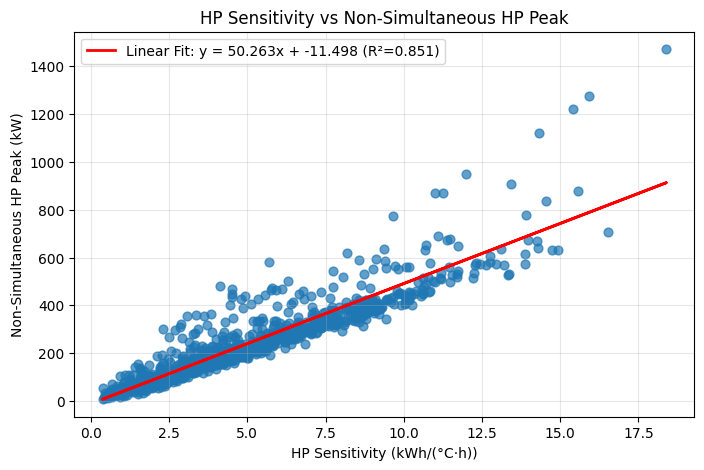

In [ ]:
data = piece_lin_coeff_hdh_train_df[['HP_Sensitivity']].join(substations_df_train[['HP_Peak', 'size']])
peak_load_train = substations_df_train['Total_Load'].apply(lambda s: s.max())
data['Peak_Load'] = peak_load_train
data['HP_Sensitivity_per_peak'] = data['HP_Sensitivity'] / data['Peak_Load']

nonSimDeltaFit_hdh = LinearRegression()
nonSimDeltaFit_hdh.fit(data[['HP_Sensitivity']], data['HP_Peak'])
r2 = nonSimDeltaFit_hdh.score(data[['HP_Sensitivity']], data['HP_Peak'])
print(f"R² for HP_Sensitivity vs Non-Simultaneous HP Peak: {r2:.3f}")
print(f"{nonSimDeltaFit_hdh.coef_[0]:.3f}, {nonSimDeltaFit_hdh.intercept_:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(data['HP_Sensitivity'], data['HP_Peak'], alpha=0.7, s=40)
plt.plot(data['HP_Sensitivity'], nonSimDeltaFit_hdh.predict(data[['HP_Sensitivity']]), color='red', linewidth=2, label=f'Linear Fit: y = {nonSimDeltaFit_hdh.coef_[0]:.3f}x + {nonSimDeltaFit_hdh.intercept_:.3f} (R²={r2:.3f})')
plt.xlabel('HP Sensitivity (kWh/(°C·h))')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous HP Peak')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
piece_lin_coeff_hdh_test = []
r2_score_hdh_test = []

for id in tqdm(substations_df_test.index, desc='Fitting HDH-linear model for substations (test)'):
    try:
        x, y = daily_hdh_energy(
            substations_df_test.loc[id, 'Temperature'],
            substations_df_test.loc[id, 'Total_Load'],
            hdh_thresh=HDH_THRESH
        )

        if np.sum(x > 0) < MIN_HEATING_DAYS:
            continue

        base_load, hp_sensitivity, r2 = fit_hdh_linear(x, y)

        r2_score_hdh_test.append((id, r2))
        piece_lin_coeff_hdh_test.append((id, base_load, hp_sensitivity))

    except Exception:
        pass

Fitting HDH-linear model for substations (test): 100%|██████████| 1000/1000 [00:07<00:00, 142.84it/s]


In [ ]:
piece_lin_coeff_hdh_test_df = pd.DataFrame(piece_lin_coeff_hdh_test, columns=['Substation_ID', 'Base_Load', 'HP_Sensitivity'])
piece_lin_coeff_hdh_test_df.set_index('Substation_ID', inplace=True)

r2_score_hdh_test_df = pd.DataFrame(r2_score_hdh_test, columns=['Substation_ID', 'R2_Score'])
r2_score_hdh_test_df.set_index('Substation_ID', inplace=True)

In [ ]:
piece_lin_coeff_hdh_df = pd.concat([piece_lin_coeff_hdh_train_df, piece_lin_coeff_hdh_test_df])
r2_score_hdh_df = pd.concat([r2_score_hdh_train_df, r2_score_hdh_test_df])

R² for HP_Sensitivity vs Non-Simultaneous HP Peak on test set: 0.861


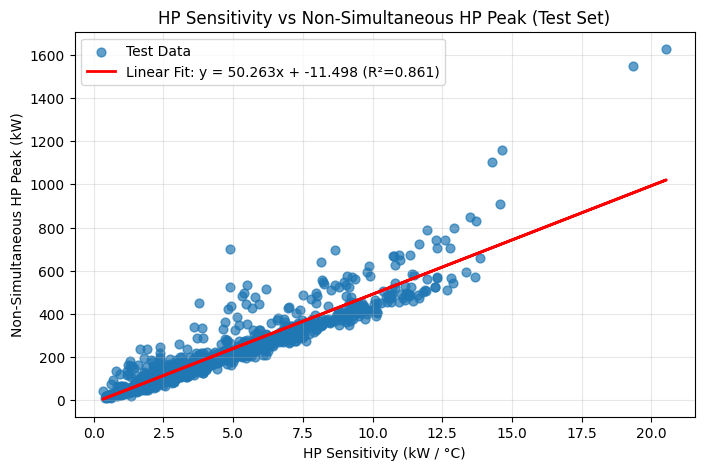

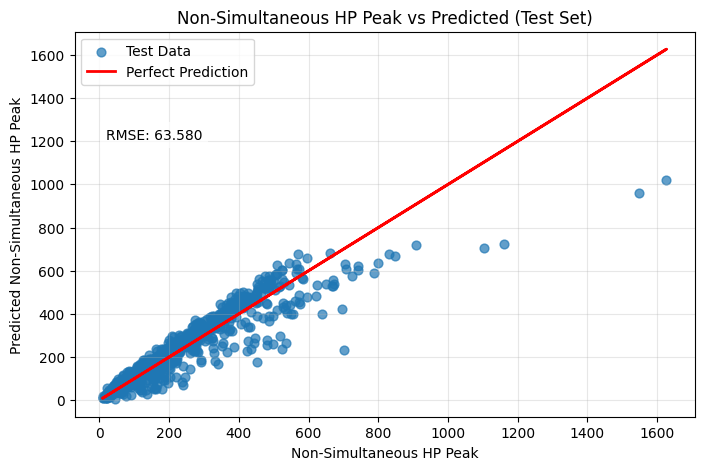

In [ ]:
data_test = piece_lin_coeff_hdh_test_df[['HP_Sensitivity']].join(substations_df_test[['HP_Peak']], how='inner')

nonSimTestPred = nonSimDeltaFit_hdh.predict(data_test[['HP_Sensitivity']])
r2_nonSimTest = r2_score(data_test['HP_Peak'], nonSimTestPred)
print(f"R² for HP_Sensitivity vs Non-Simultaneous HP Peak on test set: {r2_nonSimTest:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(data_test['HP_Sensitivity'], data_test['HP_Peak'], alpha=0.7, s=40, label='Test Data')
plt.plot(data_test['HP_Sensitivity'], nonSimTestPred, color='red', linewidth=2, label=f'Linear Fit: y = {nonSimDeltaFit_hdh.coef_[0]:.3f}x + {nonSimDeltaFit_hdh.intercept_:.3f} (R²={r2_nonSimTest:.3f})')
plt.xlabel('HP Sensitivity (kW / °C)')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous HP Peak (Test Set)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(data_test['HP_Peak'], nonSimTestPred, alpha=0.7, s=40, label='Test Data')
plt.plot(data_test['HP_Peak'], data_test['HP_Peak'], color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel('Non-Simultaneous HP Peak')
plt.ylabel('Predicted Non-Simultaneous HP Peak')
plt.title('Non-Simultaneous HP Peak vs Predicted (Test Set)')
plt.text(0.05, 0.75, f'RMSE: {np.sqrt(mean_squared_error(data_test["HP_Peak"], nonSimTestPred)):.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

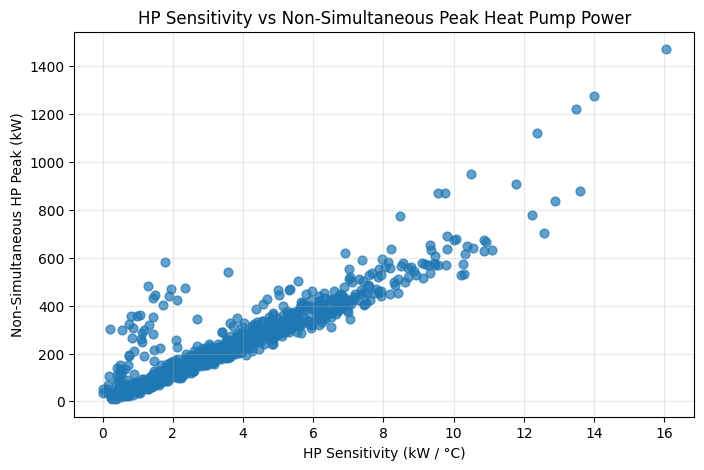

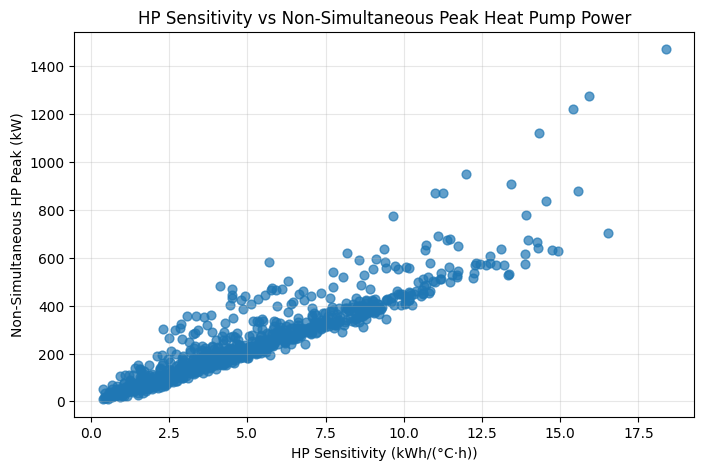

In [ ]:
data_plot = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train['HP_Peak'], how='inner')

plt.figure(figsize=(8, 5))
plt.scatter(data_plot['HP_Sensitivity'], data_plot['HP_Peak'], alpha=0.7, s=40)
plt.xlabel('HP Sensitivity (kW / °C)')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous Peak Heat Pump Power')
plt.grid(alpha=0.3)
plt.show()

data_plot = piece_lin_coeff_hdh_train_df[['HP_Sensitivity']].join(substations_df_train['HP_Peak'], how='inner')

plt.figure(figsize=(8, 5))
plt.scatter(data_plot['HP_Sensitivity'], data_plot['HP_Peak'], alpha=0.7, s=40)
plt.xlabel('HP Sensitivity (kWh/(\u00b0C\u00b7h))')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous Peak Heat Pump Power')
plt.grid(alpha=0.3)
plt.show()

Training R² (weighted): 0.865
Test R²: 0.861
Test RMSE: 63.543 kW
Test MAPE: 17.88%
Linear model: HP_Peak = 51.297 * HP_Sensitivity + -20.208


c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


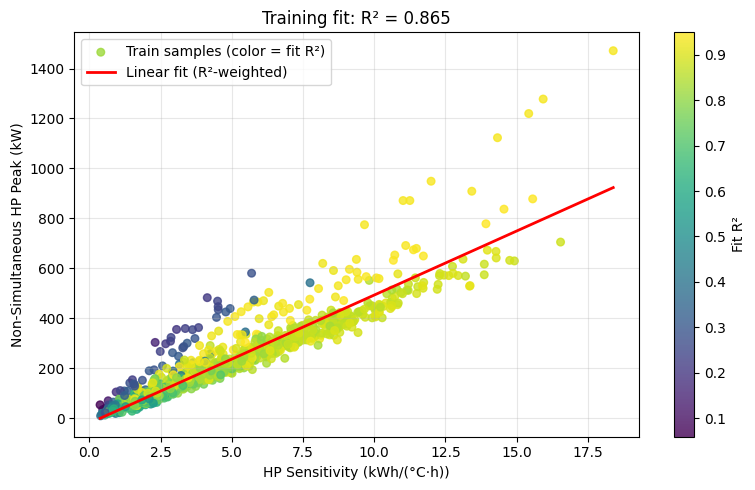

c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


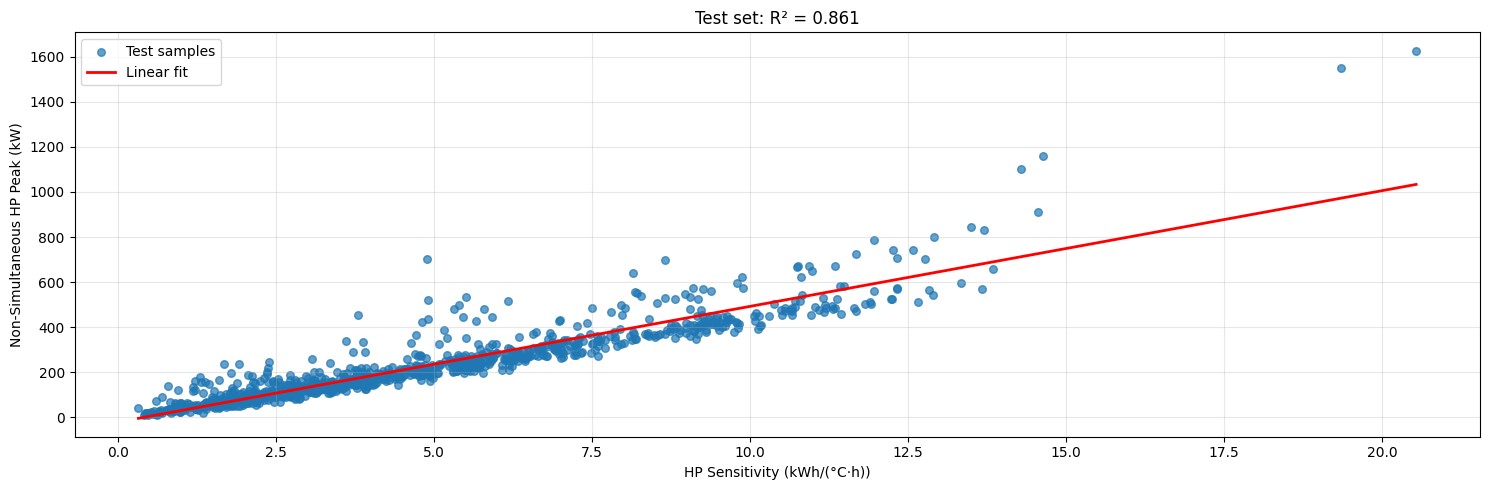

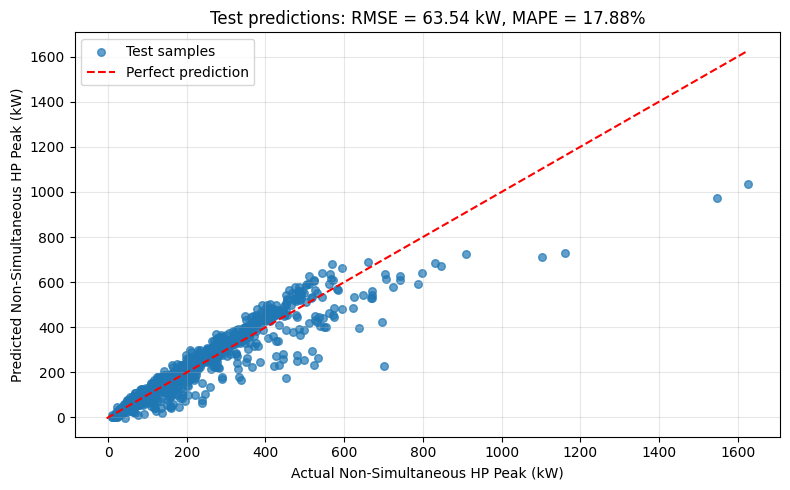

In [ ]:
train_data = piece_lin_coeff_hdh_train_df[['HP_Sensitivity']].join(substations_df_train['HP_Peak'], how='inner').join(r2_score_hdh_train_df, how='inner').dropna()

# FIX: weight samples by fit quality (R²) instead of using a hard
# accept/reject threshold -- substations with a noisy/uncertain
# HDH-linear fit contribute less to the regression rather than being
# discarded outright.
sample_weight_train = train_data['R2_Score'].clip(0, 1)

modelLinSlope_hdh = LinearRegression()
modelLinSlope_hdh.fit(train_data[['HP_Sensitivity']], train_data['HP_Peak'], sample_weight=sample_weight_train)

test_data = piece_lin_coeff_hdh_test_df[['HP_Sensitivity']].join(substations_df_test['HP_Peak'], how='inner').dropna()
test_data['Predicted_HP_Peak'] = modelLinSlope_hdh.predict(test_data[['HP_Sensitivity']])

r2_train = modelLinSlope_hdh.score(train_data[['HP_Sensitivity']], train_data['HP_Peak'], sample_weight=sample_weight_train)
r2_test = r2_score(test_data['HP_Peak'], test_data['Predicted_HP_Peak'])
rmse_test = root_mean_squared_error(test_data['HP_Peak'], test_data['Predicted_HP_Peak'])
small_y_threshold = 10.0
mask = test_data['HP_Peak'].abs() > small_y_threshold
mape_test = mean_absolute_percentage_error(
    test_data.loc[mask, 'HP_Peak'],
    test_data.loc[mask, 'Predicted_HP_Peak']
) * 100

print(f"Training R² (weighted): {r2_train:.3f}")
print(f"Test R²: {r2_test:.3f}")
print(f"Test RMSE: {rmse_test:.3f} kW")
print(f"Test MAPE: {mape_test:.2f}%")
print(f"Linear model: HP_Peak = {modelLinSlope_hdh.coef_[0]:.3f} * HP_Sensitivity + {modelLinSlope_hdh.intercept_:.3f}")

# Plot training set, colored by fit R² (the sample weight)
fig_train, ax_train = plt.subplots(figsize=(8, 5))
sc = ax_train.scatter(train_data['HP_Sensitivity'], train_data['HP_Peak'], c=sample_weight_train, cmap='viridis', alpha=0.8, s=30, label='Train samples (color = fit R²)')
x_line = np.linspace(train_data['HP_Sensitivity'].min(), train_data['HP_Sensitivity'].max(), 100)
ax_train.plot(x_line, modelLinSlope_hdh.predict(x_line.reshape(-1, 1)), color='red', linewidth=2, label='Linear fit (R²-weighted)')
ax_train.set_xlabel('HP Sensitivity (kWh/(\u00b0C\u00b7h))')
ax_train.set_ylabel('Non-Simultaneous HP Peak (kW)')
ax_train.set_title(f'Training fit: R² = {r2_train:.3f}')
ax_train.grid(alpha=0.3)
ax_train.legend()
fig_train.colorbar(sc, ax=ax_train, label='Fit R²')
fig_train.tight_layout()
plt.show()

fig, axs = plt.subplots(figsize=(15, 5))
axs.scatter(test_data['HP_Sensitivity'], test_data['HP_Peak'], alpha=0.7, s=30, label='Test samples')
x_line = np.linspace(test_data['HP_Sensitivity'].min(), test_data['HP_Sensitivity'].max(), 100)
axs.plot(x_line, modelLinSlope_hdh.predict(x_line.reshape(-1, 1)), color='red', linewidth=2, label='Linear fit')
axs.set_xlabel('HP Sensitivity (kWh/(\u00b0C\u00b7h))')
axs.set_ylabel('Non-Simultaneous HP Peak (kW)')
axs.set_title(f'Test set: R² = {r2_test:.3f}')
axs.grid(alpha=0.3)
axs.legend()
fig.tight_layout()
plt.show()

# Plot test set predictions vs actual
min_val = min(test_data['HP_Peak'].min(), test_data['Predicted_HP_Peak'].min())
max_val = max(test_data['HP_Peak'].max(), test_data['Predicted_HP_Peak'].max())

fig_test, ax_test = plt.subplots(figsize=(8, 5))
ax_test.scatter(test_data['HP_Peak'], test_data['Predicted_HP_Peak'], alpha=0.7, s=30, label='Test samples')
ax_test.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
ax_test.set_xlabel('Actual Non-Simultaneous HP Peak (kW)')
ax_test.set_ylabel('Predicted Non-Simultaneous HP Peak (kW)')
ax_test.set_title(f'Test predictions: RMSE = {rmse_test:.2f} kW, MAPE = {mape_test:.2f}%')
ax_test.grid(alpha=0.3)
ax_test.legend()
fig_test.tight_layout()
plt.show()

### Extension: Simultaneity Factor from the extended HDH fit

Same exercise for the cumulative-HDH fit, which predicts daily HP *energy*.
The daily-energy prediction is capped at `HP_Peak * 24 h` (every heat pump at
full power for a full day), giving
`SF(HDH) = hp_sensitivity * HDH / (HP_Peak * 24)`.

**Left:** the cumulative HDH at which the *extended* fit reaches SF = 1 (the
x-axis is kept in HDH units, not converted to a temperature). **Right:** the
maximum SF the *non-extended* HDH fit attains within its observed HDH range.

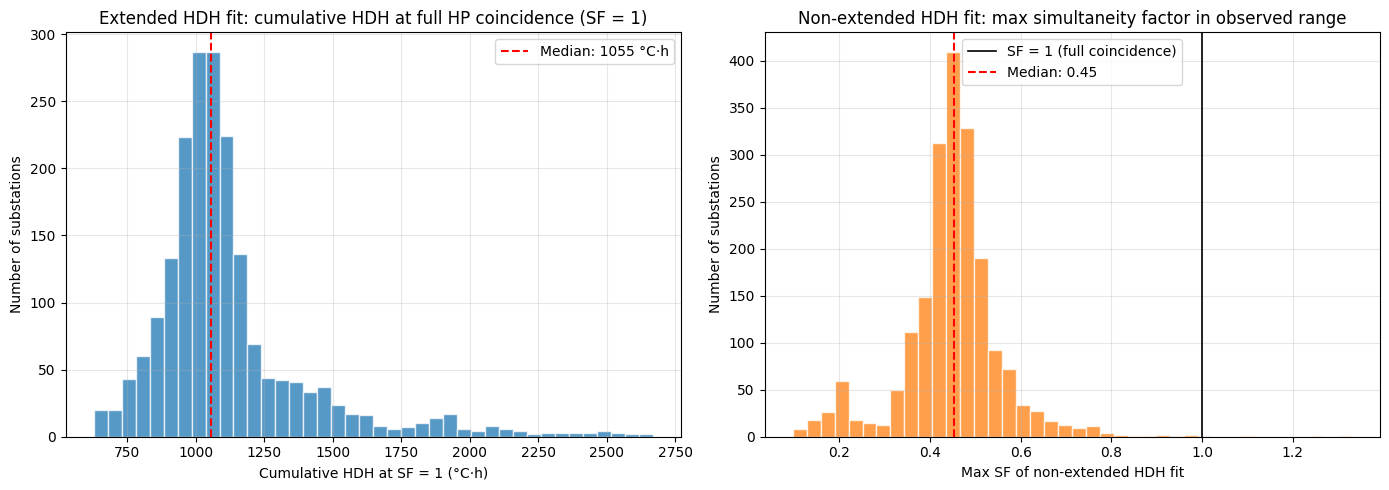

Substations analysed (HDH): 2000
SF=1 cumulative HDH -- median 1055 °C·h
Max SF of non-extended HDH fit -- median 0.45; reaches SF>=1 within observed range for 0.1% of substations


In [ ]:
# ---------------------------------------------------------------------------
# HDH EXTENSION -- simultaneity factor (SF) analysis (x-axis kept in HDH units)
#
# The HDH fit Energy = base_load + hp_sensitivity * HDH predicts daily HP
# energy. The largest physically possible daily HP energy is the installed
# capacity running flat out for 24 h: HP_Peak * 24 (kWh). The modelled
# simultaneity factor is therefore
#
#     SF(HDH) = hp_sensitivity * HDH / (HP_Peak * 24)             (0 -> 1)
#
# SF = 1 (every HP at full power for a full day) is reached at the cumulative
# heating-degree-hour value
#
#     HDH_SF1 = HP_Peak * 24 / hp_sensitivity     [°C·h]
#
# The non-extended fit only reaches SF(HDH_max_observed): the largest SF inside
# the observed range of daily HDH.
# ---------------------------------------------------------------------------
sf1_hdh = []                    # cumulative HDH where SF reaches 1 (extended)
max_sf_non_extended_hdh = []    # max SF within observed HDH range  (non-extended)

for sid, row in piece_lin_coeff_hdh_df.iterrows():
    if sid not in substations_df.index:
        continue
    hp_sens = row['HP_Sensitivity']                 # kWh per (°C·h)
    hp_peak = substations_df.loc[sid, 'HP_Peak']
    if not (hp_sens > 0 and hp_peak > 0):
        continue

    energy_cap = hp_peak * 24.0                     # max daily HP energy (kWh)

    try:
        hdh_series = daily_cumulative_hdh(
            substations_df.loc[sid, 'Temperature'], hdh_thresh=HDH_THRESH)
        hdh_max_obs = float(hdh_series.max())
    except Exception:
        continue
    if not np.isfinite(hdh_max_obs):
        continue

    sf1_hdh.append(energy_cap / hp_sens)
    max_sf_non_extended_hdh.append(hp_sens * hdh_max_obs / energy_cap)

sf1_hdh = np.array(sf1_hdh)
max_sf_non_extended_hdh = np.array(max_sf_non_extended_hdh)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: cumulative HDH at which the extended fit reaches SF = 1
lo, hi = np.percentile(sf1_hdh, [1, 99])
axs[0].hist(sf1_hdh, bins=40, range=(lo, hi),
            color='tab:blue', alpha=0.75, edgecolor='white')
axs[0].axvline(np.median(sf1_hdh), color='red', ls='--', lw=1.5,
               label=f'Median: {np.median(sf1_hdh):.0f} °C·h')
axs[0].set_xlabel('Cumulative HDH at SF = 1 (°C·h)')
axs[0].set_ylabel('Number of substations')
axs[0].set_title('Extended HDH fit: cumulative HDH at full HP coincidence (SF = 1)')
axs[0].grid(alpha=0.3)
axs[0].legend()

# Plot B: maximum SF the non-extended HDH fit reaches inside the observed range
axs[1].hist(max_sf_non_extended_hdh, bins=40, color='tab:orange', alpha=0.75, edgecolor='white')
axs[1].axvline(1.0, color='black', lw=1.2, label='SF = 1 (full coincidence)')
axs[1].axvline(np.median(max_sf_non_extended_hdh), color='red', ls='--', lw=1.5,
               label=f'Median: {np.median(max_sf_non_extended_hdh):.2f}')
axs[1].set_xlabel('Max SF of non-extended HDH fit')
axs[1].set_ylabel('Number of substations')
axs[1].set_title('Non-extended HDH fit: max simultaneity factor in observed range')
axs[1].grid(alpha=0.3)
axs[1].legend()

fig.tight_layout()
plt.show()

frac_reach = np.mean(max_sf_non_extended_hdh >= 1.0) * 100
print(f'Substations analysed (HDH): {len(sf1_hdh)}')
print(f'SF=1 cumulative HDH -- median {np.median(sf1_hdh):.0f} °C·h')
print(f'Max SF of non-extended HDH fit -- median {np.median(max_sf_non_extended_hdh):.2f}; '
      f'reaches SF>=1 within observed range for {frac_reach:.1f}% of substations')


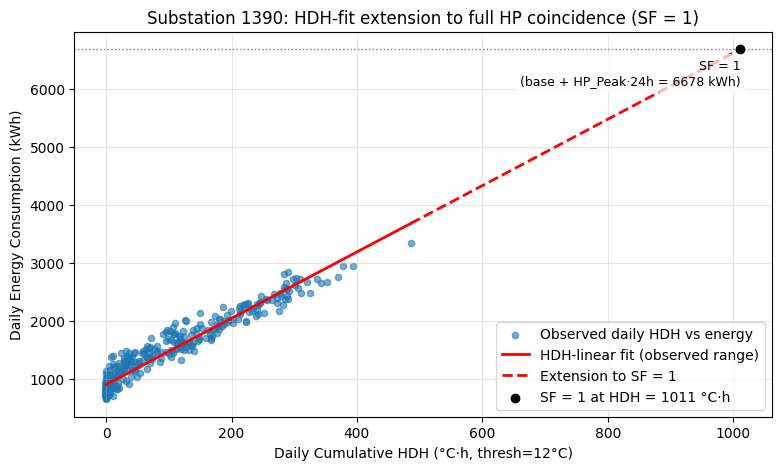

In [ ]:
# ---------------------------------------------------------------------------
# Example of the HDH extension for one substation:
#   scatter : observed daily cumulative-HDH / daily-energy points
#   solid   : HDH-linear fit over the observed HDH range
#   dashed  : extrapolation (extension) up to the cumulative HDH where the HP
#             energy reaches HP_Peak * 24 h (SF = 1)
# Example substation auto-picked the same way as the hockey-stick example.
# ---------------------------------------------------------------------------
def plot_hdh_extension_example(sid):
    x, y = daily_hdh_energy(
        substations_df.loc[sid, 'Temperature'],
        substations_df.loc[sid, 'Total_Load'],
        hdh_thresh=HDH_THRESH,
    )
    base_load = piece_lin_coeff_hdh_df.loc[sid, 'Base_Load']
    hp_sens   = piece_lin_coeff_hdh_df.loc[sid, 'HP_Sensitivity']
    hp_peak   = substations_df.loc[sid, 'HP_Peak']

    energy_cap = hp_peak * 24.0                 # max daily HP energy (kWh)
    hdh_sf1 = energy_cap / hp_sens              # cumulative HDH at SF = 1
    energy_sf1 = base_load + energy_cap         # daily energy at SF = 1

    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = hdh_linear(x_fit, base_load, hp_sens)
    hot_end = max(hdh_sf1, x.max())

    plt.figure(figsize=(9, 5))
    plt.scatter(x, y, s=20, alpha=0.6, label='Observed daily HDH vs energy')
    plt.plot(x_fit, y_fit, color='red', lw=2, label='HDH-linear fit (observed range)')
    if hot_end > x.max():
        x_ext = np.linspace(x.max(), hot_end, 200)
        y_ext = hdh_linear(x_ext, base_load, hp_sens)
        plt.plot(x_ext, y_ext, color='red', lw=2, ls='--', label='Extension to SF = 1')
    plt.axhline(energy_sf1, color='gray', ls=':', lw=1)
    plt.scatter([hdh_sf1], [energy_sf1], color='black', zorder=5,
                label=f'SF = 1 at HDH = {hdh_sf1:.0f} °C·h')
    plt.annotate(f'SF = 1\n(base + HP_Peak·24h = {energy_sf1:.0f} kWh)',
                 xy=(hdh_sf1, energy_sf1),
                 xytext=(hdh_sf1, energy_sf1 - 0.10 * (energy_sf1 - y.min() + 1)),
                 fontsize=9, ha='right',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    plt.xlabel(f'Daily Cumulative HDH (°C·h, thresh={HDH_THRESH:.0f}°C)')
    plt.ylabel('Daily Energy Consumption (kWh)')
    plt.title(f'Substation {sid}: HDH-fit extension to full HP coincidence (SF = 1)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# --- pick an illustrative substation (good fit, SF=1 just beyond the data) ---
_candh = (piece_lin_coeff_hdh_train_df
          .join(r2_score_hdh_train_df, how='inner')
          .join(substations_df[['HP_Peak']], how='inner'))
_candh = _candh[(_candh['HP_Sensitivity'] > 0) & (_candh['HP_Peak'] > 0) & (_candh['R2_Score'] > 0.5)]
_candh = _candh.sort_values('R2_Score', ascending=False).head(60)

_best_id_h, _best_key_h = None, -np.inf
for _sid, _r in _candh.iterrows():
    try:
        _hdh = daily_cumulative_hdh(substations_df.loc[_sid, 'Temperature'], hdh_thresh=HDH_THRESH)
        _hdh_max = float(_hdh.max())
    except Exception:
        continue
    if not np.isfinite(_hdh_max) or _hdh_max <= 0:
        continue
    _sf_max = _r['HP_Sensitivity'] * _hdh_max / (_r['HP_Peak'] * 24.0)
    _key = _sf_max if _sf_max <= 1.0 else (2.0 - _sf_max)
    if _key > _best_key_h:
        _best_key_h, _best_id_h = _key, _sid

example_ext_hdh_id = int(_best_id_h) if _best_id_h is not None else int(piece_lin_coeff_hdh_train_df.index[0])
plot_hdh_extension_example(example_ext_hdh_id)


Design SF=1 cumulative HDH (median over train): 1054 °C·h


c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


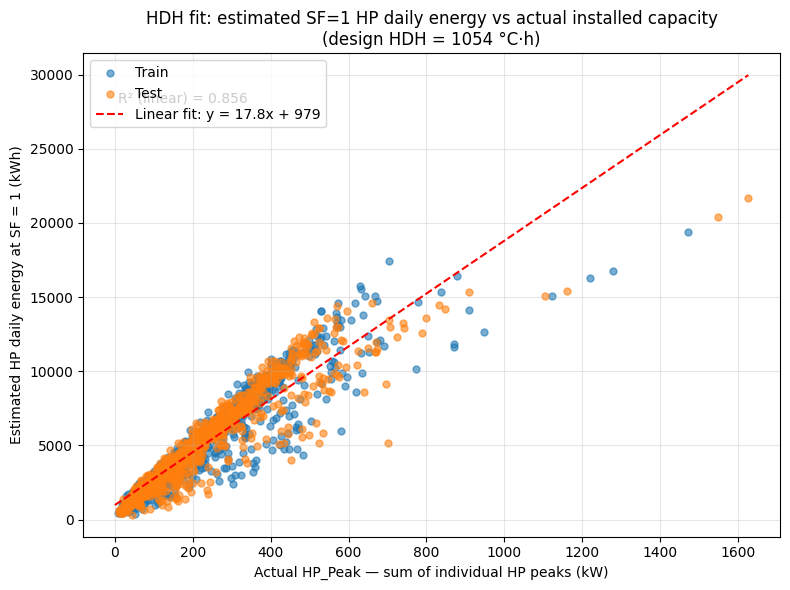

In [ ]:
# ---------------------------------------------------------------------------
# Estimated HP daily ENERGY at SF = 1 vs actual installed capacity (HP_Peak)
#
# The SF=1 reference is the MEDIAN of the per-substation SF=1 cumulative-HDH
# values on the TRAINING set (HDH_SF1 = HP_Peak*24 / hp_sensitivity). Every
# substation's fitted function is evaluated at this shared design HDH to
# estimate the fully-coincident (SF=1) daily HP energy:
#
#     est_HP_energy = hp_sensitivity * HDH_design      [kWh]
#
# Plotted against actual HP_Peak (kW). Units differ (energy vs power), so this
# is a correlation check rather than a y=x identity; a linear fit + R² summarise it.
# ---------------------------------------------------------------------------
# Design HDH = median SF=1 cumulative HDH over the training substations
_hd = piece_lin_coeff_hdh_train_df.join(substations_df[['HP_Peak']], how='inner')
_hd = _hd[(_hd['HP_Sensitivity'] > 0) & (_hd['HP_Peak'] > 0)]
_hd_hdh_sf1 = _hd['HP_Peak'] * 24.0 / _hd['HP_Sensitivity']
HDH_design = float(np.median(_hd_hdh_sf1))
print(f'Design SF=1 cumulative HDH (median over train): {HDH_design:.0f} °C·h')

est_h = piece_lin_coeff_hdh_df.join(substations_df[['HP_Peak']], how='inner')
est_h = est_h[(est_h['HP_Sensitivity'] > 0) & (est_h['HP_Peak'] > 0)].copy()
est_h['Est_HP_Energy_SF1'] = est_h['HP_Sensitivity'] * HDH_design

train_ids = est_h.index.intersection(substations_df_train.index)
test_ids = est_h.index.intersection(substations_df_test.index)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(est_h.loc[train_ids, 'HP_Peak'], est_h.loc[train_ids, 'Est_HP_Energy_SF1'],
           s=25, alpha=0.6, color='tab:blue', label='Train')
ax.scatter(est_h.loc[test_ids, 'HP_Peak'], est_h.loc[test_ids, 'Est_HP_Energy_SF1'],
           s=25, alpha=0.6, color='tab:orange', label='Test')

# linear fit over all substations to summarise the correlation
_lin = LinearRegression().fit(est_h[['HP_Peak']], est_h['Est_HP_Energy_SF1'])
xs = np.linspace(0, float(est_h['HP_Peak'].max()), 100)
ax.plot(xs, _lin.predict(xs.reshape(-1, 1)), 'r--',
        label=f'Linear fit: y = {_lin.coef_[0]:.1f}x + {_lin.intercept_:.0f}')
r2_est_h = _lin.score(est_h[['HP_Peak']], est_h['Est_HP_Energy_SF1'])
ax.set_xlabel('Actual HP_Peak — sum of individual HP peaks (kW)')
ax.set_ylabel('Estimated HP daily energy at SF = 1 (kWh)')
ax.set_title(f'HDH fit: estimated SF=1 HP daily energy vs actual installed capacity\n(design HDH = {HDH_design:.0f} °C·h)')
ax.grid(alpha=0.3)
ax.legend()
ax.text(0.05, 0.92, f'R² (linear) = {r2_est_h:.3f}', transform=ax.transAxes, va='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
fig.tight_layout()
plt.show()


### Fit piecewise function to time-of-day indexed data

In [ ]:
# FIX: previously fit 24 separate unconstrained 2-segment pwlf models per
# substation (one per hour), producing 120 often-noisy coefficients and
# visibly degenerate fits (S1 < -1000 outliers, see the diagnostic below).
# Instead, pool hours into 4 broader time-of-day windows and fit the same
# constrained hockey-stick model used for the daily fit above.
from hp_common import hour_groups   # shared time-of-day windows

piece_lin_coeff_hdh_hourly = {}
r2_score_hdh_hourly = {}

for id in tqdm(substations_df_train.index, desc='Fitting HDH Linear models by time-of-day window'):
    try:
        temp_h = substations_df_train.loc[id, 'Temperature'].resample('h').mean()
        load_h = substations_df_train.loc[id, 'Total_Load'].resample('h').mean()

        sm_data = pd.DataFrame({'Temperature': temp_h, 'Total_Load': load_h}).dropna()

        piece_lin_coeff_hdh_hourly[id] = {}
        r2_score_hdh_hourly[id] = {}

        for group_name, hours in hour_groups.items():
            group_data = sm_data[sm_data.index.hour.isin(hours)]

            x, y = daily_hdh_energy(
                group_data['Temperature'],
                group_data['Total_Load'],
                hdh_thresh=HDH_THRESH
            )

            if len(x) < MIN_HEATING_DAYS:
                continue

            try:
                base_load, hp_sensitivity, r2 = fit_hdh_linear(x, y)
            except Exception:
                continue

            piece_lin_coeff_hdh_hourly[id][f'{group_name}_BaseLoad'] = base_load
            piece_lin_coeff_hdh_hourly[id][f'{group_name}_Sensitivity'] = hp_sensitivity
            r2_score_hdh_hourly[id][group_name] = r2

    except Exception:
        pass

Fitting HDH Linear models by time-of-day window: 100%|██████████| 1000/1000 [00:24<00:00, 41.62it/s]


In [ ]:
piece_lin_coeff_hdh_hourly_df = pd.DataFrame.from_dict(piece_lin_coeff_hdh_hourly, orient='index')
piece_lin_coeff_hdh_hourly_df.index.name = 'Substation_ID'

r2_score_hdh_hourly_df = pd.DataFrame.from_dict(r2_score_hdh_hourly, orient='index')
r2_score_hdh_hourly_df.index.name = 'Substation_ID'

sensitivity_cols = [c for c in piece_lin_coeff_hdh_hourly_df.columns if c.endswith('_Sensitivity')]

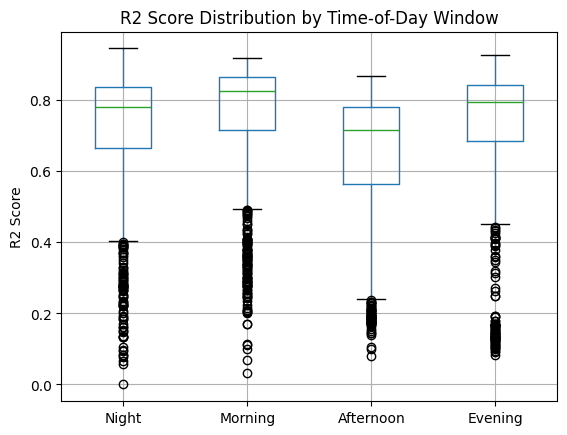

In [ ]:
r2_score_hdh_hourly_df.boxplot()
plt.title('R2 Score Distribution by Time-of-Day Window')
plt.ylabel('R2 Score')
plt.show()

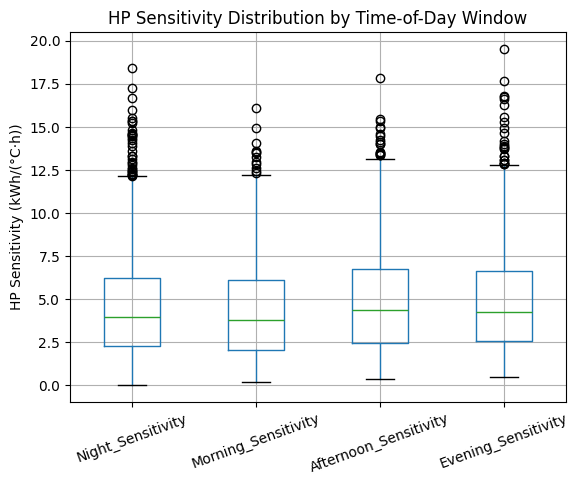

In [ ]:
piece_lin_coeff_hdh_hourly_df[sensitivity_cols].boxplot()
plt.title('HP Sensitivity Distribution by Time-of-Day Window')
plt.ylabel('HP Sensitivity (kWh/(\u00b0C\u00b7h))')
plt.xticks(rotation=20)
plt.show()

In [ ]:
# sensitivity_cols already isolated in cell 46; kept here under the
# original variable name for continuity with anything downstream.
piece_lin_coeff_hdh_hourly_df_s1 = piece_lin_coeff_hdh_hourly_df[sensitivity_cols]
piece_lin_coeff_hdh_hourly_df_s1.head()

,Night_Sensitivity,Morning_Sensitivity,Afternoon_Sensitivity,Evening_Sensitivity
Substation_ID,,,,
440,5.809803,6.668432,7.134947,6.408531
573,4.733400,3.947055,4.629819,4.961560
946,1.193183,1.149639,1.574826,2.158242
997,4.757115,5.973570,6.029737,5.337587
503,4.856678,6.443727,6.480968,6.071043


In [ ]:
# Correlation of each time-window's HP sensitivity with HP_Peak.
combined_df = piece_lin_coeff_hdh_hourly_df[sensitivity_cols].join(substations_df_train['HP_Peak'])

correlation_matrix = combined_df.corr()
hp_peak_correlations = correlation_matrix['HP_Peak'].drop('HP_Peak')

print("Correlation of time-window HP Sensitivity with HP_Peak:")
display(hp_peak_correlations.to_frame().T.style.background_gradient(cmap='RdYlGn', axis=1))

Correlation of time-window HP Sensitivity with HP_Peak:


,Night_Sensitivity,Morning_Sensitivity,Afternoon_Sensitivity,Evening_Sensitivity
HP_Peak,0.918624,0.895716,0.918156,0.938268


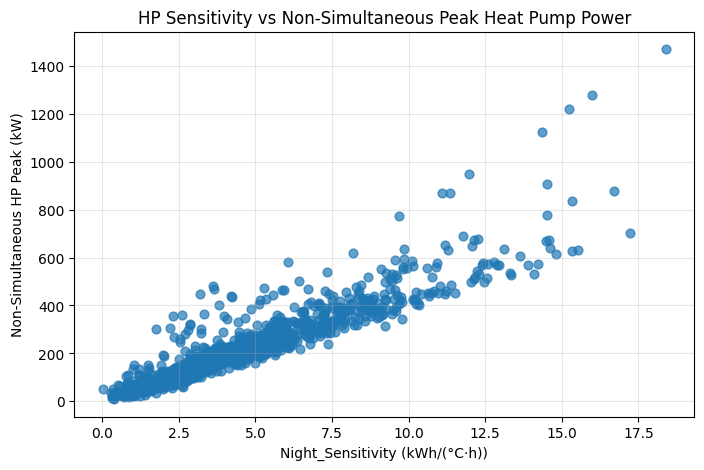

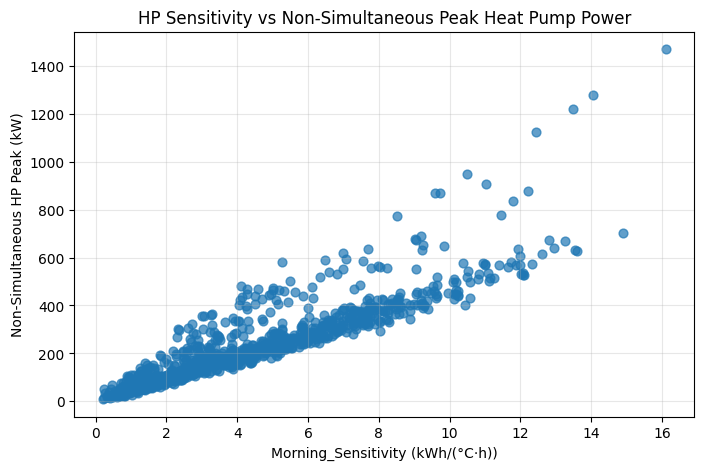

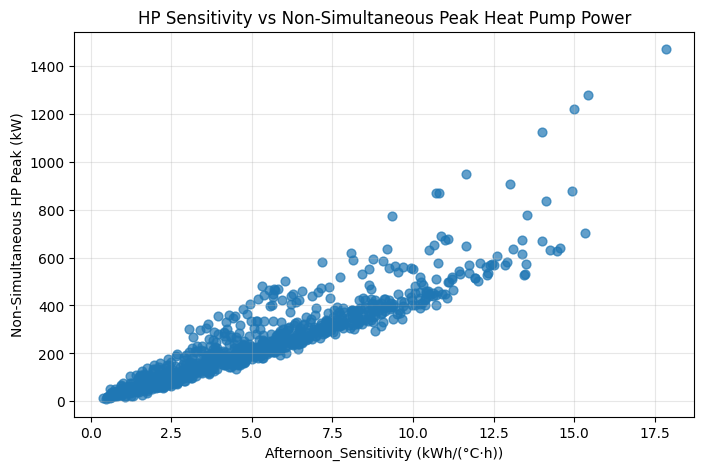

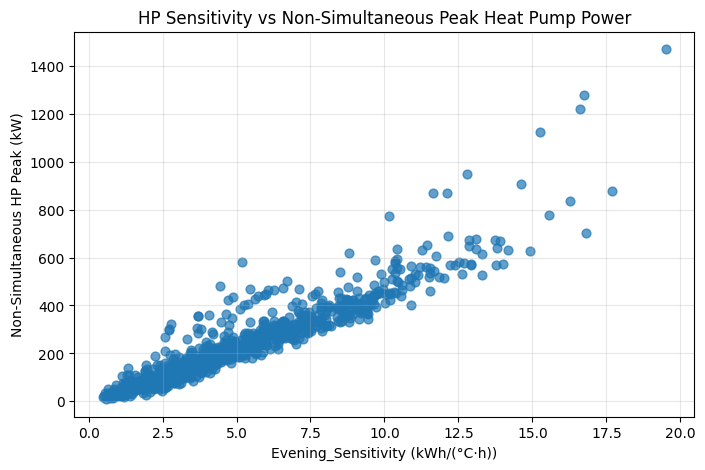

In [ ]:
for col in sensitivity_cols:
    plt.figure(figsize=(8, 5))
    plt.scatter(combined_df[col], combined_df['HP_Peak'], alpha=0.7, s=40)
    plt.xlabel(f'{col} (kWh/(\u00b0C\u00b7h))')
    plt.ylabel('Non-Simultaneous HP Peak (kW)')
    plt.title('HP Sensitivity vs Non-Simultaneous Peak Heat Pump Power')
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
piece_lin_coeff_hdh_hourly_test = {}
r2_score_hdh_hourly_test = {}

for id in tqdm(substations_df_test.index, desc='Fitting HDH model by time-of-day window'):
    try:
        temp_h = substations_df_test.loc[id, 'Temperature'].resample('h').mean()
        load_h = substations_df_test.loc[id, 'Total_Load'].resample('h').mean()

        sm_data = pd.DataFrame({'Temperature': temp_h, 'Total_Load': load_h}).dropna()

        piece_lin_coeff_hdh_hourly_test[id] = {}
        r2_score_hdh_hourly_test[id] = {}

        for group_name, hours in hour_groups.items():
            group_data = sm_data[sm_data.index.hour.isin(hours)]

            x, y = daily_hdh_energy(
                group_data['Temperature'],
                group_data['Total_Load'],
                hdh_thresh=HDH_THRESH
            )

            if len(x) < MIN_HEATING_DAYS:
                continue

            try:
                base_load, hp_sensitivity, r2 = fit_hdh_linear(x, y)
            except Exception:
                continue

            piece_lin_coeff_hdh_hourly_test[id][f'{group_name}_BaseLoad'] = base_load
            piece_lin_coeff_hdh_hourly_test[id][f'{group_name}_Sensitivity'] = hp_sensitivity
            r2_score_hdh_hourly_test[id][group_name] = r2

    except Exception:
        pass

Fitting HDH model by time-of-day window: 100%|██████████| 1000/1000 [00:25<00:00, 39.39it/s]


In [ ]:
piece_lin_coeff_hdh_hourly_test_df = pd.DataFrame.from_dict(piece_lin_coeff_hdh_hourly_test, orient='index')
piece_lin_coeff_hdh_hourly_test_df.index.name = 'Substation_ID'

r2_score_hdh_hourly_test_df = pd.DataFrame.from_dict(r2_score_hdh_hourly_test, orient='index')
r2_score_hdh_hourly_test_df.index.name = 'Substation_ID'

In [ ]:
combined_hdh_test_df = piece_lin_coeff_hdh_hourly_test_df[sensitivity_cols].join(substations_df_test['HP_Peak'])

Selected Ridge alpha: 10.0000


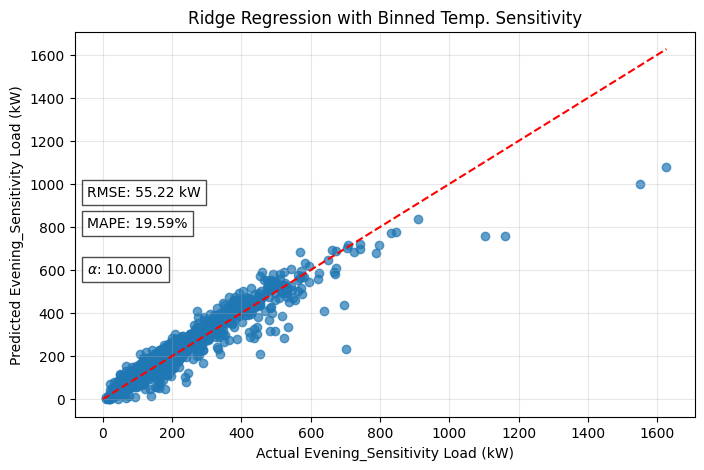

In [ ]:
sensitivity_model_hdh = RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)
sensitivity_model_hdh.fit(combined_hdh_test_df[sensitivity_cols], combined_hdh_test_df['HP_Peak'])
print(f"Selected Ridge alpha: {sensitivity_model_hdh.alpha_:.4f}")

sensitivity_pred = sensitivity_model_hdh.predict(combined_hdh_test_df[sensitivity_cols])
sensitivity_pred = np.maximum(sensitivity_pred, 0) # ensure no negative predictions

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(combined_hdh_test_df['HP_Peak'], sensitivity_pred, alpha=0.7)
ax.plot([0, combined_hdh_test_df['HP_Peak'].max()], [0, combined_hdh_test_df['HP_Peak'].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'Ridge Regression with Binned Temp. Sensitivity')
mask = combined_hdh_test_df['HP_Peak'].values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(combined_hdh_test_df['HP_Peak'].values[mask], sensitivity_pred[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(combined_hdh_test_df['HP_Peak'].values, sensitivity_pred)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.02, 0.4, f'$\\alpha$: {sensitivity_model_hdh.alpha_:.4f}', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.grid(alpha=0.3)
plt.show()

## Baseline (Peak Net Load = Simultaneous HP Peak Load)

In [ ]:
# Baseline cell — see Feature_Max_Max in X_test for a simple peak-load baseline.


## Time Based Features

In [ ]:
TIME_FEATURES_PATH = 'data/substations_time_data.pkl'

if regenerate_time_features or not os.path.exists(TIME_FEATURES_PATH):
    substations_time = {}
    resolution = 15        # minutes
    T_base = HEATING_SEASON_THRESH   # use the single global constant

    for i in trange(len(substations_df), desc='Extracting time-of-day features'):
        sub_df     = substations_df.iloc[i]['Total_Load'].resample(f'{resolution}min').mean().ffill()
        weather_df = substations_df.iloc[i]['Temperature'].resample(f'{resolution}min').mean().ffill()

        # weekdays only
        sub_df     = sub_df[sub_df.index.weekday < 5]
        weather_df = weather_df[weather_df.index.weekday < 5]

        daily_load    = (sub_df.to_frame('Total_Load')
                         .assign(Date=sub_df.index.date, Time=sub_df.index.time)
                         .pivot(index='Date', columns='Time', values='Total_Load').ffill())
        daily_weather = (weather_df.to_frame('Temperature')
                         .assign(Date=weather_df.index.date, Time=weather_df.index.time)
                         .pivot(index='Date', columns='Time', values='Temperature').ffill())
        daily_weather = daily_weather[daily_weather.index.isin(daily_load.index)]

        hdh = np.maximum(0, T_base - daily_weather)

        feats = {
            'Mean':        daily_load.mean(axis=0),
            'Std':         daily_load.std(axis=0),
            'Min':         daily_load.min(axis=0),
            'Max':         daily_load.max(axis=0),
            'Skew':        daily_load.skew(axis=0),
            'Kurtosis':    daily_load.kurtosis(axis=0),
            'Max-Min':     daily_load.max(axis=0) - daily_load.min(axis=0),
            'Cov':         np.array([np.cov(daily_load.iloc[:, t],
                                            daily_weather.iloc[:, t])[0][1]
                                     for t in range(daily_load.shape[1])]),
            'Corr_Pearson': pearsonr(x=daily_load, y=daily_weather, axis=0).statistic,
            'Corr_HDH':    pearsonr(x=daily_load, y=hdh, axis=0).statistic,
        }

        feat_df = pd.DataFrame(feats)
        substations_time[i] = {
            f'Feature {stat}_{ts}': feat_df[stat][ts]
            for stat in feat_df.columns
            for ts in feat_df.index
        }

    substations_time_df = pd.DataFrame.from_dict(substations_time, orient='index')
    pickle.dump(substations_time_df, open(TIME_FEATURES_PATH, 'wb'))
    print(f"Time features saved → {TIME_FEATURES_PATH}")
else:
    substations_time_df = pickle.load(open(TIME_FEATURES_PATH, 'rb'))
    print(f"Time features loaded from {TIME_FEATURES_PATH}")


Time features loaded from data/substations_time_data.pkl


In [ ]:
substations_time_df = pickle.load(open('data/substations_time_data.pkl', 'rb'))

# FIX: fillna(0) is wrong for Corr_Pearson/Corr_HDH columns -- 0 means "no
# correlation", not "missing data". Use the column median for correlation
# features and 0 only for magnitude features.
corr_cols = [c for c in substations_time_df.columns if 'Corr' in c]
other_cols = [c for c in substations_time_df.columns if c not in corr_cols]

substations_time_df[corr_cols] = substations_time_df[corr_cols].apply(lambda col: col.fillna(col.median()))
substations_time_df[other_cols] = substations_time_df[other_cols].fillna(0)

substations_time_df['HP_Peak'] = substations_df['HP_Peak'].copy()

# Peak-load-normalized magnitude features: dividing by each substation's
# own observed peak load removes the size confound without requiring
# household-count metadata (not available for external datasets).
peak_load = [substations_df['Total_Load'].iloc[i].max() for i in range(len(substations_df))]
magnitude_keys = ['Mean', 'Std', 'Min', 'Max', 'Max-Min', 'Cov']

for col in list(substations_time_df.columns):
    if col == 'HP_Peak':
        continue
    if any(col.startswith(f'Feature {k}_') for k in magnitude_keys):
        substations_time_df[f'{col}_per_peak'] = (substations_time_df[col] / np.array(peak_load)).copy()

substations_time_df_train, substations_time_df_test = train_test_split(substations_time_df, test_size=0.5, random_state=42)

X_train_time = substations_time_df_train.drop(columns=['HP_Peak'])
y_train_time = substations_time_df_train[['HP_Peak']]

X_test_time = substations_time_df_test.drop(columns=['HP_Peak'])
y_test_time = substations_time_df_test[['HP_Peak']]

C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_40708\2910605758.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  substations_time_df['HP_Peak'] = substations_df['HP_Peak'].copy()
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_40708\2910605758.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  substations_time_df[f'{col}_per_peak'] = (substations_time_df[col] / np.array(peak_load)).copy()
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_40708\2910605758.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usual

In [ ]:
def _make_xgb_objective(X_train, y_train, feature_columns=None):
    """Build a Hyperopt objective closed over a specific training split.

    If feature_columns is not None the objective also searches over the
    supplied feature-column presets (list of lists), treating feature subset
    choice as a categorical hyperparameter.  This is how feature selection
    is embedded in the XGBoost HPO loop for the windowed-HDD pipeline.
    """
    has_feature_choice = feature_columns is not None

    def objective(space):
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train, y_train, test_size=0.2, random_state=42)

        if has_feature_choice:
            cols = feature_columns[int(space['feature_preset_idx'])]
            X_tr  = X_tr[cols]
            X_val = X_val[cols]

        reg = xgb.XGBRegressor(
            learning_rate     = space['eta'],
            n_estimators      = int(space['n_estimators']),
            max_depth         = int(space['max_depth']),
            gamma             = space['gamma'],
            subsample         = space['subsample'],
            reg_alpha         = space['reg_alpha'],
            reg_lambda        = space['reg_lambda'],
            min_child_weight  = int(space['min_child_weight']),
            colsample_bytree  = space['colsample_bytree'],
            eval_metric       = 'mae',
            tree_method       = 'hist',
            early_stopping_rounds = 20,
            n_jobs            = -1,
        )
        reg.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        pred = reg.predict(X_val)
        return {'loss': mean_squared_error(y_val, pred), 'status': STATUS_OK}

    return objective


def tune_and_train_xgb(X_train, y_train, max_evals=150, feature_columns=None):
    """Tune XGBoost hyperparameters with Hyperopt then fit on full training set.

    Parameters
    ----------
    X_train, y_train : training data (the objective is closed over these)
    max_evals        : Hyperopt budget
    feature_columns  : optional list-of-column-lists for feature-subset HPO;
                       if provided, the best subset is also returned
    """
    space = {
        'eta':              hp.uniform('eta', 0.01, 0.3),
        'max_depth':        hp.quniform('max_depth', 3, 10, 1),
        'gamma':            hp.uniform('gamma', 0, 10),
        'subsample':        hp.uniform('subsample', 0.5, 1.0),
        'reg_alpha':        hp.uniform('reg_alpha', 0, 1),
        'reg_lambda':       hp.uniform('reg_lambda', 0, 10),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.3, 1.0),
        'min_child_weight': hp.quniform('min_child_weight', 1, 20, 1),
        'n_estimators':     hp.quniform('n_estimators', 50, 500, 10),
    }
    if feature_columns is not None:
        space['feature_preset_idx'] = hp.quniform(
            'feature_preset_idx', 0, len(feature_columns) - 1, 1)

    objective = _make_xgb_objective(X_train, y_train, feature_columns)

    t0 = time.time()
    best_params = fmin(fn=objective, space=space, algo=tpe.suggest,
                       max_evals=max_evals, trials=Trials(),
                       early_stop_fn=no_progress_loss(30))
    print(f"Hyperopt tuning: {time.time() - t0:.1f}s")

    # Resolve best feature subset
    best_cols = None
    if feature_columns is not None:
        best_cols = feature_columns[int(best_params['feature_preset_idx'])]
        X_fit = X_train[best_cols]
    else:
        X_fit = X_train

    model = xgb.XGBRegressor(
        learning_rate     = best_params['eta'],
        n_estimators      = int(best_params['n_estimators']),
        max_depth         = int(best_params['max_depth']),
        gamma             = best_params['gamma'],
        subsample         = best_params['subsample'],
        reg_alpha         = best_params['reg_alpha'],
        reg_lambda        = best_params['reg_lambda'],
        min_child_weight  = int(best_params['min_child_weight']),
        colsample_bytree  = best_params['colsample_bytree'],
        eval_metric       = 'mae',
        tree_method       = 'hist',
    )
    t1 = time.time()
    model.fit(X_fit, y_train)
    print(f"Final fit: {time.time() - t1:.1f}s")

    meta = dict(best_params)
    if best_cols is not None:
        meta['best_feature_cols'] = best_cols
    return model, meta


def tune_and_train_ridge(X_train, y_train, k_values=None):
    """Tune Ridge + SelectKBest(f_regression) via GridSearchCV on training data.

    k_values controls how many top features to keep; defaults to a log-spaced
    grid covering 10 % → 100 % of the available features.
    """
    n_features = X_train.shape[1]
    if k_values is None:
        k_values = sorted(set(
            np.unique(np.geomspace(max(5, n_features // 20), n_features, 12).astype(int)).tolist()
            + [n_features]))

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('selector', SelectKBest(f_regression)),
        ('ridge',   RidgeCV(alphas=np.logspace(-3, 4, 30), cv=5)),
    ])

    param_grid = {'selector__k': k_values}

    cv_search = GridSearchCV(pipe, param_grid,
                             scoring='neg_root_mean_squared_error',
                             cv=5, n_jobs=-1)
    t0 = time.time()
    cv_search.fit(X_train, y_train)
    print(f"Ridge + SelectKBest CV: {time.time() - t0:.1f}s  |  "
          f"best k={cv_search.best_params_['selector__k']}  |  "
          f"CV RMSE={-cv_search.best_score_:.2f} kW")
    return cv_search.best_estimator_, cv_search.best_params_


In [ ]:
def clip_non_negative(values):
    return np.maximum(np.asarray(values, dtype=float), 0.0)


def summarize_prediction_metrics(y_true, y_pred):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    rmse = root_mean_squared_error(y_true_arr, y_pred_arr)

    nonzero_mask = y_true_arr != 0
    if np.any(nonzero_mask):
        mape = mean_absolute_percentage_error(y_true_arr[nonzero_mask], y_pred_arr[nonzero_mask]) * 100
    else:
        mape = np.nan

    return rmse, mape


def plot_prediction_scatter(y_true, y_pred, title, xlabel="Actual Load (kW)", ylabel="Predicted Load (kW)"):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    fig, ax = plt.subplots()
    ax.scatter(y_true_arr, y_pred_arr, alpha=0.7)

    y_max = max(float(np.nanmax(y_true_arr)), float(np.nanmax(y_pred_arr)))
    y_limit = y_max * 1.1 if y_max > 0 else 1.0

    ax.plot([0, y_max], [0, y_max], 'r--')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    rmse, mape = summarize_prediction_metrics(y_true_arr, y_pred_arr)
    ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))

    if np.isfinite(mape):
        ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
    else:
        ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))

    ax.set_ylim([0, y_limit])
    return fig, ax, rmse, mape


def load_or_train_model(model_factory, X_train, y_train, model_path=None, hyperparams_path=None, retrain=False):
    if not retrain and model_path and hyperparams_path and os.path.exists(model_path) and os.path.exists(hyperparams_path):
        with open(model_path, 'rb') as model_file:
            model = pickle.load(model_file)
        with open(hyperparams_path, 'rb') as params_file:
            best_params = pickle.load(params_file)
        return model, best_params

    model, best_params = model_factory(X_train, y_train)

    if model_path:
        with open(model_path, 'wb') as model_file:
            pickle.dump(model, model_file)

    if hyperparams_path:
        with open(hyperparams_path, 'wb') as params_file:
            pickle.dump(best_params, params_file)

    return model, best_params

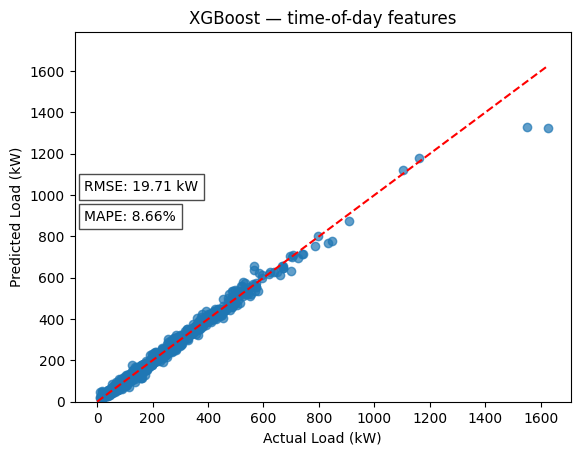

In [ ]:
TARGET_COL = 'HP_Peak'

xgb_time_model, xgb_time_hyperparams = load_or_train_model(
    model_factory = lambda X, y: tune_and_train_xgb(X, y),
    X_train       = X_train_time,
    y_train       = y_train_time[TARGET_COL],
    model_path    = 'models/xgb_time_model.pkl',
    hyperparams_path = 'models/xgb_time_hyperparams.pkl',
    retrain       = retrain_xgb_time,
)

xgb_pred_time = clip_non_negative(xgb_time_model.predict(X_test_time))
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_time[TARGET_COL], xgb_pred_time,
    title='XGBoost — time-of-day features')
plt.show()


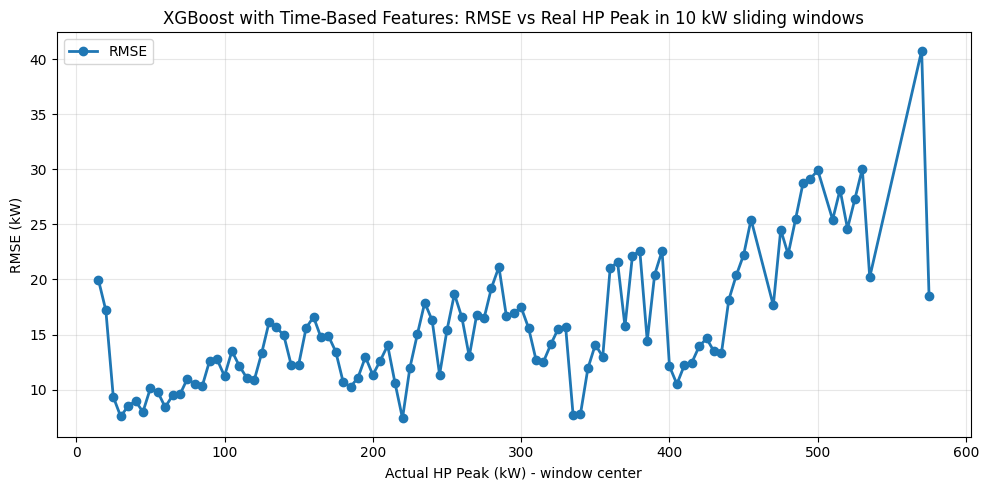

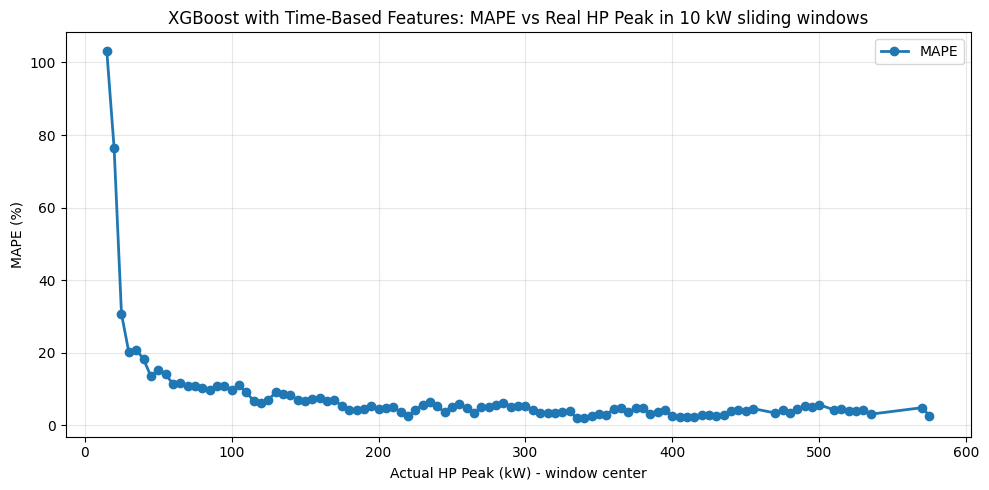

In [ ]:
# Actual HP peak values from the test set
y_true = y_test_time['HP_Peak'].to_numpy()

# Predictions from the existing XGBoost model (cell 74)
y_pred = np.asarray(xgb_pred_time).reshape(-1)

# RMSE in rolling/sliding windows of 10 kW on the actual HP values
window_kW = 10.0
step_kW = 5.0  # 50% overlap between consecutive windows

min_val = np.floor(y_true.min() / window_kW) * window_kW
max_val = np.ceil(y_true.max() / window_kW) * window_kW

centers = np.arange(min_val + window_kW / 2, max_val, step_kW)
rmse_vals = []
counts = []

for c in centers:
    mask = (y_true >= c - window_kW / 2) & (y_true < c + window_kW / 2)
    n = int(mask.sum())
    counts.append(n)

    if n < 5:
        rmse_vals.append(np.nan)
    else:
        err = y_true[mask] - y_pred[mask]
        rmse_vals.append(np.sqrt(np.mean(err**2)))

centers = np.asarray(centers)
rmse_vals = np.asarray(rmse_vals)
counts = np.asarray(counts)

nonzero_mask = y_true != 0
mape_nonzero = mean_absolute_percentage_error(y_true[nonzero_mask], y_pred[nonzero_mask]) * 100

plt.figure(figsize=(10, 5))
valid = np.isfinite(rmse_vals)
plt.plot(centers[valid], rmse_vals[valid], marker='o', linewidth=2, label='RMSE')
plt.xlabel('Actual HP Peak (kW) - window center')
plt.ylabel('RMSE (kW)')
plt.title(f'XGBoost with Time-Based Features: RMSE vs Real HP Peak in 10 kW sliding windows')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
mape_vals = []

for c in centers:
    window_mask = (y_true >= c - window_kW / 2) & (y_true < c + window_kW / 2) & (y_true != 0)
    if int(window_mask.sum()) < 5:
        mape_vals.append(np.nan)
    else:
        err_pct = np.abs((y_true[window_mask] - y_pred[window_mask]) / y_true[window_mask]) * 100
        mape_vals.append(np.mean(err_pct))

mape_vals = np.asarray(mape_vals)

plt.figure(figsize=(10, 5))
valid_mape = np.isfinite(mape_vals)
plt.plot(centers[valid_mape], mape_vals[valid_mape], marker='o', linewidth=2, label='MAPE')
plt.xlabel('Actual HP Peak (kW) - window center')
plt.ylabel('MAPE (%)')
plt.title('XGBoost with Time-Based Features: MAPE vs Real HP Peak in 10 kW sliding windows')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


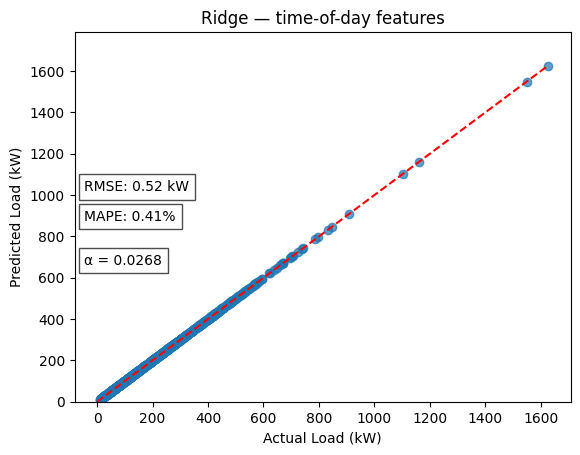

In [ ]:
ridge_time_model, _ = load_or_train_model(
    model_factory = lambda X, y: (
        (lambda m: (m.fit(X, y), m)[1])(RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)),
        {'alpha': None}   # placeholder; alpha recovered from model below
    ),
    X_train       = X_train_time,
    y_train       = y_train_time[TARGET_COL],
    model_path    = 'models/ridge_time_model.pkl',
    hyperparams_path = None,
    retrain       = retrain_ridge_time,
)

# If freshly trained, the factory lambda returns (fitted_model, placeholder_dict).
# load_or_train_model unpacks correctly either way.
if isinstance(ridge_time_model, tuple):
    ridge_time_model = ridge_time_model[0]

ridge_pred_time = clip_non_negative(ridge_time_model.predict(X_test_time))
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_time[TARGET_COL], ridge_pred_time,
    title='Ridge — time-of-day features')
ax.text(0.02, 0.4, f'α = {ridge_time_model.alpha_:.4f}', transform=ax.transAxes,
        va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()


## Time-Based + Piecewise Linear Coefficients

In [ ]:
substations_time_hockey_train_df = substations_time_df_train.join(piece_lin_coeff_df, how='left')
substations_time_hockey_test_df = substations_time_df_test.join(piece_lin_coeff_df, how='left')

In [ ]:
X_train_time_hockey = substations_time_hockey_train_df.drop(columns=['HP_Peak'])
y_train_time_hockey = substations_time_hockey_train_df[['HP_Peak']]

X_test_time_hockey = substations_time_hockey_test_df.drop(columns=['HP_Peak'])
y_test_time_hockey = substations_time_hockey_test_df[['HP_Peak']]


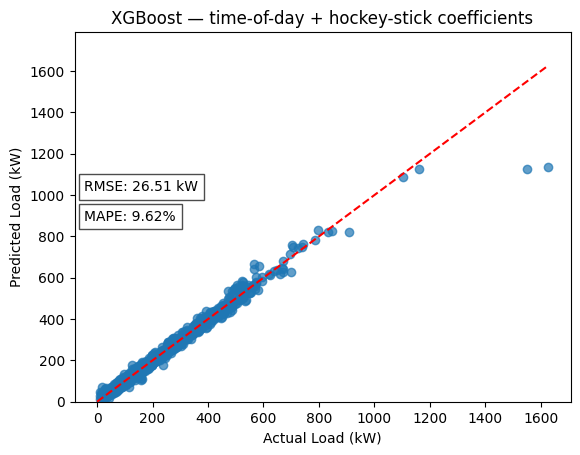

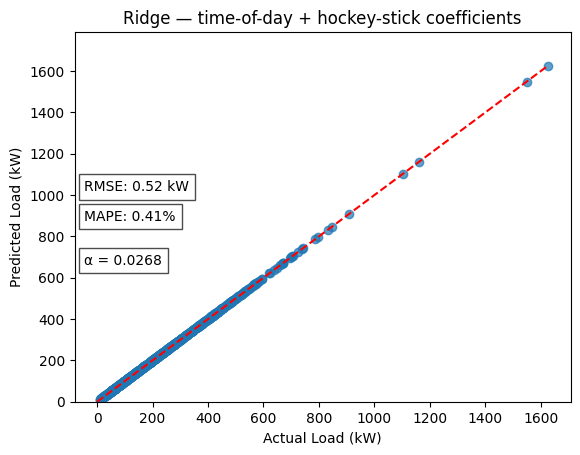

In [ ]:
xgb_time_hockey_model, xgb_time_hockey_hyperparams = load_or_train_model(
    model_factory = lambda X, y: tune_and_train_xgb(X, y),
    X_train       = X_train_time_hockey,
    y_train       = y_train_time_hockey[TARGET_COL],
    model_path    = 'models/xgb_time_hockey_model.pkl',
    hyperparams_path = 'models/xgb_time_hockey_hyperparams.pkl',
    retrain       = retrain_xgb_time_hockey,
)

xgb_pred_time_hockey = clip_non_negative(xgb_time_hockey_model.predict(X_test_time_hockey))
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_time_hockey[TARGET_COL], xgb_pred_time_hockey,
    title='XGBoost — time-of-day + hockey-stick coefficients')
plt.show()

ridge_time_hockey_model, _ = load_or_train_model(
    model_factory = lambda X, y: (
        (lambda m: (m.fit(X, y), m)[1])(RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)),
        {}
    ),
    X_train       = X_train_time_hockey,
    y_train       = y_train_time_hockey[TARGET_COL],
    model_path    = 'models/ridge_time_hockey_model.pkl',
    hyperparams_path = None,
    retrain       = retrain_ridge_time_hockey,
)
if isinstance(ridge_time_hockey_model, tuple):
    ridge_time_hockey_model = ridge_time_hockey_model[0]

ridge_pred_time_hockey = clip_non_negative(ridge_time_hockey_model.predict(X_test_time_hockey))
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_time_hockey[TARGET_COL], ridge_pred_time_hockey,
    title='Ridge — time-of-day + hockey-stick coefficients')
ax.text(0.02, 0.4, f'α = {ridge_time_hockey_model.alpha_:.4f}', transform=ax.transAxes,
        va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()


## HDD Bins

In [ ]:
# Windowed-HDD feature extractor now lives in hp_capacity.py (single source of
# truth, shared with the regeneration script). Ported verbatim from this cell,
# with output verified bit-for-bit identical. See hp_capacity.py for the code.
from hp_capacity import (
    extract_windowed_hdd_features_from_series,
    extract_windowed_hdd_features_from_entity_dataframe,
)


In [ ]:
# Shared boolean arguments for all windowed HDD feature extractions
windowed_hdd_feature_kwargs = dict(
    weekday_only=True,
    include_shape=False,
    include_minmax=True,
    include_quantiles=True,
    include_n_days=False,
    include_corr_features=False,
    include_climate_context=False,
    normalize_by_peak=True,
)

def build_windowed_hdd_kwargs(**overrides):
    kwargs = dict(windowed_hdd_feature_kwargs)
    kwargs.update(overrides)
    return kwargs

In [ ]:
substations_windowed_hdd_df = extract_windowed_hdd_features_from_entity_dataframe(
    entity_df=substations_df,
    load_col="Total_Load",
    temp_col="Temperature",
    resolution=15,
    T_base=12.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    **build_windowed_hdd_kwargs(),
)


Extracting windowed HDD-binned features: 100%|██████████| 2000/2000 [04:42<00:00,  7.08it/s]


In [ ]:
train_idx = substations_windowed_hdd_df.index.intersection(substations_time_df_train.index)
train_idx = train_idx.intersection(y_train_time_hockey.index)

test_idx = substations_windowed_hdd_df.index.intersection(substations_time_df_test.index)
test_idx = test_idx.intersection(y_test_time_hockey.index)

X_train_windowed_hdd = substations_windowed_hdd_df.loc[train_idx].copy()
y_train_windowed_hdd = y_train_time_hockey.loc[train_idx, 'HP_Peak'].copy()

X_test_windowed_hdd = substations_windowed_hdd_df.loc[test_idx].copy()
y_test_windowed_hdd = y_test_time_hockey.loc[test_idx, 'HP_Peak'].copy()

In [ ]:
feature_presets = [
    "mean_q95_only",
    "comparative_mean_q95",
    "core",
    "comparative_only",
    "no_shape_no_corr",
    "per_bin_only",
    "all",
]

In [ ]:
def get_feature_columns(X, preset):
    cols = list(X.columns)

    if preset == "all":
        return cols

    if preset == "core":
        return [
            c for c in cols
            if (
                c.endswith("_Mean")
                or c.endswith("_Std")
                or c.endswith("_Q50")
                or c.endswith("_Q95")
                or "delta_Mean" in c
                or "delta_Q95" in c
                or "ratio_Mean" in c
                or "ratio_Q95" in c
                or "normdelta_Mean" in c
                or "normdelta_Q95" in c
            )
        ]

    if preset == "mean_q95_only":
        return [
            c for c in cols
            if (
                c.endswith("_Mean")
                or c.endswith("_Q95")
                or "delta_Mean" in c
                or "delta_Q95" in c
                or "normdelta_Mean" in c
                or "normdelta_Q95" in c
            )
        ]

    if preset == "comparative_only":
        return [
            c for c in cols
            if (
                "delta_" in c
                or "ratio_" in c
                or "normdelta_" in c
            )
        ]

    if preset == "comparative_mean_q95":
        return [
            c for c in cols
            if (
                "delta_Mean" in c
                or "delta_Q95" in c
                or "ratio_Mean" in c
                or "ratio_Q95" in c
                or "normdelta_Mean" in c
                or "normdelta_Q95" in c
            )
        ]

    if preset == "per_bin_only":
        return [
            c for c in cols
            if not (
                "delta_" in c
                or "ratio_" in c
                or "normdelta_" in c
            )
        ]

    if preset == "no_shape_no_corr":
        return [
            c for c in cols
            if (
                "Skew" not in c
                and "Kurtosis" not in c
                and "Corr" not in c
                and "Cov" not in c
            )
        ]

    raise ValueError(f"Unknown preset: {preset}")


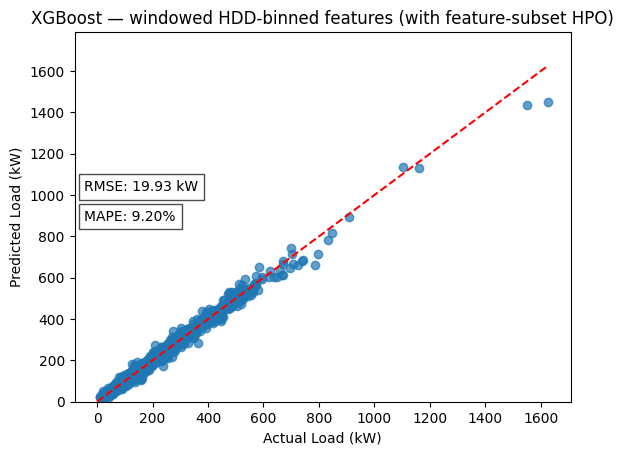

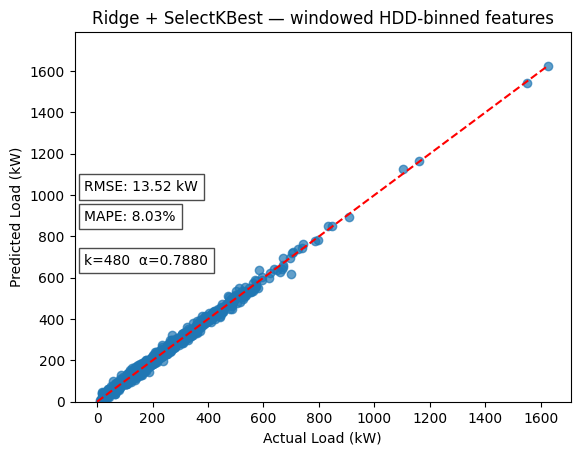

In [ ]:
# Build all feature-preset column lists once, then pass them into both models
# so that feature-subset selection becomes part of their hyperparameter search.
hdd_feature_presets = feature_presets  # defined in cell 100
hdd_feature_col_lists = [
    get_feature_columns(X_train_windowed_hdd, p)
    for p in hdd_feature_presets
]
# Drop empty presets
hdd_feature_col_lists = [c for c in hdd_feature_col_lists if len(c) > 0]

# ── XGBoost with feature-subset HPO ──────────────────────────────────────
xgb_windowed_hdd_model, xgb_windowed_hdd_hyperparams = load_or_train_model(
    model_factory = lambda X, y: tune_and_train_xgb(
        X, y, feature_columns=hdd_feature_col_lists),
    X_train       = X_train_windowed_hdd,
    y_train       = y_train_windowed_hdd,
    model_path    = 'models/xgb_windowed_hdd_model.pkl',
    hyperparams_path = 'models/xgb_windowed_hdd_hyperparams.pkl',
    retrain       = retrain_xgb_windowed_hdd,
)

# When loaded from disk the model was already fit on the best feature subset;
# recover which columns it expects from the saved metadata.
_xgb_hdd_best_cols = xgb_windowed_hdd_hyperparams.get(
    'best_feature_cols', X_train_windowed_hdd.columns.tolist())
xgb_pred_windowed_hdd = clip_non_negative(
    xgb_windowed_hdd_model.predict(X_test_windowed_hdd[_xgb_hdd_best_cols]))

fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_windowed_hdd, xgb_pred_windowed_hdd,
    title='XGBoost — windowed HDD-binned features (with feature-subset HPO)')
plt.show()

# ── Ridge with SelectKBest feature selection (k tuned via CV) ────────────
ridge_windowed_hdd_model, ridge_windowed_hdd_params = load_or_train_model(
    model_factory = lambda X, y: tune_and_train_ridge(X, y),
    X_train       = X_train_windowed_hdd,
    y_train       = y_train_windowed_hdd,
    model_path    = 'models/ridge_windowed_hdd_model.pkl',
    hyperparams_path = 'models/ridge_windowed_hdd_hyperparams.pkl',
    retrain       = retrain_ridge_windowed_hdd,
)

ridge_pred_windowed_hdd = clip_non_negative(
    ridge_windowed_hdd_model.predict(X_test_windowed_hdd))

fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_windowed_hdd, ridge_pred_windowed_hdd,
    title='Ridge + SelectKBest — windowed HDD-binned features')
best_k = ridge_windowed_hdd_params.get('selector__k', '?')
best_alpha = ridge_windowed_hdd_model.named_steps['ridge'].alpha_
ax.text(0.02, 0.4, f'k={best_k}  α={best_alpha:.4f}', transform=ax.transAxes,
        va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()


In [ ]:
# Ridge windowed-HDD model is now in cell 70.


## Partial Least Squares (PLS)

### PLS on raw load time series

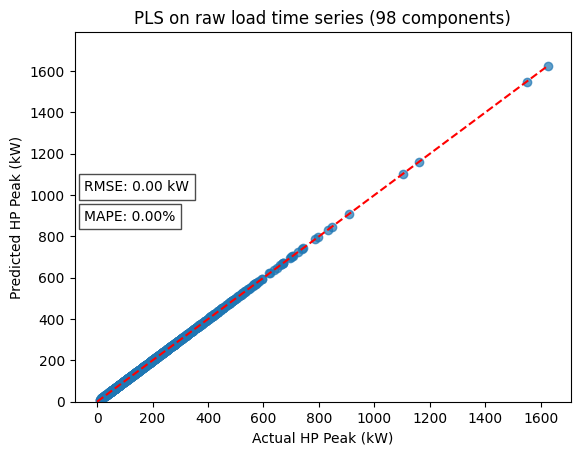

In [ ]:
# Stack each substation's full load time series as a flat feature row.
pls_ts_train = np.vstack([substations_df_train.iloc[i]['Total_Load'].values
                           for i in range(len(substations_df_train))])
pls_ts_test  = np.vstack([substations_df_test.iloc[i]['Total_Load'].values
                           for i in range(len(substations_df_test))])

# Fill any NaNs from ffill
pls_ts_train = pd.DataFrame(pls_ts_train).ffill(axis=1).values
pls_ts_test  = pd.DataFrame(pls_ts_test).ffill(axis=1).values

y_train_pls = substations_df_train['HP_Peak'].values
y_test_pls  = substations_df_test['HP_Peak'].values

def _make_pls_pipeline(n_comp):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pls',     PLSRegression(n_components=n_comp)),
    ])

def tune_and_train_pls(X_train, y_train, n_comp_range=None):
    """Select n_components via 5-fold CV on training data, then refit."""
    max_comp = min(X_train.shape[0], X_train.shape[1], 100)
    if n_comp_range is None:
        n_comp_range = list(range(2, max_comp, max(1, max_comp // 30)))

    param_grid = {'pls__n_components': n_comp_range}
    cv_search  = GridSearchCV(_make_pls_pipeline(1), param_grid,
                              scoring='neg_root_mean_squared_error',
                              cv=5, n_jobs=-1)
    cv_search.fit(X_train, y_train)
    best_n = cv_search.best_params_['pls__n_components']
    print(f"Best n_components (CV): {best_n}  |  "
          f"CV RMSE: {-cv_search.best_score_:.2f} kW")
    return cv_search.best_estimator_, {'n_components': best_n,
                                        'cv_results': cv_search.cv_results_}


pls_ts_model, pls_ts_meta = load_or_train_model(
    model_factory    = lambda X, y: tune_and_train_pls(X, y),
    X_train          = pls_ts_train,
    y_train          = y_train_pls,
    model_path       = 'models/pls_time_series_model.pkl',
    hyperparams_path = 'models/pls_time_series_meta.pkl',
    retrain          = retrain_pls_time_series,
)

pls_ts_pred = clip_non_negative(pls_ts_model.predict(pls_ts_test).ravel())
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_pls, pls_ts_pred,
    title=f'PLS on raw load time series ({pls_ts_meta["n_components"]} components)',
    xlabel='Actual HP Peak (kW)', ylabel='Predicted HP Peak (kW)')
plt.show()


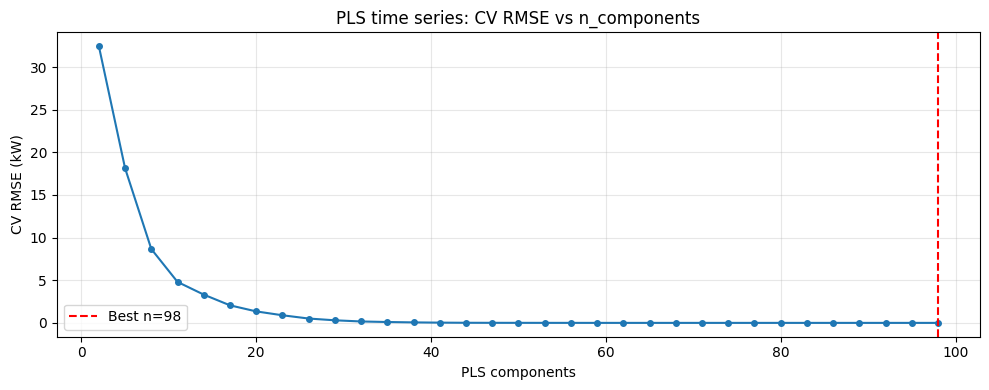

In [ ]:
cv_res = pls_ts_meta.get('cv_results', {})
if cv_res:
    n_vals  = [p['pls__n_components'] for p in cv_res['params']]
    rmse_cv = [-s for s in cv_res['mean_test_score']]
    plt.figure(figsize=(10, 4))
    plt.plot(n_vals, rmse_cv, marker='o', ms=4)
    plt.axvline(pls_ts_meta['n_components'], color='red', ls='--',
                label=f"Best n={pls_ts_meta['n_components']}")
    plt.xlabel('PLS components')
    plt.ylabel('CV RMSE (kW)')
    plt.title('PLS time series: CV RMSE vs n_components')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [ ]:
# XGBoost PCA sweep removed — see PLS sections above for dimensionality reduction.


In [ ]:
# PCA XGBoost refit cell removed — see PLS sections above.


In [ ]:
# PCA XGBoost diagnostic plot removed — see PLS sections above.


### PLS on time-of-day feature matrix

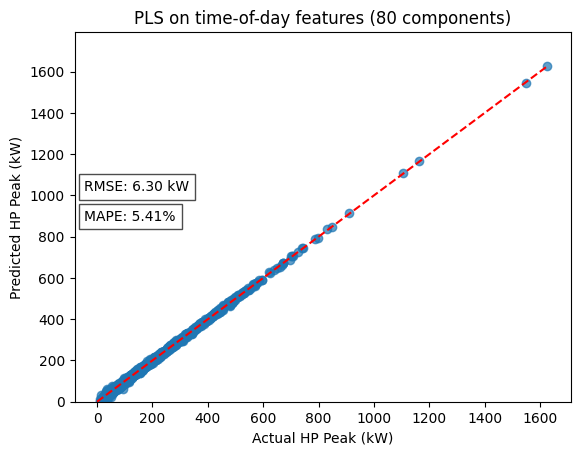

In [ ]:
pls_feat_model, pls_feat_meta = load_or_train_model(
    model_factory    = lambda X, y: tune_and_train_pls(X, y),
    X_train          = X_train_time.values,
    y_train          = y_train_time[TARGET_COL].values,
    model_path       = 'models/pls_features_model.pkl',
    hyperparams_path = 'models/pls_features_meta.pkl',
    retrain          = retrain_pls_features,
)

pls_feat_pred = clip_non_negative(pls_feat_model.predict(X_test_time.values).ravel())
fig, ax, rmse, mape = plot_prediction_scatter(
    y_test_time[TARGET_COL], pls_feat_pred,
    title=f'PLS on time-of-day features ({pls_feat_meta["n_components"]} components)',
    xlabel='Actual HP Peak (kW)', ylabel='Predicted HP Peak (kW)')
plt.show()


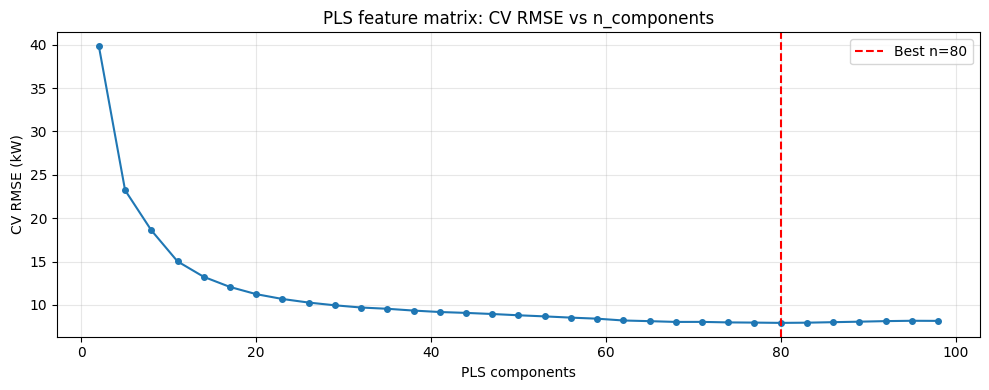

In [ ]:
cv_res_feat = pls_feat_meta.get('cv_results', {})
if cv_res_feat:
    n_vals_f  = [p['pls__n_components'] for p in cv_res_feat['params']]
    rmse_cv_f = [-s for s in cv_res_feat['mean_test_score']]
    plt.figure(figsize=(10, 4))
    plt.plot(n_vals_f, rmse_cv_f, marker='o', ms=4)
    plt.axvline(pls_feat_meta['n_components'], color='red', ls='--',
                label=f"Best n={pls_feat_meta['n_components']}")
    plt.xlabel('PLS components')
    plt.ylabel('CV RMSE (kW)')
    plt.title('PLS feature matrix: CV RMSE vs n_components')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## WPUQ Dataset

In [ ]:
def detect_outliers_wpuq_15min(
    
s,
    lower=0,
    upper=10000,          # W
    days_window=14,       # same quarter-hour across ±14 days
    n_sigma=2.8,          # aggressive
    max_replace_run=4,    # up to 1 hour
    max_interp_run=8,     # up to 2 hours
    passes=2
):
    """
    Aggressive outlier removal for 15-minute WPuQ heat-pump series.

    Parameters
    ----------
    s : pd.Series
        15-minute time series with DateTimeIndex.
    lower, upper : float
        Physical plausibility bounds.
    days_window : int
        Number of days on each side for same-time-of-day seasonal baseline.
    n_sigma : float
        Hampel/MAD threshold on residuals.
    max_replace_run : int
        Consecutive flagged bins replaced by baseline.
    max_interp_run : int
        Consecutive flagged bins interpolated linearly.
    passes : int
        Number of cleaning passes.

    Returns
    -------
    cleaned : pd.Series
    outlier_mask : pd.Series[bool]
    baseline : pd.Series
    """
    s = s.copy().astype(float)
    steps_per_day = 96
    global_mask = pd.Series(False, index=s.index)

    def seasonal_baseline(x):
        base = pd.Series(index=x.index, dtype=float)
        vals = x.values
        n = len(x)

        for i in range(n):
            refs = []
            for d in range(1, days_window + 1):
                for sign in (-1, 1):
                    j = i + sign * d * steps_per_day
                    if 0 <= j < n and not np.isnan(vals[j]):
                        refs.append(vals[j])
            if refs:
                base.iloc[i] = np.median(refs)
            else:
                base.iloc[i] = np.nan

        # fallback near edges
        fallback = x.rolling(steps_per_day, center=True, min_periods=1).median()
        return base.fillna(fallback)

    cleaned = s.copy()

    for _ in range(passes):
        base = seasonal_baseline(cleaned)

        # physical outliers
        mask_phys = (cleaned < lower) | (cleaned > upper)

        # residual outliers
        resid = cleaned - base
        med_r = np.nanmedian(resid)
        mad_r = np.nanmedian(np.abs(resid - med_r))
        if not np.isfinite(mad_r) or mad_r == 0:
            mad_r = 1.0

        mask_resid = np.abs(resid - med_r) > (n_sigma * 1.4826 * mad_r)

        # gradient outliers
        dx = cleaned.diff()
        med_dx = np.nanmedian(dx)
        mad_dx = np.nanmedian(np.abs(dx - med_dx))
        if not np.isfinite(mad_dx) or mad_dx == 0:
            mad_dx = 1.0

        jump_prev = np.abs(cleaned - cleaned.shift(1)) > (3 * 1.4826 * mad_dx)
        jump_next = np.abs(cleaned - cleaned.shift(-1)) > (3 * 1.4826 * mad_dx)
        mask_grad = mask_resid & (jump_prev | jump_next)

        mask = (mask_phys | mask_resid | mask_grad).fillna(False)
        global_mask |= mask

        # handle runs
        run_id = (mask != mask.shift()).cumsum()
        run_len = mask.groupby(run_id).transform("size")

        replace_mask = mask & (run_len <= max_replace_run)
        interp_mask = mask & (run_len > max_replace_run) & (run_len <= max_interp_run)

        cleaned[replace_mask] = base[replace_mask]
        cleaned[interp_mask] = np.nan
        cleaned = cleaned.interpolate(limit=max_interp_run, limit_direction="both")

    baseline = seasonal_baseline(cleaned)
    return cleaned, global_mask, baseline


In [ ]:
wpuq_data = h5py.File('data\\2019_data_15min.hdf5', 'r')
wpuq_transf_df = pd.DataFrame(np.array(wpuq_data['MISC']['ES1']['TRANSFORMER']['table'])) 
wpuq_transf_df['index'] = pd.to_datetime(wpuq_transf_df['index'], utc=True, origin='unix', unit='s')
wpuq_transf_df['P_TOT'] = wpuq_transf_df['P_TOT'] / 1000  # Convert W to kW

substation_total = wpuq_transf_df.set_index('index')
substation_total['Date'] = substation_total.index.date
substation_total['Time'] = substation_total.index.time
substation_total = substation_total[['P_TOT', 'Date', 'Time']]

In [ ]:
wpuq_weather = h5py.File('data\\2019_weather.hdf5', 'r')
wpuq_weather_df = pd.DataFrame(np.array(wpuq_weather['WEATHER_SERVICE']['IN']['WEATHER_TEMPERATURE_TOTAL']['table']))
wpuq_weather_df['index'] = pd.to_datetime(wpuq_weather_df['index'], utc=True, origin='unix', unit='ns')

wpuq_weather_df = wpuq_weather_df.set_index('index').resample('15min').mean()[:-1]
wpuq_weather_df.index = wpuq_weather_df.index.shift(periods=1, freq='h')
wpuq_weather_df['Date'] = wpuq_weather_df.index.date
wpuq_weather_df['Time'] = wpuq_weather_df.index.time

# wpuq_weather_df = wpuq_weather_df[wpuq_weather_df.index.weekday < 5]  # Keep only weekdays
wpuq_weather_df = wpuq_weather_df[wpuq_weather_df.index >= pd.Timestamp('2019-01-01 00:00:00', tz='UTC')]
wpuq_weather_df = wpuq_weather_df[wpuq_weather_df.index <= pd.Timestamp('2019-12-31 23:45:00', tz='UTC')]  # Keep only 2019 data

wpuq_weather_df['TEMPERATURE:TOTAL'] = wpuq_weather_df['TEMPERATURE:TOTAL'].interpolate(method='time')
wpuq_weather_df['TEMPERATURE:TOTAL'] = wpuq_weather_df['TEMPERATURE:TOTAL'].ffill().bfill()

In [ ]:
wpuq_hp_data = {}
wpuq_house_data = {}

full_year_no_weekends_wpuq = pd.date_range(start='2019-01-01', end='2019-12-31 23:45:00', freq='15min', tz='UTC')
# full_year_no_weekends_wpuq = full_year_no_weekends_wpuq[full_year_no_weekends_wpuq.weekday < 5]  # filter to weekdays

for building in wpuq_data['NO_PV'].keys():
    hp_df = pd.DataFrame(np.array(wpuq_data['NO_PV'][building]['HEATPUMP']['table']))
    hp_df['index'] = pd.to_datetime(hp_df['index'], utc=True, origin='unix', unit='s')
    house_df = pd.DataFrame(np.array(wpuq_data['NO_PV'][building]['HOUSEHOLD']['table']))
    house_df['index'] = pd.to_datetime(house_df['index'], utc=True, origin='unix', unit='s')

    hp_df.dropna(inplace=True)
    house_df.dropna(inplace=True)

    # hp_df = hp_df[hp_df['index'].dt.weekday < 5]  # filter to weekdays
    # house_df = house_df[house_df['index'].dt.weekday < 5]  # filter to weekdays


    if len(hp_df) >= len(full_year_no_weekends_wpuq) * 0.8:  # check if data has at least a year's worth of 15-min intervals

        hp_df = hp_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        hp_df_cleaned, hp_outliers, hp_baseline = detect_outliers_wpuq_15min(hp_df['P_TOT'])
        print(f"Building: {building}, Original HP Peak: {hp_df['P_TOT'].max() / 1000:.2f} kW, Cleaned HP Peak: {hp_df_cleaned.max() / 1000:.2f} kW")
        wpuq_hp_data[building] = hp_df_cleaned / 1000  # Convert W to kW
    if len(house_df) >= len(full_year_no_weekends_wpuq) * 0.8:

        house_df = house_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        house_df_cleaned, house_outliers, house_baseline = detect_outliers_wpuq_15min(house_df['P_TOT'])
        wpuq_house_data[building] = house_df_cleaned / 1000  # Convert W to kW

# --------------------------------

for building in wpuq_data['WITH_PV'].keys():
    hp_df = pd.DataFrame(np.array(wpuq_data['WITH_PV'][building]['HEATPUMP']['table']))
    hp_df['index'] = pd.to_datetime(hp_df['index'], utc=True, origin='unix', unit='s')
    house_df = pd.DataFrame(np.array(wpuq_data['WITH_PV'][building]['HOUSEHOLD']['table']))
    house_df['index'] = pd.to_datetime(house_df['index'], utc=True, origin='unix', unit='s')

    hp_df.dropna(inplace=True)
    house_df.dropna(inplace=True)

    # hp_df = hp_df[hp_df['index'].dt.weekday < 5]  # filter to weekdays
    # house_df = house_df[house_df['index'].dt.weekday < 5]  # filter to weekdays


    if len(hp_df) >= len(full_year_no_weekends_wpuq) * 0.8:  # check if data has at least a year's worth of 15-min intervals

        hp_df = hp_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        hp_df_cleaned, hp_outliers, hp_baseline = detect_outliers_wpuq_15min(hp_df['P_TOT'])
        print(f"Building: {building}, Original HP Peak: {hp_df['P_TOT'].max() / 1000:.2f} kW, Cleaned HP Peak: {hp_df_cleaned.max() / 1000:.2f} kW")
        wpuq_hp_data[building] = hp_df_cleaned / 1000  # Convert W to kW
    if len(house_df) >= len(full_year_no_weekends_wpuq) * 0.8:

        house_df = house_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        house_df_cleaned, house_outliers, house_baseline = detect_outliers_wpuq_15min(house_df['P_TOT'])
        wpuq_house_data[building] = house_df_cleaned / 1000  # Convert W to kW


Building: SFH10, Original HP Peak: 13.50 kW, Cleaned HP Peak: 11.08 kW
Building: SFH11, Original HP Peak: 8.41 kW, Cleaned HP Peak: 8.41 kW
Building: SFH12, Original HP Peak: 6.94 kW, Cleaned HP Peak: 6.94 kW
Building: SFH14, Original HP Peak: 11.76 kW, Cleaned HP Peak: 11.54 kW
Building: SFH16, Original HP Peak: 13.24 kW, Cleaned HP Peak: 12.24 kW
Building: SFH18, Original HP Peak: 6.31 kW, Cleaned HP Peak: 6.12 kW
Building: SFH19, Original HP Peak: 5.65 kW, Cleaned HP Peak: 5.65 kW
Building: SFH20, Original HP Peak: 11.87 kW, Cleaned HP Peak: 11.75 kW
Building: SFH21, Original HP Peak: 11.40 kW, Cleaned HP Peak: 11.40 kW
Building: SFH22, Original HP Peak: 6.17 kW, Cleaned HP Peak: 6.17 kW
Building: SFH23, Original HP Peak: 5.92 kW, Cleaned HP Peak: 5.92 kW
Building: SFH27, Original HP Peak: 6.04 kW, Cleaned HP Peak: 6.04 kW
Building: SFH28, Original HP Peak: 8.03 kW, Cleaned HP Peak: 8.03 kW
Building: SFH29, Original HP Peak: 5.83 kW, Cleaned HP Peak: 5.83 kW
Building: SFH3, Original

In [ ]:
wpuq_hp_df = pd.DataFrame(wpuq_hp_data).reset_index(drop=True)
wpuq_house_df = pd.DataFrame(wpuq_house_data).reset_index(drop=True)

wpuq_total_hp = wpuq_hp_df.sum(axis=1)
wpuq_total_house = wpuq_house_df.sum(axis=1)

wpuq_total = {}

wpuq_total['Load'] = wpuq_total_hp.values + wpuq_total_house.values
wpuq_total['Date'] = wpuq_weather_df['Date'].values
wpuq_total['Time'] = wpuq_weather_df['Time'].values

wpuq_total_df = pd.DataFrame(wpuq_total, index=wpuq_weather_df.index)

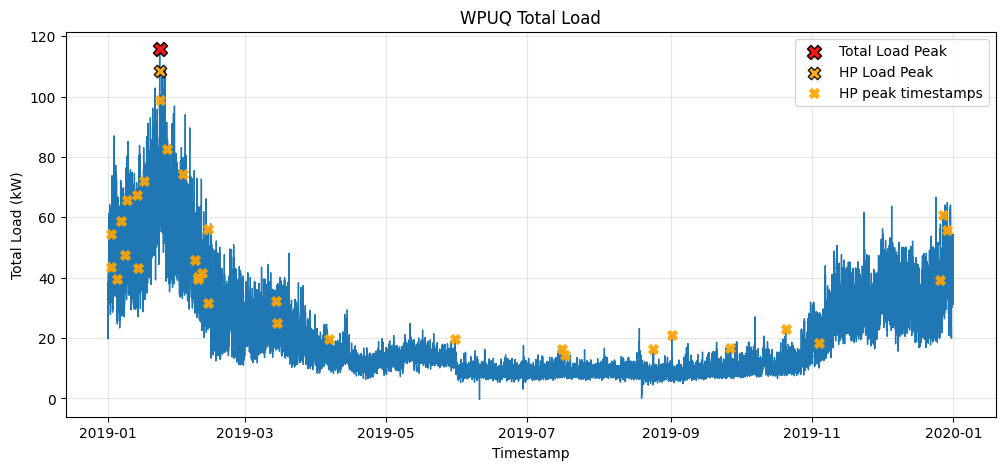

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(wpuq_total_df.index, wpuq_total_df['Load'], lw=1)
plt.xlabel('Timestamp')
plt.ylabel('Total Load (kW)')
plt.title('WPUQ Total Load')

total_peak_ts = wpuq_total_df['Load'].idxmax()
total_peak_val = wpuq_total_df['Load'].max()

plt.scatter(
    total_peak_ts,
    total_peak_val,
    color='red',
    marker='X',
    s=100,
    alpha=0.9,
    edgecolors='black',
    linewidths=1.2,
    zorder=10,
    label='Total Load Peak'
)

hp_peak_ts = wpuq_total_df.index[wpuq_total_hp.idxmax()]
hp_peak_val = wpuq_total_hp.max()

plt.scatter(
    hp_peak_ts,
    hp_peak_val,
    color='orange',
    marker='X',
    s=80,
    alpha=0.9,
    edgecolors='black',
    linewidths=1.0,
    zorder=10,
    label='HP Load Peak'
)

hp_peak_times = []
hp_peak_vals = []

for col in wpuq_hp_df.columns:
    s = wpuq_hp_df[col].fillna(0)
    if s.empty:
        continue
    peak_ts = wpuq_total_df.index[s.idxmax()]
    hp_peak_times.append(peak_ts)
    hp_peak_vals.append(wpuq_total_df.at[peak_ts, 'Load'])

if hp_peak_times:
    plt.scatter(
        hp_peak_times,
        hp_peak_vals,
        color='orange',
        marker='X',
        s=50,
        alpha=0.9,
        edgecolors='orange',
        linewidths=0.8,
        zorder=10,
        label='HP peak timestamps'
    )
    plt.legend()
    plt.grid(alpha=0.3)
else:
    print("No HP peak timestamps aligned with total load index.")
plt.show()

In [ ]:
wpuq_target = {}
wpuq_target['HP_Average'] = np.mean(wpuq_total_hp)
wpuq_target['HP_Peak'] = np.sum([wpuq_hp_df[hid].max() for hid in wpuq_hp_df.columns])
wpuq_target['HP_Simult_Peak'] = wpuq_total_hp.max()
wpuq_target['HP_Capacity_Factor'] = np.mean(wpuq_total_hp) / np.max(wpuq_total_hp)
wpuq_target['HP_Total_Energy'] = wpuq_total_hp.sum() / 4
wpuq_target['HP_Simult_Factor'] = np.max(wpuq_total_hp) / wpuq_target['HP_Peak']

In [ ]:
wpuq_total_no_weekends = wpuq_total_df[wpuq_total_df.index.weekday < 5]
wpuq_weather_no_weekends = wpuq_weather_df[wpuq_weather_df.index.weekday < 5]

dailyLoad = wpuq_total_no_weekends.pivot(index='Date', columns='Time', values='Load').ffill()

dailyWeather = wpuq_weather_no_weekends.pivot(index='Date', columns='Time', values='TEMPERATURE:TOTAL').ffill()

dailyWeather = dailyWeather[dailyWeather.index.isin(dailyLoad.index)]

T_base = HEATING_SEASON_THRESH  # must match training (cell 54)

hdh = np.maximum(0, T_base - dailyWeather)

dailyFeatures = {}
dailyFeatures['Mean'] = dailyLoad.mean(axis=0)
dailyFeatures['Std'] = dailyLoad.std(axis=0)
dailyFeatures['Min'] = dailyLoad.min(axis=0)
dailyFeatures['Max'] = dailyLoad.max(axis=0)
dailyFeatures['Skew'] = dailyLoad.skew(axis=0)
dailyFeatures['Kurtosis'] = dailyLoad.kurtosis(axis=0)
dailyFeatures['Max-Min'] = dailyLoad.max(axis=0) - dailyLoad.min(axis=0)
dailyFeatures['Cov'] = np.array([np.cov(dailyLoad.iloc[:,i], dailyWeather.iloc[:,i])[0][1] 
                                            for i in range(dailyLoad.shape[1])])
dailyFeatures['Corr_Pearson'] = pearsonr(x=dailyLoad, y=dailyWeather, axis=0).statistic
dailyFeatures['Corr_HDH'] = pearsonr(x=dailyLoad, y=hdh, axis=0).statistic

dailyFeaturesDf = pd.DataFrame(dailyFeatures)

# features = {}
# features['Mean'] = dailyFeaturesDf.mean()
# features['Std'] = dailyFeaturesDf.std()
# features['Min'] = dailyFeaturesDf.min()
# features['Max'] = dailyFeaturesDf.max()
# features['Median'] = dailyFeaturesDf.median()

wpuq_features = {}

for key_main in dailyFeaturesDf.keys():
    for key_sub in dailyFeaturesDf.index:
        wpuq_features[f'Feature {key_main}_{key_sub}'] = dailyFeaturesDf[key_main][key_sub]

wpuq_featuresDf = pd.DataFrame.from_dict(wpuq_features, orient='index').T

corr_cols = [c for c in wpuq_featuresDf.columns if 'Corr' in c]
other_cols = [c for c in wpuq_featuresDf.columns if c not in corr_cols]

wpuq_featuresDf[corr_cols] = wpuq_featuresDf[corr_cols].apply(lambda col: col.fillna(col.median()))
wpuq_featuresDf[other_cols] = wpuq_featuresDf[other_cols].fillna(0)


# Peak-load-normalized features (same normalization as HEAPO training data).

peak_load = wpuq_total_no_weekends['Load'].max()
magnitude_keys = ['Mean', 'Std', 'Min', 'Max', 'Max-Min', 'Cov']

for col in list(wpuq_featuresDf.columns):
    if col == 'HP_Peak':
        continue
    if any(col.startswith(f'Feature {k}_') for k in magnitude_keys):
        wpuq_featuresDf[f'{col}_per_peak'] = wpuq_featuresDf[col] / peak_load



C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_40708\2197643736.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wpuq_featuresDf[f'{col}_per_peak'] = wpuq_featuresDf[col] / peak_load
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_40708\2197643736.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wpuq_featuresDf[f'{col}_per_peak'] = wpuq_featuresDf[col] / peak_load
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_40708\2197643736.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

In [ ]:
wpuq_features_windowed_hdd = extract_windowed_hdd_features_from_series(
    load_series=wpuq_total_df["Load"],
    temp_series=wpuq_weather_df["TEMPERATURE:TOTAL"],
    resolution=15,
    T_base=HEATING_SEASON_THRESH,  # must match training (cell 68)
    mild_thresh=10.0,
    cold_thresh=25.0,
    **build_windowed_hdd_kwargs()
)

wpuq_features_windowed_hddDf = pd.DataFrame([wpuq_features_windowed_hdd], index=["WPUQ"])

In [ ]:
x_wpuq, y_wpuq = daily_min_max_heating_season(
    wpuq_weather_df['TEMPERATURE:TOTAL'],
    wpuq_total_df['Load'],
    heating_season_thresh=HEATING_SEASON_THRESH
)

base_load_wpuq, hp_sensitivity_wpuq, T_balance_wpuq, r2_wpuq = fit_hockey_stick(x_wpuq, y_wpuq, T_BALANCE_BOUNDS)

print(f"WPUQ Hockey-Stick Fit: Base Load={base_load_wpuq:.2f} kW, "
      f"HP Sensitivity={hp_sensitivity_wpuq:.3f} kW/°C, "
      f"T_balance={T_balance_wpuq:.2f}°C, R²={r2_wpuq:.3f}")

WPUQ Hockey-Stick Fit: Base Load=0.66 kW, HP Sensitivity=3.991 kW/°C, T_balance=13.61°C, R²=0.507


In [ ]:
wpuq_coeff_hourly = {}

wpuq_coeff_hourly[0] = {}

try:
    temp_h = wpuq_weather_df['TEMPERATURE:TOTAL'].resample('h').mean()
    load_h = wpuq_total_df['Load'].resample('h').mean()

    sm_data = pd.DataFrame({'Temperature': temp_h, 'Total_Load': load_h}).dropna()

    for group_name, hours in hour_groups.items():
        group_data = sm_data[sm_data.index.hour.isin(hours)]

        x = group_data['Temperature'].values
        y = group_data['Total_Load'].values

        if len(x) < MIN_HEATING_DAYS:
            continue

        try:
            base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)
        except Exception:
            continue

        wpuq_coeff_hourly[0][f'{group_name}_BaseLoad'] = base_load
        wpuq_coeff_hourly[0][f'{group_name}_Sensitivity'] = hp_sensitivity
        wpuq_coeff_hourly[0][f'{group_name}_TBalance'] = T_balance
        wpuq_coeff_hourly[0][group_name] = r2

except Exception:
    pass

wpuq_coeff_hourly_df = pd.DataFrame.from_dict(wpuq_coeff_hourly, orient='index')

In [ ]:
wpuq_sensitivities = wpuq_coeff_hourly_df[sensitivity_cols]

c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


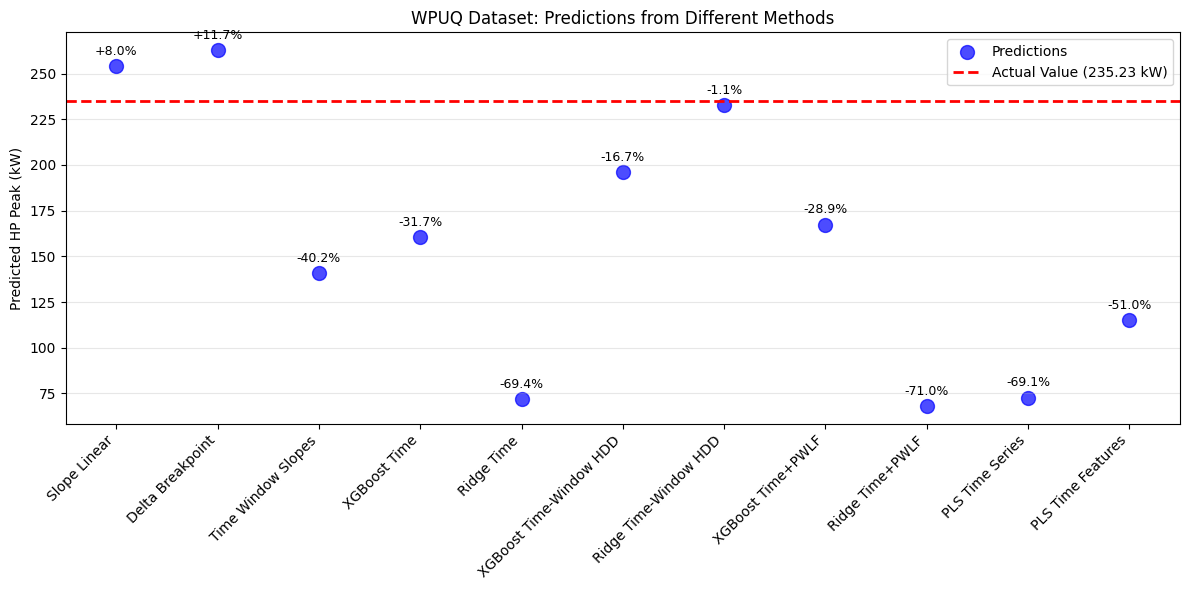

In [ ]:
def make_prediction_series(model, features):
    preds = model.predict(features)
    return clip_non_negative(preds)


slope_pred_wpuq = modelLinSlope.predict(np.array([[hp_sensitivity_wpuq]]))
non_sim_delta_pred_wpuq = nonSimDeltaFit.predict(np.array([[hp_sensitivity_wpuq]]))

sens_time_window_pred_wpuq = sensitivity_model.predict(wpuq_sensitivities)

X_wpuq_time = wpuq_featuresDf

if 'xgb_time_model' in globals():
    xgb_time_pred = make_prediction_series(xgb_time_model, X_wpuq_time)

if 'ridge_time_model' in globals():
    ridge_time_pred = make_prediction_series(ridge_time_model, X_wpuq_time)

xgb_pred_windowed_hdd_wpuq = make_prediction_series(xgb_windowed_hdd_model, wpuq_features_windowed_hddDf)
ridge_pred_windowed_hdd_wpuq = make_prediction_series(ridge_windowed_hdd_model, wpuq_features_windowed_hddDf)

X_wpuq_pwlf = X_wpuq_time.join(pd.DataFrame({
    'Base_Load': base_load_wpuq,
    'HP_Sensitivity': hp_sensitivity_wpuq,
    'T_Balance': T_balance_wpuq,
}, index=X_wpuq_time.index))

if 'xgb_time_hockey_model' in globals():
    xgb_time_hockey_pred = make_prediction_series(xgb_time_hockey_model, X_wpuq_pwlf)

if 'ridge_time_hockey_model' in globals():
    ridge_time_hockey_pred = make_prediction_series(ridge_time_hockey_model, X_wpuq_pwlf)

pls_ts_wpuq = wpuq_total_df['Load'].values
pls_pred_wpuq = pls_ts_model.predict(pls_ts_wpuq.reshape(1, -1)).ravel()               

pls_feat_wpuq = X_wpuq_time.values
pls_feat_pred_wpuq = pls_feat_model.predict(pls_feat_wpuq).ravel()

# Create comparison plot of all methods
fig, ax = plt.subplots(figsize=(12, 6))

methods = [
    ('Slope Linear', slope_pred_wpuq[0]),
    ('Delta Breakpoint', non_sim_delta_pred_wpuq[0]),
    ('Time Window Slopes', sens_time_window_pred_wpuq[0]),
    ('XGBoost Time', xgb_time_pred[0]),
    ('Ridge Time', ridge_time_pred[0]),
    ('XGBoost Time-Window HDD', xgb_pred_windowed_hdd_wpuq[0]),
    ('Ridge Time-Window HDD', ridge_pred_windowed_hdd_wpuq[0]),
    ('XGBoost Time+PWLF', xgb_time_hockey_pred[0]),
    ('Ridge Time+PWLF', ridge_time_hockey_pred[0]),
    ('PLS Time Series', pls_pred_wpuq[0]),
    ('PLS Time Features', pls_feat_pred_wpuq[0])
]

x_pos = range(len(methods))
method_names = [method_name for method_name, _ in methods]
predictions = [prediction for _, prediction in methods]

actual = wpuq_target['HP_Peak']
for x, pred in zip(x_pos, predictions):
    pct_err = 100 * (pred - actual) / actual
    ax.annotate(
        f'{pct_err:+.1f}%',
        (x, pred),
        textcoords='offset points',
        xytext=(0, 6),
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

ax.scatter(x_pos, predictions, s=100, alpha=0.7, color='blue', label='Predictions')
ax.axhline(y=wpuq_target['HP_Peak'], color='red', linestyle='--', linewidth=2, label=f'Actual Value ({wpuq_target["HP_Peak"]:.2f} kW)')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, rotation=45, ha='right')
ax.set_ylabel('Predicted HP Peak (kW)')
ax.set_title('WPUQ Dataset: Predictions from Different Methods')
ax.grid(alpha=0.3, axis='y')
ax.legend()
fig.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# Main settings
# ------------------------------------------------------------

target_col = "HP_Peak"

resolution = 15
T_base_ch = 12.0
T_base_de = 15.0
mild_thresh = 10.0
cold_thresh = 25.0

os.makedirs("data", exist_ok=True)

max_feature_kwargs = dict(
    weekday_only=True,
    include_shape=True,
    include_minmax=True,
    include_quantiles=True,
    include_n_days=False,
    include_corr_features=True,
    include_climate_context=False,
    normalize_by_peak=True,
    stats_for_comparison=["Mean", "Std", "Q50", "Q95", "Max"],
)

swiss_feature_path = "data/X_swiss_windowed_hdd_all.pkl"
german_feature_path = "data/X_german_windowed_hdd_all.pkl"

swiss_df = substations_df

german_df = pd.DataFrame.from_dict({'WPUQ': {"Total_Load": wpuq_total_df['Load'], "Temperature": wpuq_weather_df['TEMPERATURE:TOTAL']}}).T

force_recompute_features = False

if force_recompute_features or not os.path.exists(swiss_feature_path):
    X_swiss_all = extract_windowed_hdd_features_from_entity_dataframe(
        entity_df=swiss_df,
        load_col="Total_Load",
        temp_col="Temperature",
        resolution=resolution,
        T_base=T_base_ch,
        mild_thresh=mild_thresh,
        cold_thresh=cold_thresh,
        show_progress=True,
        **max_feature_kwargs,
    )
    pickle.dump(X_swiss_all, open(swiss_feature_path, "wb"))
else:
    X_swiss_all = pickle.load(open(swiss_feature_path, "rb"))


if force_recompute_features or not os.path.exists(german_feature_path):
    X_german_all = extract_windowed_hdd_features_from_entity_dataframe(
        entity_df=german_df,
        load_col="Total_Load",
        temp_col="Temperature",
        resolution=resolution,
        T_base=T_base_de,
        mild_thresh=mild_thresh,
        cold_thresh=cold_thresh,
        show_progress=True,
        **max_feature_kwargs,
    )
    pickle.dump(X_german_all, open(german_feature_path, "wb"))
else:
    X_german_all = pickle.load(open(german_feature_path, "rb"))

print("Swiss feature matrix:", X_swiss_all.shape)
print("German feature matrix:", X_german_all.shape)

Swiss feature matrix: (2000, 576)
German feature matrix: (1, 576)


In [ ]:
def clean_X(X):
    X = X.copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan)
    return X

In [ ]:
y_swiss = substations_df[[target_col]]

# Align Swiss X/y
swiss_idx = X_swiss_all.index.intersection(y_swiss.index)

X_swiss_all = X_swiss_all.loc[swiss_idx].copy()
y_swiss_model = y_swiss.loc[swiss_idx, target_col].copy()

assert X_swiss_all.index.equals(y_swiss_model.index)

# Clean matrices
X_swiss_all = clean_X(X_swiss_all)
X_german_all = clean_X(X_german_all)

print("Swiss X:", X_swiss_all.shape)
print("Swiss y:", y_swiss_model.shape)
print("German X:", X_german_all.shape)

Swiss X: (2000, 576)
Swiss y: (2000,)
German X: (1, 576)


In [ ]:
def make_fast_ridge(alpha=10.0):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    mask = y_true != 0
    if mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    else:
        mape = np.nan

    r2 = r2_score(y_true, y_pred)

    return rmse, mae, mape, r2

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

fast_results = []

for preset in feature_presets:
    cols = get_feature_columns(X_swiss_all, preset)

    if len(cols) == 0:
        print(f"Skipping {preset}: no columns selected.")
        continue

    X = X_swiss_all[cols].copy()
    model = make_fast_ridge(alpha=10000.0)

    pred_cv = cross_val_predict(
        model,
        X,
        y_swiss_model,
        cv=cv,
        n_jobs=-1
    )

    pred_cv = np.maximum(pred_cv, 0)

    rmse, mae, mape, r2 = compute_metrics(y_swiss_model.values, pred_cv)

    fast_results.append({
        "preset": preset,
        "n_features": len(cols),
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "r2": r2,
    })

fast_results_df = (
    pd.DataFrame(fast_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

fast_results_df

,preset,n_features,rmse,mae,mape,r2
0,mean_q95_only,96,170.262639,127.641595,115.756895,-0.001553
1,comparative_mean_q95,96,170.280968,127.645062,115.791665,-0.001769
2,core,160,170.319952,127.696739,115.801775,-0.002228
3,per_bin_only,336,170.387619,127.778948,115.917376,-0.003024
4,comparative_only,240,170.515660,127.869064,116.088302,-0.004532
5,all,576,170.601053,127.967663,116.117246,-0.005539
6,no_shape_no_corr,480,170.647942,127.985305,116.099253,-0.006092


In [ ]:
top_n = 7
top_presets = fast_results_df["preset"].head(top_n).tolist()

print("Top presets:", top_presets)

def make_ridgecv():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-3, 4, 30), cv=5))
    ])

detailed_results = []

for preset in top_presets:
    cols = get_feature_columns(X_swiss_all, preset)

    X = X_swiss_all[cols].copy()
    model = make_ridgecv()

    pred_cv = cross_val_predict(
        model,
        X,
        y_swiss_model,
        cv=cv,
        n_jobs=-1
    )

    pred_cv = np.maximum(pred_cv, 0)

    rmse, mae, mape, r2 = compute_metrics(y_swiss_model.values, pred_cv)

    detailed_results.append({
        "preset": preset,
        "n_features": len(cols),
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "r2": r2,
    })

detailed_results_df = (
    pd.DataFrame(detailed_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

detailed_results_df

Top presets: ['mean_q95_only', 'comparative_mean_q95', 'core', 'per_bin_only', 'comparative_only', 'all', 'no_shape_no_corr']


,preset,n_features,rmse,mae,mape,r2
0,mean_q95_only,96,170.262639,127.641595,115.756895,-0.001553
1,comparative_mean_q95,96,170.280968,127.645062,115.791665,-0.001769
2,core,160,170.319952,127.696739,115.801775,-0.002228
3,per_bin_only,336,170.387619,127.778948,115.917376,-0.003024
4,comparative_only,240,170.515660,127.869064,116.088302,-0.004532
5,all,576,170.601053,127.967663,116.117246,-0.005539
6,no_shape_no_corr,480,170.647942,127.985305,116.099253,-0.006092


In [ ]:
best_preset = detailed_results_df.iloc[0]["preset"]
best_cols = get_feature_columns(X_swiss_all, best_preset)

print("Best preset:", best_preset)
print("Number of selected features:", len(best_cols))

final_model = make_ridgecv()

final_model.fit(
    X_swiss_all[best_cols],
    y_swiss_model
)

selected_alpha = final_model.named_steps["ridge"].alpha_
print("Selected Ridge alpha:", selected_alpha)

# Align German features to Swiss columns
X_german_final = X_german_all.reindex(columns=X_swiss_all.columns)
X_german_final = X_german_final[best_cols]

german_pred = final_model.predict(X_german_final)
german_pred = np.maximum(german_pred, 0)

german_pred_series = pd.Series(
    german_pred,
    index=X_german_final.index,
    name="Predicted_HP_Peak"
)

german_pred_series

Best preset: mean_q95_only
Number of selected features: 96
Selected Ridge alpha: 10000.0


0    259.641509
Name: Predicted_HP_Peak, dtype: float64

In [ ]:
X_swiss_train = X_swiss_all.loc[train_idx]
y_swiss_train = y_swiss_model.loc[train_idx]

xgb_best_cols_model, xgb_best_cols_hyper = tune_and_train_xgb(X_swiss_train[get_feature_columns(X_swiss_train, best_preset)], y_swiss_train)

xgb_german_pred = xgb_best_cols_model.predict(X_german_final)
xgb_german_pred = np.maximum(xgb_german_pred, 0)

xgb_german_pred_series = pd.Series(
    xgb_german_pred,
    index=X_german_final.index,
    name="Predicted_HP_Peak"
)

xgb_german_pred_series

 45%|████▌     | 68/150 [00:11<00:13,  6.04trial/s, best loss: 32644.836337605884]
Hyperopt tuning: 11.3s
Final fit: 0.5s


0    326.330658
Name: Predicted_HP_Peak, dtype: float32

In [ ]:
y_german = pd.DataFrame(wpuq_target, index=[0])

german_idx = X_german_final.index.intersection(y_german.index)

if len(german_idx) == 0:
    print("No matching German target index found.")
else:
    actual = y_german.loc[german_idx, target_col].iloc[0]
    ridge_predicted = german_pred_series.loc[german_idx].iloc[0]
    xgb_predicted = xgb_german_pred_series.loc[german_idx].iloc[0]

    ridge_abs_error = abs(ridge_predicted - actual)
    xgb_abs_error = abs(xgb_predicted - actual)
    
    ridge_pct_error = ridge_abs_error / actual * 100 if actual != 0 else np.nan
    xgb_pct_error = xgb_abs_error / actual * 100 if actual != 0 else np.nan

    print(f"German actual {target_col}:    {actual:.2f} kW")
    print(f"German Ridge predicted {target_col}: {ridge_predicted:.2f} kW")
    print(f"German Ridge absolute error:   {ridge_abs_error:.2f} kW")
    print(f"German Ridge percentage error: {ridge_pct_error:.2f}%")
    
    print(f"German XGB predicted {target_col}: {xgb_predicted:.2f} kW")
    print(f"German XGB absolute error:     {xgb_abs_error:.2f} kW")
    print(f"German XGB percentage error:     {xgb_pct_error:.2f}%")

German actual HP_Peak:    235.23 kW
German Ridge predicted HP_Peak: 259.64 kW
German Ridge absolute error:   24.41 kW
German Ridge percentage error: 10.38%
German XGB predicted HP_Peak: 326.33 kW
German XGB absolute error:     91.10 kW
German XGB percentage error:     38.73%


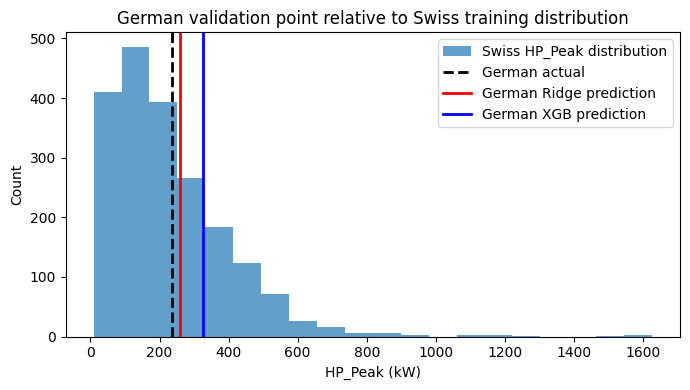

In [ ]:
if len(german_idx) > 0:
    plt.figure(figsize=(7, 4))

    plt.hist(
        y_swiss_model,
        bins=20,
        alpha=0.7,
        label="Swiss HP_Peak distribution"
    )

    plt.axvline(
        actual,
        color="black",
        linestyle="--",
        linewidth=2,
        label="German actual"
    )

    plt.axvline(
        ridge_predicted,
        color="red",
        linestyle="-",
        linewidth=2,
        label="German Ridge prediction"
    )

    plt.axvline(
        xgb_predicted,
        color="blue",
        linestyle="-",
        linewidth=2,
        label="German XGB prediction"
    )

    plt.xlabel("HP_Peak (kW)")
    plt.ylabel("Count")
    plt.title("German validation point relative to Swiss training distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

# FeederBW

In [ ]:
from pathlib import Path

feederbw_dir = Path('data/FeederBW')
measurement_dir = feederbw_dir / 'feeder_measurement_data_001-040' / 'feeder_measurement_data_001-040'

feeder_metadata_df = pd.read_csv(feederbw_dir / 'feeder_metadata.csv')
weather_data_df = pd.read_parquet(feederbw_dir / 'weather_data.parquet')

feeder_measurement_dfs = {}
for file_path in sorted(measurement_dir.rglob('feeder_*.parquet')):
    feeder_id = int(file_path.stem.split('_')[-1])
    feeder_measurement_dfs[feeder_id] = pd.read_parquet(file_path)

feeder_measurement_ids = sorted(feeder_measurement_dfs.keys())

feeder_metadata_df['date'] = pd.to_datetime(feeder_metadata_df['date'])
feeder_metadata_2024_df = feeder_metadata_df[
    (feeder_metadata_df['date'] >= '2024-01-01') &
    (feeder_metadata_df['date'] < '2025-01-01')
].copy()
feeder_metadata_2024_subset = feeder_metadata_2024_df[feeder_metadata_2024_df['feeder'].isin(feeder_measurement_ids)].copy()

feeder_metadata_start_2024_df = (
    feeder_metadata_2024_subset.sort_values('date')
    .drop_duplicates('feeder', keep='first')
    .set_index('feeder')
)
feeder_metadata_end_2024_df = (
    feeder_metadata_2024_subset.sort_values('date')
    .drop_duplicates('feeder', keep='last')
    .set_index('feeder')
)
feeder_metadata_static_all_df = (
    feeder_metadata_df.sort_values('date')
    .drop_duplicates('feeder', keep='first')
    .set_index('feeder')
)
feeder_metadata_static_last_all_df = (
    feeder_metadata_df.sort_values('date')
    .drop_duplicates('feeder', keep='last')
    .set_index('feeder')
)
feeder_metadata_static_df = feeder_metadata_start_2024_df.combine_first(feeder_metadata_static_all_df)

metadata_2024_changes = []
metadata_cols = [c for c in feeder_metadata_2024_subset.columns if c not in {'feeder', 'date'}]
for feeder_id, feeder_meta_group in feeder_metadata_2024_subset.groupby('feeder'):
    changed_cols = [
        col for col in metadata_cols
        if feeder_meta_group[col].nunique(dropna=False) > 1
    ]
    if changed_cols:
        metadata_2024_changes.append({
            'feeder': feeder_id,
            'n_records_2024': len(feeder_meta_group),
            'changed_columns': changed_cols,
            'heat_pumps_kW_start': feeder_metadata_start_2024_df.loc[feeder_id, 'heat_pumps_kW'] if feeder_id in feeder_metadata_start_2024_df.index else np.nan,
            'heat_pumps_kW_end': feeder_metadata_end_2024_df.loc[feeder_id, 'heat_pumps_kW'] if feeder_id in feeder_metadata_end_2024_df.index else np.nan,
        })

feeder_metadata_changes_2024_df = pd.DataFrame(metadata_2024_changes)

feeder_rows = {}
for feeder_id, feeder_df in feeder_measurement_dfs.items():
    feeder_df = feeder_df.copy()
    feeder_df['timestamp_UTC'] = pd.to_datetime(feeder_df['timestamp_UTC'], utc=True)
    feeder_df = feeder_df[(feeder_df['timestamp_UTC'] >= pd.Timestamp('2024-01-01', tz='UTC')) &
                          (feeder_df['timestamp_UTC'] < pd.Timestamp('2025-01-01', tz='UTC'))]
    feeder_df = feeder_df.sort_values('timestamp_UTC').set_index('timestamp_UTC')

    weather_df = weather_data_df[weather_data_df['feeder'] == feeder_id].copy()
    weather_df['timestamp_UTC'] = pd.to_datetime(weather_df['timestamp_UTC'], utc=True)
    weather_df = weather_df[(weather_df['timestamp_UTC'] >= pd.Timestamp('2024-01-01', tz='UTC')) &
                            (weather_df['timestamp_UTC'] < pd.Timestamp('2025-01-01', tz='UTC'))]
    weather_df = weather_df.sort_values('timestamp_UTC').set_index('timestamp_UTC')

    load_15min = feeder_df['active_power_kW'].resample('15min').mean().rename('Total_Load')
    temperature_15min = (
        weather_df['air_temperature_C']
        .resample('15min')
        .interpolate(method='time')
        .ffill()
        .bfill()
        .rename('Temperature')
    )

    aligned = pd.concat([load_15min, temperature_15min], axis=1, join='inner').dropna()
    if aligned.empty:
        continue

    if feeder_id in feeder_metadata_start_2024_df.index:
        start_row = feeder_metadata_start_2024_df.loc[feeder_id]
    elif feeder_id in feeder_metadata_static_all_df.index:
        start_row = feeder_metadata_static_all_df.loc[feeder_id]
    else:
        start_row = pd.Series(dtype=float)

    if feeder_id in feeder_metadata_end_2024_df.index:
        end_row = feeder_metadata_end_2024_df.loc[feeder_id]
    elif feeder_id in feeder_metadata_static_last_all_df.index:
        end_row = feeder_metadata_static_last_all_df.loc[feeder_id]
    else:
        end_row = pd.Series(dtype=float)

    row = {
        'feeder': feeder_id,
        'substation': start_row.get('substation', np.nan),
        'housing_units_count': start_row.get('housing_units_count', np.nan),
        'industry_and_commerce_count': start_row.get('industry_and_commerce_count', np.nan),
        'heat_pumps_kW_start': start_row.get('heat_pumps_kW', np.nan),
        'heat_pumps_kW_end': end_row.get('heat_pumps_kW', np.nan),
        'heat_pumps_kW_change': (
            end_row.get('heat_pumps_kW', np.nan) - start_row.get('heat_pumps_kW', np.nan)
            if pd.notna(start_row.get('heat_pumps_kW', np.nan)) and pd.notna(end_row.get('heat_pumps_kW', np.nan))
            else np.nan
        ),
        'Total_Load': aligned['Total_Load'],
        'Temperature': aligned['Temperature'],
    }
    feeder_rows[feeder_id] = row

feederbw_df = pd.DataFrame.from_dict(feeder_rows, orient='index')
feederbw_df.index.name = 'Feeder_ID'

print(f"FeederBW rows kept for 2024: {len(feederbw_df)}")
print(f"Feeders with metadata changes in 2024: {len(feeder_metadata_changes_2024_df)}")
feeder_metadata_changes_2024_df
feederbw_df

FeederBW rows kept for 2024: 40
Feeders with metadata changes in 2024: 26


,feeder,substation,housing_units_count,industry_and_commerce_count,heat_pumps_kW_start,heat_pumps_kW_end,heat_pumps_kW_change,Total_Load,Temperature
Feeder_ID,,,,,,,,,
1,1,1,70,11,2.10,2.10,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 43....,timestamp_UTC 2024-01-01 00:00:00+00:00 2.5...
2,2,2,22,1,36.43,36.43,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 29....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.3...
3,3,3,68,0,0.00,12.00,12.0,timestamp_UTC 2024-01-01 00:00:00+00:00 10....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.0...
4,4,4,28,4,13.00,13.00,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 16....,timestamp_UTC 2024-01-01 00:00:00+00:00 6.3...
5,5,5,62,0,0.00,0.00,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 13....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.0...
6,6,6,40,1,14.72,14.72,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 20....,timestamp_UTC 2024-01-01 00:00:00+00:00 2.8...
7,7,7,27,3,2.89,2.89,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 13....,timestamp_UTC 2024-01-01 00:00:00+00:00 3.4...
8,8,8,61,0,34.36,34.36,0.0,timestamp_UTC 2024-01-01 00:00:00+00:00 30....,timestamp_UTC 2024-01-01 00:00:00+00:00 5.0...
9,9,9,72,2,25.89,29.29,3.4,timestamp_UTC 2024-01-01 00:00:00+00:00 26....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.6...


In [ ]:
feederbw_df.describe()

,feeder,substation,housing_units_count,industry_and_commerce_count,heat_pumps_kW_start,heat_pumps_kW_end,heat_pumps_kW_change
count,40.000000,40.000000,40.0000,40.000000,40.000000,40.000000,40.000000
mean,20.500000,18.900000,37.2500,2.975000,7.904500,9.189500,1.285000
std,11.690452,10.601887,24.4695,3.415556,11.620348,12.278841,3.465326
min,1.000000,1.000000,0.0000,0.000000,0.000000,0.000000,0.000000
25%,10.750000,10.750000,20.2500,0.000000,0.000000,0.000000,0.000000
50%,20.500000,18.500000,33.0000,1.500000,2.845000,4.450000,0.000000
75%,30.250000,28.000000,54.2500,5.000000,10.482500,12.492500,0.000000
max,40.000000,37.000000,102.0000,12.000000,44.500000,44.500000,15.900000


In [ ]:
feederbw_no_change_df = feederbw_df[feederbw_df['heat_pumps_kW_change'] == 0][['heat_pumps_kW_start', 'Total_Load','Temperature']].rename(columns={'heat_pumps_kW_start': 'HP_Peak'})
feederbw_no_change_df

,HP_Peak,Total_Load,Temperature
Feeder_ID,,,
1,2.10,timestamp_UTC 2024-01-01 00:00:00+00:00 43....,timestamp_UTC 2024-01-01 00:00:00+00:00 2.5...
2,36.43,timestamp_UTC 2024-01-01 00:00:00+00:00 29....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.3...
4,13.00,timestamp_UTC 2024-01-01 00:00:00+00:00 16....,timestamp_UTC 2024-01-01 00:00:00+00:00 6.3...
5,0.00,timestamp_UTC 2024-01-01 00:00:00+00:00 13....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.0...
6,14.72,timestamp_UTC 2024-01-01 00:00:00+00:00 20....,timestamp_UTC 2024-01-01 00:00:00+00:00 2.8...
7,2.89,timestamp_UTC 2024-01-01 00:00:00+00:00 13....,timestamp_UTC 2024-01-01 00:00:00+00:00 3.4...
8,34.36,timestamp_UTC 2024-01-01 00:00:00+00:00 30....,timestamp_UTC 2024-01-01 00:00:00+00:00 5.0...
13,9.72,timestamp_UTC 2024-01-01 00:00:00+00:00 22....,timestamp_UTC 2024-01-01 00:00:00+00:00 5.4...
15,18.00,timestamp_UTC 2024-01-01 00:00:00+00:00 10....,timestamp_UTC 2024-01-01 00:00:00+00:00 4.0...


In [ ]:
feederbw_windowed_hdd_df = extract_windowed_hdd_features_from_entity_dataframe(
    entity_df=feederbw_no_change_df,
    load_col="Total_Load",
    temp_col="Temperature",
    resolution=15,
    T_base=15.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    **build_windowed_hdd_kwargs(),
)

Extracting windowed HDD-binned features: 100%|██████████| 33/33 [00:04<00:00,  8.15it/s]


In [ ]:
xgb_pred_windowed_hdd_fbw = make_prediction_series(xgb_windowed_hdd_model, feederbw_windowed_hdd_df)
ridge_pred_windowed_hdd_fbw = make_prediction_series(ridge_windowed_hdd_model, feederbw_windowed_hdd_df)

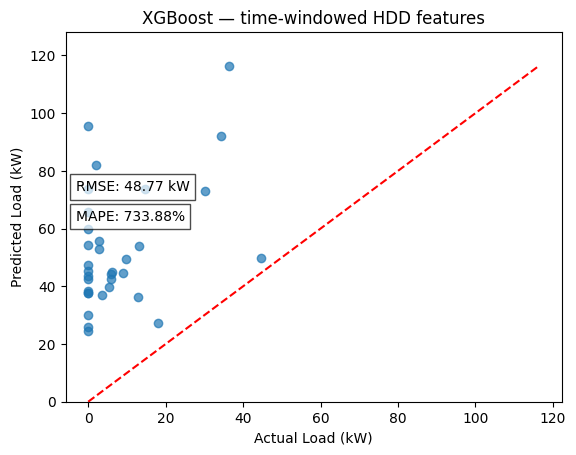

In [ ]:
fig, ax, rmse, mape = plot_prediction_scatter(
    feederbw_no_change_df['HP_Peak'], xgb_pred_windowed_hdd_fbw, title='XGBoost — time-windowed HDD features')

plt.show()

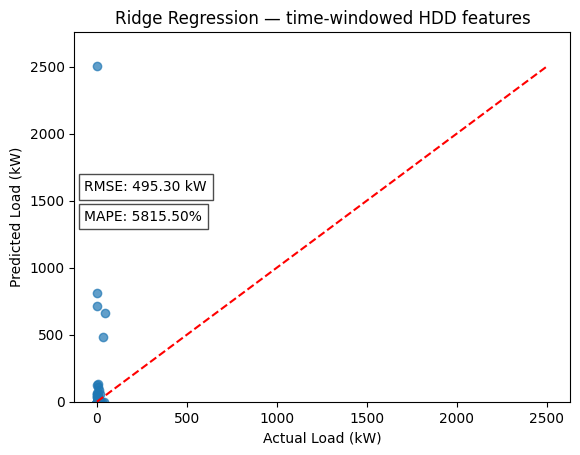

In [ ]:
fig, ax, rmse, mape = plot_prediction_scatter(
    feederbw_no_change_df['HP_Peak'], ridge_pred_windowed_hdd_fbw, title='Ridge Regression — time-windowed HDD features')

plt.show()

## Corrected Capacity Pipeline (Swiss training + cross-dataset transfer)

Reworked windowed-HDD HP installed-capacity model. Feature extraction and the
pipeline helpers live in `hp_capacity.py`. Fixes over the sections above:
household-disjoint synthetic substations (honest internal test), a robust
99.9th-percentile capacity target, scale-free features plus explicit size
anchors, and a cross-validated XGBoost. National HDD bases: 12 degC (CH),
15 degC (DE).

Regenerate substations with `regenerate_substations_pooled.py`; retrain and
save the model with `train_swiss_capacity.py`.

In [ ]:
import pickle
import hp_capacity as hc
import hp_pools as hpp

CAP_FEATURE_KWARGS = dict(
    resolution=15, mild_thresh=10.0, cold_thresh=25.0, weekday_only=True,
    include_shape=False, include_minmax=True, include_quantiles=True,
    include_n_days=False, include_corr_features=False,
    include_climate_context=False, normalize_by_peak=True)
T_BASE_CH, T_BASE_DE = 12.0, 15.0   # national HDD base temperatures

sub_pooled  = pickle.load(open('data/substations_data_pooled.pkl', 'rb'))
X_swiss_raw = pickle.load(open('data/_X_swiss_pooled.pkl', 'rb'))
_M = pickle.load(open('models/capacity_swiss.pkl', 'rb'))
cap_ridge, cap_xgb = _M['ridge'], _M['xgb']
cap_scalefree, cap_feature_cols, cap_train_median = (
    _M['scalefree_cols'], _M['feature_cols'], _M['train_median'])

X_swiss = hc.capacity_feature_matrix(
    X_swiss_raw, cap_scalefree,
    size=sub_pooled['size'], peak=sub_pooled['Total_Load'].apply(hc.series_peak)
)[cap_feature_cols]
y_swiss = sub_pooled['HP_Peak'].astype(float)
te = sub_pooled.index[sub_pooled['split'] == 'test']

for nm, mdl, fill in [('Ridge', cap_ridge, False), ('XGB (tuned)', cap_xgb, True)]:
    Xte = X_swiss.loc[te].fillna(cap_train_median) if fill else X_swiss.loc[te]
    m = hc.compute_metrics(y_swiss.loc[te].to_numpy(), hc.clip_non_negative(mdl.predict(Xte)))
    print(f"internal test (unseen households) {nm:11s}: "
          f"RMSE {m['rmse']:.1f} kW | MAPE {m['mape']:.0f}% | R2 {m['r2']:.3f}")

### Swiss → WPUQ transfer (HP-rich German dataset)

All 37 WPUQ houses have submetered heat pumps, so this is a fair cross-country
transfer test on a population resembling the Swiss synthetics -- unlike
FeederBW, whose net-load response is dominated by storage/resistive heaters.
Many synthetic substations are drawn over the trained size/penetration range
and predicted with the tuned Swiss model.

In [ ]:
wpuq_pool = hpp.build_pool_wpuq(verbose=False)
wp = hc.build_wpuq_substations(wpuq_pool, n=400, size_range=(10, 37), pen_max=0.5, seed=7)

Xw_raw = hc.extract_windowed_hdd_features_from_entity_dataframe(
    wp, T_base=T_BASE_DE, use_entity_index=True, **CAP_FEATURE_KWARGS)
Xw = hc.capacity_feature_matrix(
    Xw_raw, cap_scalefree, size=wp['size'],
    peak=wp['Total_Load'].apply(hc.series_peak))[cap_feature_cols]
yw = wp['HP_Peak'].to_numpy()
pred_w = hc.clip_non_negative(cap_xgb.predict(Xw.fillna(cap_train_median)))
mw = hc.compute_metrics(yw, pred_w)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(yw, pred_w, alpha=0.4, s=18)
lim = max(yw.max(), pred_w.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', label='ideal')
ax.set_xlabel('Actual HP capacity (kW)'); ax.set_ylabel('Predicted HP capacity (kW)')
ax.set_title(f"Swiss → WPUQ (tuned XGB): R2={mw['r2']:.2f}  "
             f"MAPE={mw['mape']:.0f}%  RMSE={mw['rmse']:.1f} kW")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('Swiss → WPUQ transfer:', {k: round(v, 3) for k, v in mw.items()})

### In-distribution: electric-heating capacity within FeederBW

All 200 FeederBW feeders are downloaded; **126 (across 88 substations)** are
usable for capacity estimation (electric heating registered, stable over 2024,
housing units known). Heat pumps are a median 11 % of electric heating and only
~10 feeders are HP-dominant, so HP-only estimation stays data-starved; the
net-load temperature response instead measures **total electric-heating
capacity** (HP + storage + resistive + flow + hot-water). Capacity is estimated
with substation-grouped cross-validation, so feeders on the same substation
never split across folds.

**Honest finding.** On real feeders the aggregate temperature response is only a
weak predictor of installed electric-heating capacity (windowed-HDD grouped-CV
**R2 ~ 0.15**, MAPE ~140 %; sensitivity-capacity correlation ~ 0.33). The much
higher R2 seen on the first 23-feeder batch was small-sample optimism -- it does
not hold at n=126. Storage heaters charge at night decoupled from instantaneous
temperature, and EV/PV load further blurs the response, so registered capacity
is not cleanly recoverable from the aggregated heating-degree signal. The
capacity model works on HP-rich synthetic/WPUQ populations (above) but degrades
on this low-penetration, storage-heater-dominated population.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import GroupKFold, cross_val_predict

fbw_df, fbw_static, fbw_end = hc.load_feederbw()
fbw_tgt = hc.feederbw_capacity_frame(fbw_df.index, fbw_static, fbw_end)
usable = fbw_tgt[(fbw_tgt.ElecHeat_kW > 0) & fbw_tgt.elecheat_stable & (fbw_tgt.housing > 0)].index
print(f"{len(fbw_df)} downloaded feeders | {len(usable)} usable for ElecHeat estimation "
      f"| HP-dominant: {(fbw_tgt.loc[usable, 'HP_frac'] >= 0.5).sum()}")

Xf_raw = hc.extract_windowed_hdd_features_from_entity_dataframe(
    fbw_df.loc[usable], T_base=T_BASE_DE, use_entity_index=True,
    show_progress=False, **CAP_FEATURE_KWARGS)
Xf = Xf_raw.apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
Xf['Feature Scale_peak'] = fbw_df.loc[usable, 'Total_Load'].apply(hc.series_peak)
Xf['Feature Scale_size'] = fbw_tgt.loc[usable, 'housing']
y_eh = fbw_tgt.loc[usable, 'ElecHeat_kW'].astype(float)
groups = fbw_tgt.loc[usable, 'substation'].astype(int)

pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                 ('sc', StandardScaler()),
                 ('sel', SelectKBest(f_regression, k=6)),
                 ('r', RidgeCV(alphas=np.logspace(-2, 4, 25)))])
gkf = GroupKFold(n_splits=min(5, groups.nunique()))
pred_f = np.maximum(cross_val_predict(pipe, Xf, y_eh, cv=gkf, groups=groups), 0)
mf = hc.compute_metrics(y_eh.to_numpy(), pred_f)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_eh, pred_f, alpha=0.7, s=40)
lim = max(y_eh.max(), pred_f.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', label='ideal')
ax.set_xlabel('Actual electric-heating capacity (kW)')
ax.set_ylabel('Predicted (kW)')
ax.set_title(f"FeederBW in-distribution (grouped CV, n={len(usable)}): "
             f"R2={mf['r2']:.2f}  MAPE={mf['mape']:.0f}%")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('FeederBW in-distribution ElecHeat:', {k: round(v, 3) for k, v in mf.items()})

## Model benchmark on the capacity features

Seven regressors, each **hyperparameter-tuned** by 5-fold CV on the
household-disjoint **train** split (LinearRegression has no hyperparameters; the
Keras FFNN's architecture / learning-rate / L2 are CV-searched under
op-determinism), then scored on (a) the held-out **test** split (unseen
households) and (b) a **synthetic WPUQ** transfer set. Generated by
`benchmark_capacity_models.py` -> `data/capacity_model_benchmark.csv`.

**Training pool = HEAPO synthetic substations, replacement draws, BALANCED
design.** `regenerate_substations_pooled.py` now builds a factorial grid: 10
penetration levels (10-100%) x 12 sizes (10-120 dwellings) x 9 replicates x 2
splits = 2160 substations, so every penetration level (216 each) and every size
(180 each) holds an equal number of substations. Target HP_Peak spans ~3-962 kW.

**Takeaways.** XGBoost is the decisive winner: test R2 0.93 and the strongest
cross-dataset transfer obtained anywhere in this study (synthetic-WPUQ R2 0.73),
helped by the balanced low-penetration coverage. Every other model transfers
negatively -- unbounded linear extrapolation off the manifold, and the tuned
FFNN remains weak/unstable (test R2 ~0.32; its CV search reaches cv_r2 0.81 but
that is inflated by within-train household leakage, the same reason NN
architecture selection is unreliable on this 81-household dataset). Tree
gradient-boosting is the right tool.

In [ ]:
import matplotlib.pyplot as plt
bench = pd.read_csv('data/capacity_model_benchmark.csv').sort_values('test_r2', ascending=False).reset_index(drop=True)
show = bench[['model', 'test_r2', 'test_rmse', 'test_mape', 'wpuq_r2', 'wpuq_rmse', 'wpuq_mape']]
print(show.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

fig, ax = plt.subplots(figsize=(9, 4.6))
x = np.arange(len(bench)); w = 0.38
ax.bar(x - w/2, bench['test_r2'], w, label='Test (unseen households)', color='#2c7fb8')
ax.bar(x + w/2, bench['wpuq_r2'], w, label='Swiss -> WPUQ transfer', color='#de2d26')
ax.axhline(0, color='k', lw=0.8)
for xi, tv, wv in zip(x, bench['test_r2'], bench['wpuq_r2']):
    ax.text(xi - w/2, tv + 0.02, f'{tv:.2f}', ha='center', va='bottom', fontsize=8)
    ax.text(xi + w/2, wv + (0.02 if wv >= 0 else -0.02), f'{wv:.2f}',
            ha='center', va='bottom' if wv >= 0 else 'top', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(bench['model'], rotation=20, ha='right')
ax.set_ylabel('R2'); ax.set_ylim(-1.5, 1.0)
ax.set_title('HP capacity estimation: model benchmark')
ax.legend(loc='lower left'); ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

### Deploying on the REAL WPUQ feeder (single true aggregate)

Swiss-trained models applied to the one **real WPUQ feeder** (37 houses, all
with heat pumps; true installed capacity 238.5 kW), balanced/tuned build.

**Result.** XGBoost and SVR both land at ~129 kW (-46%); the linear models
overshoot (+170..+307%); the tuned FFNN overshoots (+47%). Strikingly, the
**train-median baseline (145 kW, -39%) beats every model** on this single point.

**Why the models cannot reach 238.5 kW here.** This build is **HEAPO-only**
(per-HP robust peak median ~4.8 kW), while every WPUQ heat pump is larger
(~6.4 kW/house). The real feeder's peak-normalised shape signature therefore
maps, in a HEAPO-trained model, to a *lower* capacity -- a **density mismatch**
that no amount of penetration coverage, balancing, or tuning can close, because
the training households simply do not reach WPUQ per-unit power. (Complementing
with the Swiss cohort raises median per-HP power toward 6.3 kW but, tested
separately, its no-replacement composition sparsely samples the high-capacity
regime and did not help either.)

**Bottom line.** In-distribution and on the robust synthetic-WPUQ transfer the
tuned XGBoost is excellent (0.93 / 0.73). Absolute-kW deployment on a *single*
real feeder whose per-HP power exceeds the training population is not
recoverable from these models -- the limiting factor is the small, low-power set
of distinct submetered HP households, not the model or the sampling design.

In [ ]:
import matplotlib.pyplot as plt
rf = pd.read_csv('data/capacity_wpuq_real_feeder.csv').sort_values('pred_kW')
true = rf['true_kW'].iloc[0]
print(f"REAL WPUQ feeder: TRUE installed HP capacity = {true:.1f} kW
")
print(rf[['method','pred_kW','err_kW','abs_pct_err']].to_string(index=False, float_format=lambda v: f'{v:.1f}'))

colors = ['#7a7a7a' if m.startswith('baseline')
          else ('#de2d26' if abs(p-true)/true > 0.6 else '#2c7fb8')
          for m, p in zip(rf['method'], rf['pred_kW'])]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
yy = np.arange(len(rf))
ax.barh(yy, rf['pred_kW'], color=colors)
ax.axvline(true, color='k', ls='--', lw=1.5, label=f'TRUE = {true:.0f} kW')
for i, p in enumerate(rf['pred_kW']):
    ax.text(p + 6, i, f'{p:.0f} ({(p-true)/true*100:+.0f}%)', va='center', fontsize=8)
ax.set_yticks(yy); ax.set_yticklabels(rf['method']); ax.set_xlim(0, 600)
ax.set_xlabel('Predicted installed HP capacity (kW)')
ax.set_title('Swiss-trained models on the REAL WPUQ feeder (~100% HP penetration)')
ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

## XGBoost feature selection (minimise error on unseen substations)

`feature_select_xgb.py` selects the feature subset that lowers the error on
**unseen** substations. Selection is driven entirely by 5-fold CV on the
household-disjoint **train** split (each held-out fold = unseen substations) --
the test split is never used to choose features. Steps: (1) rank the 274
features by CV-averaged XGBoost gain importance; (2) sweep the number of
top-ranked features k and score each by CV RMSE; (3) pick k by the **1-SE rule**
(smallest k within one standard error of the best CV RMSE, for parsimony);
(4) re-tune XGBoost on the selected set and report honest test / WPUQ / real
numbers.

**Result: 274 -> 60 features improves everything on unseen data.**

| feature set | n | test RMSE | test R2 | synthetic-WPUQ R2 | real feeder |
|---|---|---|---|---|---|
| all features | 274 | 53.2 kW | 0.919 | 0.639 | 157.6 kW |
| **selected (1-SE)** | **60** | **44.0 kW** | **0.945** | **0.735** | **194.8 kW (-18%)** |

Test RMSE falls 17%, in-distribution R2 rises to 0.945, cross-dataset transfer
to 0.735, and the real-feeder error shrinks from -34% to -18% -- dropping 214
noisy features reduces variance and generalises better. The surviving features
are dominated by **extreme-cold and extreme-warm windowed-HDD ratios /
normalised deltas plus the two size anchors** (peak load, dwelling count): the
cold-severity load response and feeder scale carry the capacity signal, the rest
was noise. Selected list saved to `models/xgb_selected_features.json`.

In [ ]:
import matplotlib.pyplot as plt, json
fs = json.load(open('models/xgb_selected_features.json'))
cv = pd.read_csv('data/xgb_feature_selection_cv.csv')
kstar = fs['k_star']

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].errorbar(cv['k'], cv['cv_rmse_mean'], yerr=cv['cv_rmse_std'], marker='o',
               capsize=3, color='#2c7fb8')
j = cv['cv_rmse_mean'].idxmin()
ax[0].axhline(cv.loc[j,'cv_rmse_mean']+cv.loc[j,'cv_rmse_std'], color='#de2d26', ls=':', label='best + 1 SE')
ax[0].axvline(kstar, color='#238b45', ls='--', lw=1.2, label=f'selected k*={kstar}')
ax[0].set_xscale('log'); ax[0].set_xlabel('number of top-ranked features k')
ax[0].set_ylabel('CV RMSE on unseen substations (kW)')
ax[0].set_title('Feature-set size vs CV error'); ax[0].legend(); ax[0].grid(alpha=0.3)

labels = ['test RMSE (kW)', 'test R2', 'WPUQ R2']
allv = [fs['test_all']['rmse'], fs['test_all']['r2'], fs['wpuq_all']['r2']]
selv = [fs['test_sel']['rmse'], fs['test_sel']['r2'], fs['wpuq_sel']['r2']]
x = np.arange(len(labels)); w = 0.38
ax[1].bar(x-w/2, allv, w, label='all 274', color='#8c96c6')
ax[1].bar(x+w/2, selv, w, label=f'selected {kstar}', color='#238b45')
for i,(a,s) in enumerate(zip(allv,selv)):
    ax[1].text(i-w/2, a, f'{a:.2f}', ha='center', va='bottom', fontsize=8)
    ax[1].text(i+w/2, s, f'{s:.2f}', ha='center', va='bottom', fontsize=8)
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_title('All vs selected features (unseen data)'); ax[1].legend(); ax[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print('selected', kstar, 'features; top 8:', fs['selected_features'][:8])

## XGBoost vs hockey-stick: MAPE and confidence intervals

Head-to-head of the two capacity estimators on the Swiss **test** split (unseen
substations), the **synthetic WPUQ** substations, and the single **real WPUQ
feeder**. XGBoost uses the 60 CV-selected features; the hockey-stick method fits
a load-vs-temperature hockey stick per substation (daily min-temp / max-load,
heating season), takes the slope (HP_Sensitivity), and maps slope -> HP_Peak with
a linear regression fitted on train. Run by `evaluate_xgb_hockey_ci.py`.

Confidence intervals: **95% bootstrap CI on MAPE** (2000 resamples, where n>1),
and a per-estimate **90% prediction interval** -- XGBoost via quantile regression
(q05-q95), hockey-stick via the OLS prediction-interval formula -- reported as
coverage / width for the multi-substation sets, and as the interval itself for
the single real feeder.

| set | method | n | MAPE / \|err\| (95% CI) | RMSE | R2 | 90% PI |
|---|---|---|---|---|---|---|
| Swiss test | **XGBoost** | 1080 | **18.8% [17.2, 20.4]** | 44.0 | 0.945 | cov 87%, w 282 |
| Swiss test | hockey-stick | 1080 | 38.1% [34.1, 42.2] | 78.1 | 0.825 | cov 89%, w 200 |
| synthetic WPUQ | **XGBoost** | 376 | **40.3% [35.4, 45.5]** | 14.1 | 0.705 | cov 93%, w 221 |
| synthetic WPUQ | hockey-stick | 376 | 144.3% [127, 162] | 28.6 | -0.208 | cov 100%, w 173 |
| real WPUQ feeder | XGBoost | 1 | 18% (195 kW) | 43.7 | -- | [54, 266], INSIDE |
| real WPUQ feeder | **hockey-stick** | 1 | **2% (234 kW)** | 4.6 | -- | [126, 341], INSIDE |

**Findings.** Across *many* substations XGBoost is decisively better: it halves
the error on unseen Swiss substations (MAPE 18.8% vs 38.1%) and the gap widens on
transfer (40% vs 144%), with non-overlapping MAPE CIs. The hockey-stick
slope->capacity map, fitted on Swiss, does not transfer to the *population* of
small synthetic WPUQ substations (R2 -0.21).

**But on the single real feeder the ranking flips**: the hockey-stick estimate
is nearly exact (234 kW, -2%) while XGBoost sits at 195 kW (-18%). The real
feeder is one large, high-penetration feeder with a strong, clean temperature
slope -- exactly where the physical slope->capacity relationship is best
determined -- whereas XGBoost is held back by the HEAPO-vs-WPUQ density gap.
Crucially, **both methods' 90% prediction intervals contain the true 238.5 kW**,
so both report honest, useful uncertainty even though their point estimates
differ. Takeaway: XGBoost for robust estimation across a population; the
hockey-stick slope is a strong, transferable estimator for an individual feeder
with a well-resolved heating response.

In [ ]:
import matplotlib.pyplot as plt
ci = pd.read_csv('data/xgb_hockey_ci_metrics.csv')
print(ci[['set','method','n','mape','mape_lo','mape_hi','rmse','r2','pi_cov','pi_width']].to_string(index=False, float_format=lambda v: f'{v:.2f}'))
sets = ci['set'].unique(); x = np.arange(len(sets)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.6))
for meth, col, off in [('XGBoost', '#238b45', -w/2), ('hockey-stick', '#d95f0e', w/2)]:
    s = ci[ci['method']==meth].set_index('set').loc[sets]
    err = np.vstack([s['mape']-s['mape_lo'], s['mape_hi']-s['mape']])
    ax.bar(x+off, s['mape'], w, color=col, label=meth, yerr=err, capsize=5)
    for xi, mp in zip(x+off, s['mape']):
        ax.text(xi, mp+3, f'{mp:.0f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([s.replace(' (', '
(') for s in sets])
ax.set_ylabel('MAPE (%) with 95% bootstrap CI')
ax.set_title('XGBoost vs hockey-stick capacity estimation')
ax.legend(); ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## Real WPUQ feeder: HP-penetration sweep (omit HP loads)

The real WPUQ feeder always contains **all 37 measured smart meters** (their
base/household load is always present); penetration is varied by including the
submetered **heat pump for only a fraction** of the houses and omitting it for
the rest. So the feeder stays the same 37 real consumers -- only how many run a
heat pump changes. True capacity at penetration p = sum of the robust HP peaks
over the included HP houses. 30 random house-subsets per level give a spread.
Swiss-trained XGBoost (60 features) and the hockey-stick slope->capacity map are
applied. Run by `wpuq_penetration_sweep.py`.

| penetration | true kW | XGBoost MAPE | hockey-stick MAPE |
|---|---|---|---|
| 11% | 26 | **34.6%** | 132.1% |
| 19% | 46 | **19.7%** | 66.4% |
| 30% | 71 | **20.1%** | 32.6% |
| 41% | 96 | **10.0%** | 19.4% |
| 51% | 124 | **8.1%** | 13.0% |
| 59% | 143 | 6.0% | 7.8% |
| 70% | 168 | 7.0% | **4.9%** |
| 81% | 194 | 11.6% | **3.7%** |
| 89% | 214 | 15.0% | **2.0%** |
| 100% | 238 | 18.3% | **1.9%** |

**The two methods are complementary along the penetration axis, crossing over at
~60%.** Below ~60% XGBoost wins: when few houses run a heat pump the aggregate
temperature slope is weak and noisy, so the physical slope->capacity map is
unreliable, while the lifted features still carry signal. Above ~60% the
hockey-stick method becomes excellent (2-5% error) and beats XGBoost: a strongly
HP-dominated feeder has a clean, well-resolved heating response, and the slope
maps almost exactly to installed capacity. XGBoost's own error is U-shaped -- best
at mid penetration (~6% at 59%), worse at the low end (small, weak signal) and
the high end (the HEAPO-vs-WPUQ density gap makes it saturate below the truth).
Both methods' 90% prediction intervals cover the truth at every level. The 100%
row reproduces the single-real-feeder result exactly (hockey 1.9%, XGB 18.3%).

Practical rule: use XGBoost for low/mixed-penetration feeders, and the
hockey-stick slope for HP-dominated ones.

In [ ]:
import matplotlib.pyplot as plt
sw = pd.read_csv('data/wpuq_penetration_sweep.csv')
va = pd.read_csv('data/wpuq_penetration_variants.csv')
print(sw[['penetration','n_hp','true_mean','xgb_mape','hockey_mape']].to_string(index=False, float_format=lambda v: f'{v:.1f}'))

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
lim = va['HP_Peak'].max()
ax[0].plot([0, lim], [0, lim], 'k--', lw=1, label='ideal')
ax[0].scatter(va['HP_Peak'], va['xgb'], s=14, alpha=0.5, color='#238b45', label='XGBoost')
ax[0].scatter(va['HP_Peak'], va['hockey'], s=14, alpha=0.5, color='#d95f0e', label='hockey-stick')
ax[0].set_xlabel('true installed HP capacity (kW)'); ax[0].set_ylabel('predicted (kW)')
ax[0].set_title('Real WPUQ feeder, HP omitted to vary penetration'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(sw['penetration']*100, sw['xgb_mape'], 'o-', color='#238b45', label='XGBoost')
ax[1].plot(sw['penetration']*100, sw['hockey_mape'], 's-', color='#d95f0e', label='hockey-stick')
ax[1].axvline(60, color='gray', ls=':', lw=1); ax[1].set_ylim(0, 60)
ax[1].set_xlabel('HP penetration (%)'); ax[1].set_ylabel('MAPE (%)')
ax[1].set_title('Error vs penetration (crossover ~60%)'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Error per model per penetration + penetration-gated ensemble

**Part 1 -- unseen Swiss test substations.** Same per-penetration breakdown as the
real-WPUQ sweep, on the household-disjoint Swiss test split (each substation
carries its true HP_ratio). Unlike the real feeder, **there is no crossover**:
XGBoost beats the hockey-stick at *every* penetration level (MAPE 10-63% vs
22-118%). The hockey-stick fit r2 on the Swiss synthetics never exceeds ~0.55 --
these feeders never develop the clean heating response the real WPUQ feeder has,
so the slope->capacity map stays unreliable across the board.

**Part 2 -- penetration-gated ensemble.** Penetration is unknown at inference, so
the gate uses an *observable* proxy -- the hockey-stick fit r2 (high only when the
heating response is clean). Two gates: **A** picks the r2 threshold that
minimises train MAPE; **B** ("beyond-training") fires only when r2 exceeds the
best value seen in training (0.75). An **oracle** that picks the better method
per feeder (using the truth) gives the ceiling.

| | Swiss test | WPUQ variants |
|---|---|---|
| XGBoost | 18.8% | 14.7% |
| hockey-stick | 38.1% | 31.2% |
| gate A (train-optimal) | 18.8% (hockey 0%) | 14.7% (hockey 0%) |
| gate B (beyond-training) | 18.8% (hockey 0%) | 14.7% (hockey 0%) |
| **oracle (ceiling)** | **14.5%** | **10.8%** |

**The gate fails -- and the reason is instructive.** Both gates collapse to plain
XGBoost. The hockey-stick fit r2 does **not** separate "hockey wins" from "hockey
loses": on the WPUQ variants the *high-penetration* feeders where the hockey-stick
is excellent (2% MAPE) have r2 only ~0.63-0.66 -- **lower** than the best Swiss
training feeders (0.75), where the hockey-stick loses. No single r2 threshold can
therefore separate the regimes, so gate B never fires (WPUQ max r2 0.66 < 0.75)
and any lower threshold hurts Swiss before it helps WPUQ.

The oracle shows a real ~4-point MAPE gain is *available* (WPUQ 14.7 -> 10.8%,
Swiss 18.8 -> 14.5%), but it is **not learnable from Swiss training**: the regime
where the hockey-stick wins -- a clean, real, high-penetration heating response --
simply does not occur in the synthetic Swiss training distribution, so no
Swiss-trained gate can recognise it. Deployable conclusion: **XGBoost remains the
best single estimator**; realising the hockey-stick's high-penetration edge would
require real high-penetration feeders in the gate-training set, not a cleverer
observable.

In [ ]:
import matplotlib.pyplot as plt
sw = pd.read_csv('data/swiss_penetration_error.csv')
wp = pd.read_csv('data/wpuq_ensemble_by_pen.csv')
print('Swiss test by penetration:'); print(sw.to_string(index=False, float_format=lambda v: f'{v:.2f}'))
print('
WPUQ variants by penetration:'); print(wp.to_string(index=False, float_format=lambda v: f'{v:.2f}'))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].plot(sw['penetration']*100, sw['xgb_mape'], 'o-', color='#238b45', label='XGBoost')
ax[0].plot(sw['penetration']*100, sw['hockey_mape'], 's-', color='#d95f0e', label='hockey-stick')
ax[0].set_title('Swiss test (no crossover)'); ax[0].set_xlabel('HP penetration (%)'); ax[0].set_ylabel('MAPE (%)')
ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_ylim(0, 70)
ax[1].plot(wp['penetration']*100, wp['xgb_mape'], 'o-', color='#238b45', label='XGBoost')
ax[1].plot(wp['penetration']*100, wp['hockey_mape'], 's-', color='#d95f0e', label='hockey-stick')
ax[1].plot(wp['penetration']*100, wp['ensemble_mape'], '^--', color='#6a51a3', label='gate (=XGBoost)')
ax[1].plot(wp['penetration']*100, wp['oracle_mape'], 'd:', color='black', label='oracle')
ax[1].axvline(60, color='gray', ls=':'); ax[1].set_title('Real WPUQ (crossover; gate cannot fire)')
ax[1].set_xlabel('HP penetration (%)'); ax[1].set_ylabel('MAPE (%)'); ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_ylim(0, 60)
plt.tight_layout(); plt.show()

## Hockey-stick variants: reduction and map choice vs transfer

Design axes of the hockey-stick estimator: the daily **reduction**
(min-temp/max-load vs mean-temp/mean-load) and the **slope->capacity map**
(slope only; slope + base_load; slope + base_load + T_balance). Every variant
fits its OLS map on Swiss train, evaluated by transfer to Swiss test, the
synthetic WPUQ substations, and the real WPUQ feeder. Run by
`hockey_variants_compare.py`.

Maps (min/max reduction; mean/mean is within ~1-4 points everywhere):

| map | Swiss test | synthetic WPUQ | real feeder |
|---|---|---|---|
| slope-only | 38.1% (R2 0.83) | 144% (-0.17) | **1.9%** (234 kW) |
| **slope + base** | **29.3% (0.93)** | **73.8% (+0.12)** | 36.5% (151 kW) |
| slope + base + T_balance | 29.5% (0.93) | 78.0% (-0.05) | 38.4% (147 kW) |

**Findings.**
* **base_load is what breaks transfer, not T_balance.** Adding base_load alone
  already collapses the real feeder (1.9% -> 36.5%); adding T_balance on top
  barely moves it. base_load is a Swiss-population-specific signal that does not
  carry to a new feeder with a different base level.
* **T_balance is a useless / slightly harmful predictor**: slope+base matches or
  beats slope+base+T_balance *everywhere* (Swiss test 29.3 vs 29.5; synthetic
  WPUQ 73.8 with the only clearly positive R2 +0.12, vs 78.0 at -0.05). Drop it.
* **The reduction is a minor axis** -- min/max vs mean/mean move things by a few
  points; mean/mean is marginally better on the real feeder (1.3% vs 1.9%).

**The estimator you pick depends on the goal, and it is a genuine
population-vs-transfer trade-off:** for the substation **population**, the best
hockey map is **slope + base** (Swiss test 29%, synthetic WPUQ the only positive
R2); for **transfer to an individual real feeder**, the parsimonious **slope-only**
map is near-exact (~2%) while every base_load term overfits Swiss structure and
fails. This exactly parallels the XGBoost feature-selection story: extra
predictors help in-distribution but the simplest physical signal transfers best.
Deployment default stays slope-only (HP_Peak = 27.4 + 41.8*slope).

In [ ]:
import matplotlib.pyplot as plt
hv = pd.read_csv('data/hockey_variants_transfer.csv')
hv['variant'] = hv['reduction'] + ' / ' + hv['map']
print(hv[['reduction','map','set','n','mape','r2']].to_string(index=False, float_format=lambda v: f'{v:.2f}'))
sets = ['Swiss test','synthetic WPUQ','real WPUQ feeder']
variants = ['min/max / slope-only','mean/mean / slope-only','min/max / slope+base+Tbal','mean/mean / slope+base+Tbal']
cols = {'min/max / slope-only':'#238b45','mean/mean / slope-only':'#74c476','min/max / slope+base+Tbal':'#d95f0e','mean/mean / slope+base+Tbal':'#fdae6b'}
x = np.arange(len(sets)); w = 0.2
fig, ax = plt.subplots(figsize=(11, 5))
for k, v in enumerate(variants):
    vals = [hv[(hv['set']==s)&(hv['variant']==v)]['mape'].iloc[0] for s in sets]
    ax.bar(x+(k-1.5)*w, vals, w, color=cols[v], label=v)
ax.set_xticks(x); ax.set_xticklabels(['Swiss test','synthetic WPUQ','real feeder (|%err|)'])
ax.set_ylabel('MAPE (%)'); ax.set_ylim(0, 155)
ax.set_title('Hockey-stick variants: transfer'); ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Calibrating the physical delta to installed capacity

The physical hockey-stick delta `slope * (T_balance - T_min)` estimates the
**coincident (simultaneous) coldest-day HP load**, whereas the target `HP_Peak`
is the **non-simultaneous installed sum**, so the raw delta is biased low by the
diversity/coincidence factor. We calibrate `delta -> HP_Peak` with linear
regression on Swiss train -- with an intercept, and **through the origin**
(`HP_Peak = b * delta`, a pure diversity factor). The delta uses the
**mean/mean** reduction (daily mean temp / mean load), which gives a cleaner,
less noisy slope and transfers better than min/max. Run by
`hockey_delta_calibrated.py`.

Origin calibration, reduction comparison:

| reduction | model | Swiss test | synthetic WPUQ | real feeder |
|---|---|---|---|---|
| min/max | HP_Peak = 1.81*delta | 29% / R2 0.79 | 25% / R2 0.85 | 28% (171 kW) |
| **mean/mean** | **HP_Peak = 2.70*delta** | **22% / R2 0.90** | **22% / R2 0.91** | **18% (195 kW)** |

Full comparison (mean/mean reduction):

| set | raw delta | calib (intercept) | **calib (origin)** | fitted slope-only | XGBoost |
|---|---|---|---|---|---|
| Swiss test | 60% / -0.01 | 48% / 0.90 | **22% / 0.90** | 42% / 0.91 | 18.8% / 0.95 |
| synthetic WPUQ | 64% / -0.27 | 159% / -0.30 | **22% / 0.91** | 143% / -0.20 | 40% / 0.70 |
| real feeder | 72 kW (70%) | 208 kW (13%) | 195 kW (18%) | 235 kW (1.3%) | 195 kW (18%) |

**The mean/mean origin-calibrated delta is the best cross-dataset transfer model
in the study, and competitive with XGBoost everywhere.** A single physical
parameter (diversity factor ~2.7) turns the coincident-peak estimate into
installed capacity and:
* nearly matches XGBoost in-distribution (Swiss test 22% vs 18.8%),
* **beats XGBoost on the cross-dataset synthetic-WPUQ transfer** (22% vs 40%,
  R2 0.91 vs 0.70), and ties it on the real feeder (18%).

Two choices were essential: the **mean/mean** reduction (min/max is noisier:
29/25/28% vs 22/22/18%), and **dropping the intercept** (the offset inflates
MAPE on small synthetic-WPUQ feeders, 159% -> 22%). Because the delta already
carries each feeder's own T_balance and T_min it self-adapts to local climate;
only the multiplicative diversity factor is learned, and that is a physical
constant that transfers -- unlike the Swiss-specific `slope->capacity` factor of
the fitted map (which collapses on synthetic WPUQ, R2 -0.20). A strong,
deployable, one-parameter physical model that generalises better than the
60-feature XGBoost.

In [ ]:
import matplotlib.pyplot as plt
cd = pd.read_csv('data/hockey_delta_calibrated.csv')
print(cd.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

## Calibrated delta on the penetration sweep -- a three-way niche structure

Putting all three estimators on the real-feeder penetration sweep (37 real
meters, HP omitted to vary penetration) shows they occupy **distinct penetration
niches** (`penetration_calibrated_delta.py`):

| penetration | true kW | XGBoost | cal. delta (2.70*d) | fitted slope-only | best |
|---|---|---|---|---|---|
| 11% | 26 | 34.6 | **20.5** | 132.1 | cal. delta |
| 19% | 46 | 19.7 | **11.5** | 66.4 | cal. delta |
| 30% | 71 | 20.1 | **14.3** | 32.6 | cal. delta |
| 41% | 96 | **10.0** | 14.8 | 19.4 | XGBoost |
| 51% | 124 | **8.1** | 14.6 | 13.0 | XGBoost |
| 59% | 143 | **6.0** | 16.5 | 7.8 | XGBoost |
| 70% | 168 | 7.0 | 18.0 | **4.9** | slope-only |
| 81% | 194 | 11.6 | 17.4 | **3.7** | slope-only |
| 89% | 214 | 15.0 | 17.8 | **2.0** | slope-only |
| 100% | 238 | 18.3 | 18.4 | **1.9** | slope-only |
| **overall** | 121 | **14.7** | 16.2 | 31.2 | |

**Findings.**
* **Low penetration (<40%) -> calibrated delta.** It fixes the weakness that sinks
  BOTH other methods there: the fitted slope map is catastrophic (132% at 11%)
  and XGBoost is weak (35%), while the calibrated delta stays ~11-20%.
* **Mid penetration (40-65%) -> XGBoost** (6-10%).
* **High penetration (>65%) -> fitted slope-only** (2-5%): a clean, HP-dominated
  heating response is exactly where the physical slope maps almost exactly.
* **The calibrated delta is the flattest / most robust** -- MAPE stays in a tight
  ~11-21% band across the entire 11-100% range and is never catastrophic, so it
  is the safest single choice when penetration is unknown. XGBoost has the best
  overall MAPE (14.7%) thanks to its mid-range dominance; the fitted slope map is
  dragged to 31% overall by its low-penetration failure.

This makes the earlier gated-ensemble result concrete: an ideal gate would route
low->delta, mid->XGBoost, high->slope map, but doing so needs the (unknown)
penetration -- and the observable hockey-fit r2 does not separate these niches.

In [ ]:
import matplotlib.pyplot as plt
pc = pd.read_csv('data/penetration_calibrated_delta.csv')
print(pc.to_string(index=False, float_format=lambda v: f'{v:.1f}'))
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(pc['penetration']*100, pc['XGB_mape'], 'o-', color='#2c7fb8', label='XGBoost')
ax.plot(pc['penetration']*100, pc['calDelta_mape'], '^-', color='#8856a7', label='calibrated delta (2.70*delta)')
ax.plot(pc['penetration']*100, pc['slopeMap_mape'], 's-', color='#238b45', label='fitted slope-only')
ax.set_xlabel('HP penetration (%)'); ax.set_ylabel('MAPE (%)'); ax.set_ylim(0, 60)
ax.set_title('Penetration sweep: three-way niche structure'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Penetration sweep on the Swiss data (three estimators)

The Swiss counterpart of the real-WPUQ sweep: MAPE per HP-penetration level on
the unseen Swiss TEST substations (balanced grid, 108 subs/level), for XGBoost,
the calibrated delta (2.70*delta, mean/mean), and the fitted slope-only map.
Run by `swiss_penetration_sweep.py`.

| penetration | true kW | XGBoost | cal. delta | fitted slope-only | best |
|---|---|---|---|---|---|
| 10% | 42 | 63.1 | **50.8** | 117.6 | cal. delta |
| 20% | 86 | 25.3 | **23.2** | 48.7 | cal. delta |
| 30% | 128 | **16.3** | 20.3 | 40.4 | XGBoost |
| 50% | 213 | **10.9** | 19.0 | 26.3 | XGBoost |
| 70% | 296 | **10.0** | 17.8 | 25.1 | XGBoost |
| 100% | 423 | **13.6** | 17.8 | 22.1 | XGBoost |
| **overall** | 232 | **18.8** | 22.4 | 38.1 | |

**Only TWO niches on Swiss, not three -- and that is the key contrast with the
real WPUQ feeder.** XGBoost dominates for penetration >= 30% (all the way to
100%), and the calibrated delta wins only at very low penetration (10-20%). The
**fitted slope-only map never wins on Swiss** (22-118% MAPE at every level) --
whereas on the *real* WPUQ feeder it was the best estimator above ~65%
penetration (2-5% MAPE).

The difference is the heating-response quality: the real WPUQ feeder is a clean,
HP-dominated aggregate whose slope maps almost exactly to capacity at high
penetration, while the Swiss synthetics (57 noisier HEAPO HP profiles, hockey-fit
r2 <= 0.55) never develop that clean response, so the slope map stays mediocre
even at 100%. This is exactly why a penetration-gated ensemble cannot be learned
from Swiss: the "slope map wins" regime is absent from the training distribution.

Two findings hold across BOTH datasets: the **calibrated delta is the best
low-penetration estimator and the flattest / most robust curve**, and **XGBoost
owns the mid-to-high range in-distribution**. What flips between them is only the
very-high-penetration corner, which belongs to the physical slope map on a real
clean feeder but to XGBoost on the Swiss synthetics.

In [ ]:
import matplotlib.pyplot as plt
sp = pd.read_csv('data/swiss_penetration_sweep.csv')
print(sp.to_string(index=False, float_format=lambda v: f'{v:.1f}'))
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(sp['penetration']*100, sp['XGB_mape'], 'o-', color='#2c7fb8', label='XGBoost')
ax.plot(sp['penetration']*100, sp['calDelta_mape'], '^-', color='#8856a7', label='calibrated delta')
ax.plot(sp['penetration']*100, sp['slopeMap_mape'], 's-', color='#238b45', label='fitted slope-only')
ax.set_xlabel('HP penetration (%)'); ax.set_ylabel('MAPE (%)'); ax.set_ylim(0, 70)
ax.set_title('Swiss test penetration sweep'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()